# E628: Data Science for Business with Python
## Session 7: Machine Learning
### Author: Kostis Christodoulou
### Date: 2026-03-07

---

# Introduction to Machine Learning

## What is machine learning?

Machine learning is a field of artificial intelligence that enables computers to learn from data without being explicitly programmed. Instead of following rigid instructions, ML algorithms identify patterns and make decisions based on examples.

![Machine Learning Comic](https://imgs.xkcd.com/comics/machine_learning.png)

[Source: xkcd.com/1838/](https://xkcd.com/1838/)

## Two types of questions

- **Classification**: Will this house sell in the next 30 days?
- **Regression**: What will be the sale price for this house?

## What is the goal of machine learning?

Build **models** that generate **accurate predictions** for **future, yet-to-be-seen data**.

---

## Supervised vs. Unsupervised Learning

Everything in this notebook is **supervised learning** — we always have a known answer (the target variable `low`) that the model learns from.

| Type | We provide... | Example |
|------|---------------|---------|
| **Supervised** | Labelled examples (inputs + correct answers) | Predict low birthweight given mother's data |
| **Unsupervised** | Unlabelled data only | Group patients into clusters with similar profiles |

In supervised classification, the model learns the mapping `features → class label` from historical examples, then applies that mapping to new data it has never seen.

# Setup and Data Loading

In [1]:
# =============================================================================
# LIBRARY IMPORTS
# =============================================================================

# ── Data wrangling ────────────────────────────────────────────────────────────
# pandas  : loads, cleans, and manipulates tabular data (like Excel in Python)
# numpy   : fast numerical operations on arrays; underpins almost all ML libraries
import pandas as pd
import numpy as np

# ── Visualisation ─────────────────────────────────────────────────────────────
# matplotlib : the base plotting library; gives low-level control over figures
# seaborn    : built on matplotlib; produces publication-quality statistical charts
# time       : used later to measure how long each model takes to train
import matplotlib.pyplot as plt
import seaborn as sns
import time

# ── Scikit-learn: model selection & evaluation ────────────────────────────────
# train_test_split  : splits data into training and test sets
# cross_validate    : runs k-fold cross-validation and returns multiple metrics
# GridSearchCV      : exhaustively searches hyperparameter combinations
# StratifiedKFold   : k-fold that preserves the class ratio in every fold
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, StratifiedKFold

# ── Scikit-learn: preprocessing ───────────────────────────────────────────────
# StandardScaler  : rescales numeric features to mean=0, std=1 (Z-score normalisation)
# OneHotEncoder   : converts text categories (e.g. 'male'/'female') to 0/1 columns
# LabelEncoder    : encodes a single target column as integers (used in simple LR demos)
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder

# ── Scikit-learn: pipeline plumbing ───────────────────────────────────────────
# ColumnTransformer : applies different transformers to different columns simultaneously
# Pipeline          : chains preprocessing + model into one object, preventing data leakage
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ── Scikit-learn: classifiers ─────────────────────────────────────────────────
# LogisticRegression      : linear model; predicts class probabilities via the sigmoid function
# DecisionTreeClassifier  : tree of yes/no questions; interpretable but prone to overfitting
# RandomForestClassifier  : ensemble of many decision trees; robust and accurate
# GradientBoostingClassifier : sklearn's built-in boosting (slower than XGBoost/LightGBM)
# KNeighborsClassifier    : classifies by majority vote of the k nearest training points
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# ── Scikit-learn: evaluation metrics ──────────────────────────────────────────
# accuracy_score      : proportion of all predictions that are correct
# precision_score     : of all predicted positives, how many were actually positive?
# recall_score        : of all actual positives, how many did we catch? (sensitivity)
# f1_score            : harmonic mean of precision and recall; balances both
# roc_auc_score       : area under the ROC curve; threshold-independent measure of ranking ability
# confusion_matrix    : 2×2 table of TP/TN/FP/FN counts
# roc_curve           : computes the full TPR/FPR curve across all thresholds
# classification_report: prints precision/recall/F1 for every class at once
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, confusion_matrix, 
    roc_curve, classification_report
)
from sklearn.model_selection import cross_validate  # Import for multi-metric support

# ── Gradient Boosting libraries (not part of sklearn core) ────────────────────
# LightGBM and XGBoost are specialist boosting libraries maintained separately.
# They are faster and often more accurate than sklearn's GradientBoostingClassifier.
# if you have a mac, you need to run `brew install libomp` and restart your kernel
# this will install OpenMP (Open Multi-Processing) to handle parallel computing on macOS
from lightgbm import LGBMClassifier           # Import the Light Gradient Boosting Machine classifier 
from xgboost import XGBClassifier             # Import the eXtreme Gradient Boosting classifier

# ── Model interpretability ────────────────────────────────────────────────────
# shap : computes Shapley values — tells us HOW MUCH and IN WHICH DIRECTION
#        each feature pushed a particular prediction. Used in the final section.
import shap

# ── Housekeeping ──────────────────────────────────────────────────────────────
# Suppress convergence and deprecation warnings to keep notebook output readable.
# In production code you would NOT suppress warnings.
import warnings
warnings.filterwarnings('ignore')

# Set a consistent visual style for all seaborn plots (light grey grid background)
sns.set_style("whitegrid")
# Set the default figure size for all matplotlib plots to 10×6 inches
plt.rcParams['figure.figsize'] = (10, 6)


In [ ]:
# Load the ncbirths dataset from a CSV file into a pandas DataFrame
# '../data/' means we go up one folder level then into the 'data' subfolder
# ncbirths = pd.read_csv('../data/smoking_birth_weight.csv')

ncbirths = pd.read_csv("https://raw.githubusercontent.com/kostis-christodoulou/e628/main/data/smoking_birth_weight.csv")


# Rename columns to shorter, more intuitive names
# 'lowbirthweight' → 'low'  : our target variable (is birth weight low?)
# 'habit'          → 'smoke': clearer name for smoking habit
ncbirths = ncbirths.rename(columns={
    'lowbirthweight': 'low', 
    'habit': 'smoke'
})

# Convert 'low' and 'smoke' to pandas Categorical dtype.
# This saves memory and tells pandas these are finite-valued labels, not free text.
# ⚠️  Note: 'weight_kg' (birth weight in kg) will be removed as a feature later.
#     It is a near-perfect proxy for our target 'low' — keeping it would make
#     the model look amazing but be completely useless in real practice (data leakage).
ncbirths['low'] = ncbirths['low'].astype('category')
ncbirths['smoke'] = ncbirths['smoke'].astype('category')

# Display basic information about the dataset
print(f"Dataset shape: {ncbirths.shape}")
print(f"\nColumn types:\n{ncbirths.dtypes}")
print(f"\nFirst few rows:")
ncbirths.head()


Dataset shape: (1000, 12)

Column types:
father_age     float64
mother_age       int64
mature          object
weeks          float64
preterm         object
visits         float64
low           category
gender          object
smoke         category
whitemom        object
weight_kg      float64
gained_kg      float64
dtype: object

First few rows:


,father_age,mother_age,mature,weeks,preterm,visits,low,gender,smoke,whitemom,weight_kg,gained_kg
0,NaN,13,younger mom,39.0,full term,10.0,not low,male,nonsmoker,not white,3.46402,17.272727
1,NaN,14,younger mom,42.0,full term,15.0,not low,male,nonsmoker,not white,3.57752,9.090909
2,19.0,15,younger mom,37.0,full term,11.0,not low,female,nonsmoker,white,3.01002,17.272727
3,21.0,15,younger mom,41.0,full term,6.0,not low,male,nonsmoker,white,3.63200,15.454545
4,NaN,15,younger mom,39.0,full term,9.0,not low,female,nonsmoker,not white,2.89652,12.272727


# Exploratory Data Analysis

## Smoking and Birth Weight

The `ncbirths` dataset contains 1,000 birth records from North Carolina in 2001.

**Information about the birth:**
- Single, twin, or triplet birth
- Number of completed weeks of gestation
- Whether the birth is premature (<36 weeks)

**Information about the baby:**
- Sex
- Weight at birth
- Whether birth weight is considered low (<2500 grams)

**Information about the mother:**
- Age
- Weight gained during pregnancy
- Whether she is a smoker

> ⚠️ **Data leakage warning:** `weight_kg` (birth weight in kilograms) is a direct measurement of the very thing we are predicting (`low`). Including it would give near-perfect accuracy but zero real-world value — in practice you don't know the birth weight before birth. It will be dropped before modelling.

In [3]:
# .describe() returns count, mean, std, min, quartiles, max for each numeric column.
# .T transposes the table (columns become rows) so it's easier to read with many features.
print("Dataset Summary:")
print(ncbirths.describe().T)

# Missing values matter in ML: most algorithms cannot handle NaN by default.
# .isnull().sum() counts missing entries per column.
# Notable: father_age has 171 missing values (17% of rows) — significant.
# We will handle this by dropping rows with any missing values (dropna) in the prep step.
print("\nMissing values:")
print(ncbirths.isnull().sum())


Dataset Summary:
             count       mean       std     min        25%        50%  \
father_age   829.0  30.255730  6.763766  14.000  25.000000  30.000000   
mother_age  1000.0  27.000000  6.213583  13.000  22.000000  27.000000   
weeks        998.0  38.334669  2.931553  20.000  37.000000  39.000000   
visits       991.0  12.104945  3.954934   0.000  10.000000  12.000000   
weight_kg   1000.0   3.223854  0.685023   0.454   2.896520   3.318740   
gained_kg    973.0  13.784453  6.473317   0.000   9.090909  13.636364   

                  75%        max  
father_age  35.000000  55.000000  
mother_age  32.000000  50.000000  
weeks       40.000000  45.000000  
visits      15.000000  30.000000  
weight_kg    3.659240   5.334500  
gained_kg   17.272727  38.636364  

Missing values:
father_age    171
mother_age      0
mature          0
weeks           2
preterm         2
visits          9
low             0
gender          0
smoke           1
whitemom        2
weight_kg       0
gained_kg  

## Visualizing the Data

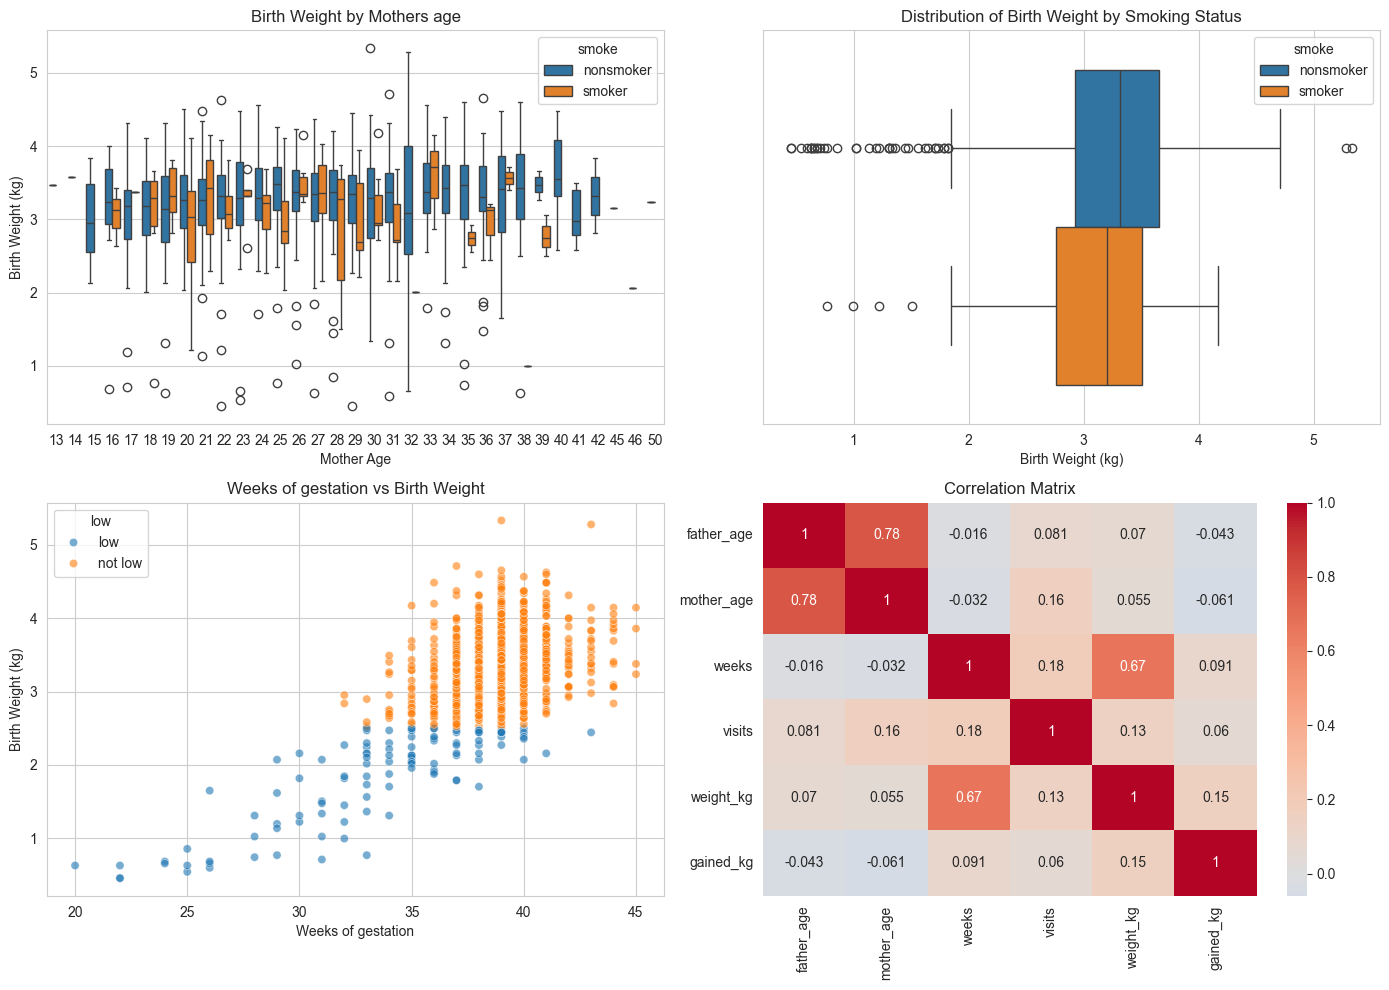

In [4]:
# Create a 2×2 grid of subplots to explore relationships in the data visually.
# Exploratory plots help us form hypotheses before building models.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Plot 1: Birth weight by mother's age, split by smoking status ─────────────
# Boxplot shows median, quartiles, and outliers for each age group.
# Look for: do smoking mothers at any age tend to have lighter babies?
sns.boxplot(
    data=ncbirths, 
    x='mother_age', 
    y='weight_kg', 
    hue='smoke',
    ax=axes[0, 0]
)
axes[0, 0].set_title('Birth Weight by Mothers age')
axes[0, 0].set_xlabel('Mother Age')
axes[0, 0].set_ylabel('Birth Weight (kg)')

# ── Plot 2: Birth weight distribution by smoking status ───────────────────────
# A horizontal boxplot comparing the overall distribution for smokers vs. non-smokers.
# Look for: is the median birth weight lower for smokers?
sns.boxplot(
    data=ncbirths, 
    x='weight_kg', 
    hue='smoke', 
    ax=axes[0, 1]
)
axes[0, 1].set_title('Distribution of Birth Weight by Smoking Status')
axes[0, 1].set_xlabel('Birth Weight (kg)')

# ── Plot 3: Weeks of gestation vs birth weight, coloured by 'low' status ──────
# Scatterplot reveals the strong positive relationship: longer gestation → heavier baby.
# Look for: is 'weeks' a strong predictor of low birthweight? (Spoiler: yes.)
sns.scatterplot(
    data=ncbirths, 
    x='weeks', 
    y='weight_kg', 
    hue='low',
    alpha=0.6,
    ax=axes[1, 0]
)
axes[1, 0].set_title('Weeks of gestation vs Birth Weight')
axes[1, 0].set_xlabel('Weeks of gestation')
axes[1, 0].set_ylabel('Birth Weight (kg)')

# ── Plot 4: Correlation heatmap for numeric variables ────────────────────────
# Values range from -1 (perfect negative) to +1 (perfect positive).
# 'coolwarm' palette: red = positive correlation, blue = negative.
# center=0 ensures white = zero correlation.
# Look for: which features correlate most with weight_kg (our leaky variable)?
numeric_cols = ncbirths.select_dtypes(include=[np.number]).columns
correlation_matrix = ncbirths[numeric_cols].corr()
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap='coolwarm', 
    center=0,
    ax=axes[1, 1]
)
axes[1, 1].set_title('Correlation Matrix')

plt.tight_layout()
plt.show()


# Data Splitting and Resampling

## Data Budget

For machine learning, we typically split data (e.g., 80%-20%) into training and test sets:

- **Training set** is used to estimate model parameters
- **Test set** is used to get an independent assessment of model efficacy

**Important**: Do not use test data during training!

### Why 80% / 20%?

80/20 is a practical convention: enough data to train a model, yet a large enough test set to produce stable evaluation estimates. The exact ratio matters less than the principle — **never evaluate a model on the same data it was trained on**.

> 🎓 **Analogy:** The test set is the exam; the training set is the study material. If you memorised the exam questions during revision you'd ace it — but you wouldn't have learned anything. Same problem in ML: it's called **overfitting**.

### Why `stratify=y`?

Only ~9% of births in this dataset are low birthweight. Without stratification, a random split might put 3% of positives in one fold and 15% in another — making scores unreliable. `stratify=y` forces every split to preserve the same ~9% ratio.

## Create Train-Test Split

In [5]:
# =============================================================================
#  DATA PREPARATION & CLEANING
# =============================================================================

# Fix the random seed so the train/test split is identical every time this code runs.
# Without this, results would change each run, making comparisons meaningless.
np.random.seed(123)

# Remove any row that contains at least one missing value.
# Most sklearn algorithms cannot handle NaN natively.
# Trade-off: we lose ~171 rows (father_age is the main culprit) but keep the code simple.
# In production you would impute (fill in) missing values rather than discard rows.
ncbirths_clean = ncbirths.dropna()

# Map the target column to binary integers:
#   'low'     → 1  (the positive class — the event we are trying to detect)
#   'not low' → 0  (the negative class — normal birth weight)
# This mapping is required because sklearn metrics like F1 and Precision
# expect integer class labels, not strings.
y = ncbirths_clean['low'].map({'low': 1, 'not low': 0})

# =============================================================================
# DATA LEAKAGE: WHY WE REMOVE THESE COLUMNS
# =============================================================================
# Data leakage means using information in training that would not be available
# at prediction time — it creates artificially inflated scores that collapse in production.
#
# ┌──────────────┬───────────────────────────────────────────────────────────┐
# │ Column       │ Why it must be excluded                                   │
# ├──────────────┼───────────────────────────────────────────────────────────┤
# │ low          │ This IS the target — obviously excluded.                  │
# │ weight_kg    │ DIRECT leakage: birth weight literally defines 'low'.     │
# │              │ Including it would give ~100% accuracy but zero real use. │
# │ preterm      │ DERIVED leakage: preterm = (weeks < 36).                  │
# │              │ It carries identical information to 'weeks' already in X. │
# │ mature       │ DERIVED leakage: mature mom = (mother_age >= 35).         │
# │              │ It is a deterministic function of 'mother_age' in X.      │
# └──────────────┴───────────────────────────────────────────────────────────┘
cols_to_exclude = [
    'low',        # target
    'weight_kg',  # direct proxy for target
    'preterm',    # leakage: derived from weeks of gestation
    'mature',     # leakage: derived from mage (maternal age)
]

# Build the feature matrix X by dropping all excluded columns.
# What remains are the genuine predictors the model is allowed to learn from.
X = ncbirths_clean.drop(columns=cols_to_exclude)


# =============================================================================
# STRATIFIED TRAIN-TEST SPLIT
# =============================================================================

# Split into 80% training (model learning) and 20% test (honest evaluation).
# The test set is sealed away — never used during training or hyperparameter tuning.
X_train, X_test, y_train, y_test = train_test_split(
    X,                                     # Feature set
    y,                                     # Target labels
    test_size=0.20,                        # Reserve 20% of the data for testing
    random_state=123,                      # Seed for reproducible shuffling
    stratify=y                             # Preserve ~9% low-birthweight ratio in both splits
)

# =============================================================================
# SUMMARY AND VERIFICATION
# =============================================================================

# Display total counts using f-string formatting with commas for readability
print(f"Observations in Training Set : {len(X_train):,}")
print(f"Observations in Test Set     : {len(X_test):,}")

# Print a header for the class balance check
print("\nClass Distribution (Target = 'low'):")

# Calculate percentage distribution in the training set.
# Both splits should show ~9% low birthweight thanks to stratify=y above.
distribution = y_train.value_counts(normalize=True).mul(100)
for category, percentage in distribution.items():
    print(f"  - {category}: {percentage:.2f}%")


Observations in Training Set : 640
Observations in Test Set     : 160

Class Distribution (Target = 'low'):
  - 0: 90.78%
  - 1: 9.22%


# Logistic Regression for Beginners

## What problem does it solve?

We want to predict a **yes/no outcome** — in our case: *is this baby's birth weight low?*

Despite its name, **Logistic Regression is a classification algorithm**, not a regression one. The name comes from the mathematical function it uses internally — the *logistic (sigmoid) function*.

## How does it work?

1. It starts with a linear equation (just like ordinary regression): `z = β₀ + β₁·weeks + β₂·smoke + ...`
2. It feeds `z` through the **sigmoid function** to squash it to a probability between 0 and 1:

$$P(\text{low}) = \frac{1}{1 + e^{-z}}$$

This produces the characteristic **S-curve** — seen in the plots below.

## Reading the coefficients

- A **positive** coefficient means: higher feature value → higher predicted probability of low birthweight.
- A **negative** coefficient means: higher feature value → lower predicted probability.
- The magnitude (size) of the coefficient reflects how strongly a feature influences the prediction.

## The decision threshold

Once we have a probability (e.g., 0.73), we need a **threshold** to convert it to a class label:
- Default: `P ≥ 0.5 → predict 'low'`
- In clinical settings we often **lower the threshold** (e.g., 0.3) to catch more true cases at the cost of more false alarms — explored interactively below.

## When does it work well?

✅ Linearly separable classes, interpretable coefficients, fast training  
❌ Struggles with complex non-linear boundaries (where tree-based methods excel)


In [8]:
# =============================================================================
# SHARED COLOUR PALETTE — used consistently across ALL plots in this notebook
# =============================================================================
# Defining colours once here avoids inconsistency between plots and makes it
# easy to update the entire notebook's colour scheme in one place.
# Run this cell once; all subsequent cells reference these constants.

CLR_TP = '#2ecc71'   # True Positive  → green  (correct: model caught a low-BW baby)
CLR_TN = '#3498db'   # True Negative  → blue   (correct: model cleared a healthy baby)
CLR_FP = '#e74c3c'   # False Positive → red    (wrong:  model raised false alarm)
CLR_FN = '#f39c12'   # False Negative → orange (wrong:  model missed a low-BW baby — most dangerous)
CLR_CURVE  = '#8e44ad'  # ROC / S-curve line → purple
CLR_DARK   = '#2c3e50'  # S-curve model line / perfect classifier → dark navy

# Dictionaries for easy lookup by outcome label string ('TP', 'TN', 'FP', 'FN')
OUTCOME_COLOURS = {'TP': CLR_TP, 'TN': CLR_TN, 'FP': CLR_FP, 'FN': CLR_FN}
OUTCOME_MARKERS = {'TP': 'o',    'TN': 'o',    'FP': 'X',    'FN': 'X'}  # X marks wrong predictions


def get_outcomes(y_true, y_pred):
    """Return per-observation outcome labels: TP / TN / FP / FN."""
    import numpy as np
    result = []
    for yt, yp in zip(y_true, y_pred):
        if   yp == 1 and yt == 1: result.append('TP')
        elif yp == 0 and yt == 0: result.append('TN')
        elif yp == 1 and yt == 0: result.append('FP')
        else:                     result.append('FN')
    return np.array(result)

def plot_confusion_matrix(ax, y_true, y_pred, title, y_proba=None):
    from sklearn.metrics import confusion_matrix, roc_auc_score


    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP_v = cm.ravel()

    # Rows = Actual, Cols = Predicted
    # Top-left=TP, Top-right=FN, Bottom-left=FP, Bottom-right=TN
    cell_colours = [[CLR_TP, CLR_FN], [CLR_FP, CLR_TN]]
    cell_labels  = [[f'TP\n{TP_v}', f'FN\n{FN}'], [f'FP\n{FP}', f'TN\n{TN}']]

    ax.set_xlim(0, 2); ax.set_ylim(0, 2)
    for r in range(2):
        for c in range(2):
            ax.add_patch(plt.Rectangle((c, 1-r), 1, 1,
                         color=cell_colours[r][c], alpha=0.78, zorder=1))
            ax.text(c+0.5, 1-r+0.5, cell_labels[r][c],
                    ha='center', va='center', fontsize=15,
                    fontweight='bold', color='white', zorder=2)

    ax.set_xticks([0.5, 1.5])
    ax.set_xticklabels(['Predicted: Not Low (0)', 'Predicted: Low (1)'], fontsize=9)
    ax.set_yticks([0.5, 1.5])
    ax.set_yticklabels(['Actual: Low (1)', 'Actual: Not Low (0)'], fontsize=9)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=8)

    precision = TP_v / (TP_v + FP) if (TP_v + FP) > 0 else 0
    recall    = TP_v / (TP_v + FN) if (TP_v + FN) > 0 else 0
    accuracy  = (TP_v + TN) / len(y_true)

    if y_proba is not None:
        auc = roc_auc_score(y_true, y_proba)
        xlabel = (f'Accuracy={accuracy:.2f}  Precision={precision:.2f}  '
                  f'Recall={recall:.2f}  AUC={auc:.3f}')
    else:
        xlabel = (f'Accuracy={accuracy:.2f}  Precision={precision:.2f}  '
                  f'Recall={recall:.2f}')

    ax.set_xlabel(xlabel, fontsize=9, labelpad=8)

def plot_weight_vs_weeks(ax, X_test, y_test, y_pred, weight_g, title, rng_seed=42):
    """Scatter of birth weight vs weeks, coloured by TP/TN/FP/FN."""
    import numpy as np
    import matplotlib.patches as mpatches
    rng = np.random.default_rng(rng_seed)
    jx  = rng.uniform(-0.15, 0.15, len(X_test))
    jy  = rng.uniform(-30,   30,   len(X_test))
    outcomes = get_outcomes(y_test, y_pred)
    weeks    = X_test['weeks'].values

    for cat in ['TN', 'TP', 'FP', 'FN']:   # errors plotted on top
        mask = outcomes == cat
        ax.scatter(weeks[mask] + jx[mask],
                   weight_g[mask] + jy[mask],
                   c=OUTCOME_COLOURS[cat],
                   marker=OUTCOME_MARKERS[cat],
                   s=55 if cat in ('TN','TP') else 90,
                   alpha=0.60 if cat in ('TN','TP') else 0.95,
                   zorder=3 if cat in ('TN','TP') else 5,
                   edgecolors='none')

    ax.axhline(2500, color='#e67e22', lw=2, linestyle='-', zorder=4)
    ax.text(ax.get_xlim()[0] if ax.get_xlim()[0] > 0 else 20,
            2560, '2500g threshold', color='#e67e22', fontsize=8)

    legend_patches = [
        mpatches.Patch(color=CLR_TP, label=f'TP — correctly caught low BW'),
        mpatches.Patch(color=CLR_TN, label=f'TN — correctly cleared'),
        mpatches.Patch(color=CLR_FP, label=f'FP — false alarm'),
        mpatches.Patch(color=CLR_FN, label=f'FN — missed case'),
    ]
    ax.legend(handles=legend_patches, loc='upper left', fontsize=8, framealpha=0.9)
    ax.set_xlabel('Weeks of Gestation', fontsize=11)
    ax.set_ylabel('Birth Weight (g)', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')

print("✅ Shared colour palette and helper functions ready.")




✅ Shared colour palette and helper functions ready.


Coefficient (weeks): -0.7047
Intercept:           24.0030

Interpretation:
  Each additional week of gestation changes log-odds by -0.7047.


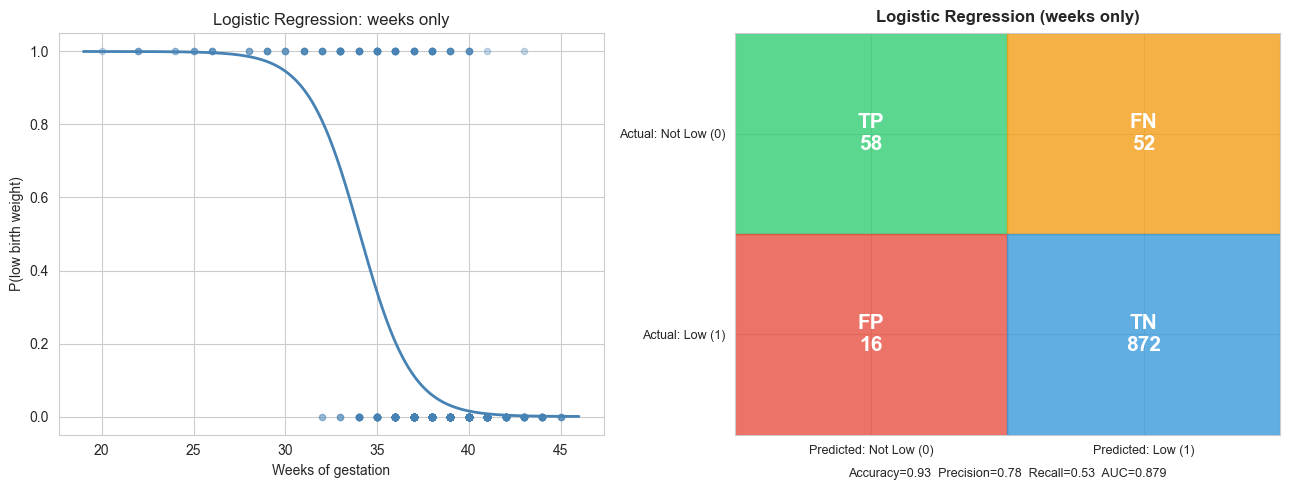

In [9]:


# =============================================================================
# LOGISTIC REGRESSION: SIMPLE MODEL ON ONE FEATURE (weeks only)
# Note: fitted on the FULL dataset for visualisation purposes only.
# We are not evaluating this model — just illustrating the S-curve shape.
# Proper evaluation (on a held-out test set) comes later.
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# ── 1. Prepare a clean 1-feature dataset ─────────────────────────────────────
# Keep only 'weeks' and 'low', drop any rows where either is missing.
df_lr1 = ncbirths[['weeks', 'low']].dropna().copy()
# Convert the string label ('low'/'not low') to a binary integer (1/0)
df_lr1['low_binary'] = (df_lr1['low'].astype(str) == 'low').astype(int)

X_lr1 = df_lr1[['weeks']].values   # 2D array required by sklearn: shape (n_samples, 1)
y_lr1 = df_lr1['low_binary'].values # 1D array of 0/1 labels

# ── 2. Fit the model ──────────────────────────────────────────────────────────
# .fit() runs the optimisation algorithm that finds the best β₀ and β₁
lr_weeks = LogisticRegression()
lr_weeks.fit(X_lr1, y_lr1)

# ── 3. Generate smooth S-curve for plotting ───────────────────────────────────
# We create 400 evenly-spaced x-values across the range of 'weeks' to get a
# smooth curve — otherwise we'd only get predictions at the real data points.
x_range    = np.linspace(X_lr1.min() - 1, X_lr1.max() + 1, 400).reshape(-1, 1)
# .predict_proba() returns [P(class=0), P(class=1)]; [:, 1] selects P(low birthweight)
prob_curve = lr_weeks.predict_proba(x_range)[:, 1]

# ── 4. Per-observation predicted probabilities (for scatter plot dots) ─────────
probs_obs = lr_weeks.predict_proba(X_lr1)[:, 1]

# ── 5. Print and interpret the learned coefficients ───────────────────────────
# .coef_[0][0] = the β₁ coefficient for 'weeks'
# A negative coefficient means more weeks → lower probability of low birthweight (makes sense!)
coef_weeks = lr_weeks.coef_[0][0]
print(f"Coefficient (weeks): {coef_weeks:.4f}")
print(f"Intercept:           {lr_weeks.intercept_[0]:.4f}")
print(f"\nInterpretation:")
print(f"  Each additional week of gestation changes log-odds by {coef_weeks:.4f}.")

# ── 6. Plot the S-curve alongside the confusion matrix ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: the S-curve — shows probability rising as weeks decrease (premature = higher risk)
axes[0].plot(x_range, prob_curve, color='steelblue', lw=2)
axes[0].scatter(df_lr1['weeks'], df_lr1['low_binary'], color='steelblue', alpha=0.3, s=20, zorder=3)
axes[0].set_xlabel('Weeks of gestation')
axes[0].set_ylabel('P(low birth weight)')
axes[0].set_title('Logistic Regression: weeks only')

# Right: confusion matrix showing how many predictions are correct at the default 0.5 threshold
y_pred  = lr_weeks.predict(X_lr1)
y_proba = lr_weeks.predict_proba(X_lr1)[:, 1]
plot_confusion_matrix(axes[1], y_lr1, y_pred,
                      title='Logistic Regression (weeks only)',
                      y_proba=y_proba)

plt.tight_layout()
plt.show()



In [10]:
# =============================================================================
# INTERACTIVE S-CURVE: ADJUST THE DECISION THRESHOLD
# =============================================================================
# Uses ipywidgets (already in Jupyter) — no extra backend needed.
# Points are coloured by classification outcome:
#   🟢 True Positive   (correctly flagged as low birthweight)
#   🔵 True Negative   (correctly flagged as not low)
#   🔴 False Positive  (flagged as low — but baby was healthy)
#   🟠 False Negative  (missed — baby was low but model said healthy)

%matplotlib inline
import ipywidgets as widgets
from IPython.display import display

# Use shared palette (defined in the Colour Palette cell below)
COLORS = OUTCOME_COLOURS
LABELS = {
    'TP': 'True Positive (correctly caught low BW)',
    'TN': 'True Negative (correctly cleared)',
    'FP': 'False Positive (false alarm)',
    'FN': 'False Negative (missed case)',
}

def classify(probs, labels, threshold):
    preds = (probs >= threshold).astype(int)
    cats  = []
    for p, l in zip(preds, labels):
        if   p == 1 and l == 1: cats.append('TP')
        elif p == 0 and l == 0: cats.append('TN')
        elif p == 1 and l == 0: cats.append('FP')
        else:                   cats.append('FN')
    return cats

rng      = np.random.default_rng(42)
jitter_y = rng.uniform(-0.015, 0.015, len(probs_obs))
jitter_x = rng.uniform(-0.3,   0.3,   len(probs_obs))

def plot_scurve(threshold=0.5):
    cats = classify(probs_obs, y_lr1, threshold)
    
    fig, ax = plt.subplots(figsize=(11, 6))

    # S-curve
    ax.plot(x_range, prob_curve, color='#2c3e50', lw=2.5, zorder=2,
            label='P(low | weeks)')

    # Threshold line
    ax.axhline(threshold, color='#8e44ad', lw=2, linestyle='--',
               label=f'Threshold = {threshold:.2f}')

    # Scatter — 4 colours
    for cat in ['TP', 'TN', 'FP', 'FN']:
        idx = [i for i, c in enumerate(cats) if c == cat]
        if idx:
            ax.scatter(
                X_lr1[idx].flatten() + jitter_x[idx],
                probs_obs[idx] + jitter_y[idx],
                c=COLORS[cat], s=45, alpha=0.80, zorder=4,
                label=f'{cat} — {LABELS[cat]}  (n={len(idx)})'
            )

    # Stats box
    c         = {k: cats.count(k) for k in ['TP','TN','FP','FN']}
    precision = c['TP'] / (c['TP'] + c['FP']) if (c['TP'] + c['FP']) > 0 else 0
    recall    = c['TP'] / (c['TP'] + c['FN']) if (c['TP'] + c['FN']) > 0 else 0
    stats = (f"TP={c['TP']}  TN={c['TN']}  FP={c['FP']}  FN={c['FN']}\n"
             f"Precision = {precision:.2f}   Recall = {recall:.2f}")
    ax.text(0.02, 0.92, stats, transform=ax.transAxes, fontsize=10,
            va='top', fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#ecf0f1', alpha=0.9))

    ax.set_xlabel('Weeks of Gestation', fontsize=13)
    ax.set_ylabel('Predicted Probability of Low Birth Weight', fontsize=13)
    ax.set_title('Logistic Regression — S-Curve with Adjustable Decision Threshold',
                 fontsize=14)
    ax.set_ylim(-0.06, 1.06)
    ax.set_xlim(float(x_range.min()), float(x_range.max()))
    ax.legend(loc='upper right', framealpha=0.92, fontsize=9.5, bbox_to_anchor=(1.0, 0.92))
    plt.tight_layout()
    plt.show()

slider = widgets.FloatSlider(
    value=0.5, min=0.01, max=0.99, step=0.01,
    description='Threshold:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='60%')
)

widgets.interact(plot_scurve, threshold=slider);


interactive(children=(FloatSlider(value=0.5, description='Threshold:', layout=Layout(width='60%'), max=0.99, m…

## Reading the interactive plot

| Colour | Label | Meaning |
|--------|-------|---------|
| 🟢 Green  | **True Positive (TP)**  | Model predicted *low* — and it **was** low. Correct! |
| 🔵 Blue   | **True Negative (TN)**  | Model predicted *not low* — and it **was not** low. Correct! |
| 🔴 Red    | **False Positive (FP)** | Model predicted *low* — but baby was healthy. Unnecessary alarm. |
| 🟠 Orange | **False Negative (FN)** | Model predicted *not low* — but baby was actually low weight. **Missed case.** |

### What happens when you move the slider?

- **Raise the threshold** → model becomes more conservative: fewer FP, but more FN (miss real cases).
- **Lower the threshold** → model catches more true cases: fewer FN, but more FP (false alarms).

In a clinical setting, missing a low-birthweight baby (FN) is usually more costly than a false alarm (FP), so practitioners often **lower the threshold** below 0.5.

---


## ROC Curve — Interactive Threshold

The **Receiver Operating Characteristic (ROC) curve** plots the trade-off between:

- **True Positive Rate (Recall / Sensitivity)** = TP / (TP + FN) — how many actual positives we catch
- **False Positive Rate** = FP / (FP + TN) — how many healthy cases we wrongly flag

Three reference lines help you read it:

| Line | Meaning |
|------|---------|
| ⬛ Bold L-shaped line | **Perfect classifier** — hugs the top-left corner (FPR=0, TPR=1) |
| ‐ ‐ Grey diagonal | **Random classifier** (flipping a coin) — AUC = 0.50 |
| 🟣 Dot on curve | **Current threshold** — drag the slider to move it |

The **AUC (Area Under Curve)** summarises overall performance: 1.0 is perfect, 0.5 is random.


In [12]:
# =============================================================================
# INTERACTIVE ROC CURVE WITH ADJUSTABLE THRESHOLD
# =============================================================================

from sklearn.metrics import roc_curve, auc

# Compute the full ROC curve from our simple logistic regression
fpr_arr, tpr_arr, thresholds_arr = roc_curve(y_lr1, probs_obs, pos_label=1)
roc_auc = auc(fpr_arr, tpr_arr)

def plot_roc(threshold=0.5):
    # Find the point on the ROC curve closest to this threshold
    diffs = np.abs(thresholds_arr - threshold)
    idx   = np.argmin(diffs)
    pt_fpr, pt_tpr = fpr_arr[idx], tpr_arr[idx]

    # Recompute counts at this threshold for the annotation
    cats      = classify(probs_obs, y_lr1, threshold)
    c         = {k: cats.count(k) for k in ['TP','TN','FP','FP','FN']}
    c         = {k: cats.count(k) for k in ['TP','TN','FP','FN']}
    precision = c['TP'] / (c['TP'] + c['FP']) if (c['TP'] + c['FP']) > 0 else 0
    recall    = c['TP'] / (c['TP'] + c['FN']) if (c['TP'] + c['FN']) > 0 else 0

    fig, ax = plt.subplots(figsize=(8, 7))

    # ── Random classifier (coin flip) ─────────────────────────────────────
    ax.plot([0, 1], [0, 1], linestyle='--', color='#95a5a6', lw=1.8,
            label='Random classifier  (AUC = 0.50)', zorder=1)

    # ── Perfect classifier ────────────────────────────────────────────────
    ax.plot([0, 0, 1], [0, 1, 1], linestyle='-', color='#2c3e50', lw=3,
            label='Perfect classifier  (AUC = 1.00)', zorder=2)

    # ── Actual ROC curve ──────────────────────────────────────────────────
    ax.plot(fpr_arr, tpr_arr, color='#8e44ad', lw=2.5,
            label=f'Logistic Regression  (AUC = {roc_auc:.3f})', zorder=3)

    # Fill area under actual curve
    ax.fill_between(fpr_arr, tpr_arr, alpha=0.08, color='#8e44ad', zorder=0)

    # ── Current threshold marker ──────────────────────────────────────────
    ax.scatter([pt_fpr], [pt_tpr], s=160, color='#e74c3c', zorder=5,
               label=f'Threshold = {threshold:.2f}  (FPR={pt_fpr:.2f}, TPR={pt_tpr:.2f})')

    # Dotted drop-lines to axes
    ax.plot([pt_fpr, pt_fpr], [0, pt_tpr], ':', color='#e74c3c', lw=1.2, zorder=4)
    ax.plot([0, pt_fpr],      [pt_tpr, pt_tpr], ':', color='#e74c3c', lw=1.2, zorder=4)

    # ── Stats box ─────────────────────────────────────────────────────────
    stats = (f"TP={c['TP']}  TN={c['TN']}  FP={c['FP']}  FN={c['FN']}\n"
             f"Precision = {precision:.2f}   Recall = {recall:.2f}")
    ax.text(0.58, 0.22, stats, transform=ax.transAxes, fontsize=10,
            va='top', fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#ecf0f1', alpha=0.9))

    ax.set_xlabel('False Positive Rate  (1 − Specificity)', fontsize=13)
    ax.set_ylabel('True Positive Rate  (Sensitivity / Recall)', fontsize=13)
    ax.set_title('ROC Curve — Logistic Regression\n(drag slider to move the threshold)',
                 fontsize=14)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.05)
    ax.legend(loc='lower right', framealpha=0.92, fontsize=10)
    plt.tight_layout()
    plt.show()

roc_slider = widgets.FloatSlider(
    value=0.5, min=0.01, max=0.99, step=0.01,
    description='Threshold:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='60%')
)

widgets.interact(plot_roc, threshold=roc_slider);




interactive(children=(FloatSlider(value=0.5, description='Threshold:', layout=Layout(width='60%'), max=0.99, m…

## Reading the interactive plot

| Colour | Label | Meaning |
|--------|-------|---------|
| 🟢 Green  | **True Positive (TP)**  | Model predicted *low* — and it **was** low. Correct! |
| 🔵 Blue   | **True Negative (TN)**  | Model predicted *not low* — and it **was not** low. Correct! |
| 🔴 Red    | **False Positive (FP)** | Model predicted *low* — but baby was healthy. Unnecessary alarm. |
| 🟠 Orange | **False Negative (FN)** | Model predicted *not low* — but baby was actually low weight. **Missed case.** |

### What happens when you move the slider?

- **Raise the threshold** → model becomes more conservative: fewer FP, but more FN (miss real cases).
- **Lower the threshold** → model catches more true cases: fewer FN, but more FP (false alarms).

In a clinical setting, missing a low-birthweight baby (FN) is usually more costly than a false alarm (FP), so practitioners often **lower the threshold** below 0.5.

---


## Logistic regression with 2 features; weeks and smoke

Coefficient (weeks): -0.7031
Coefficient (smoke): 0.5197
Intercept:           23.8656

Interpretation:
  Each additional week of gestation changes log-odds by -0.7031.
  Being a smoker changes log-odds by 0.5197 (OR = 1.681).


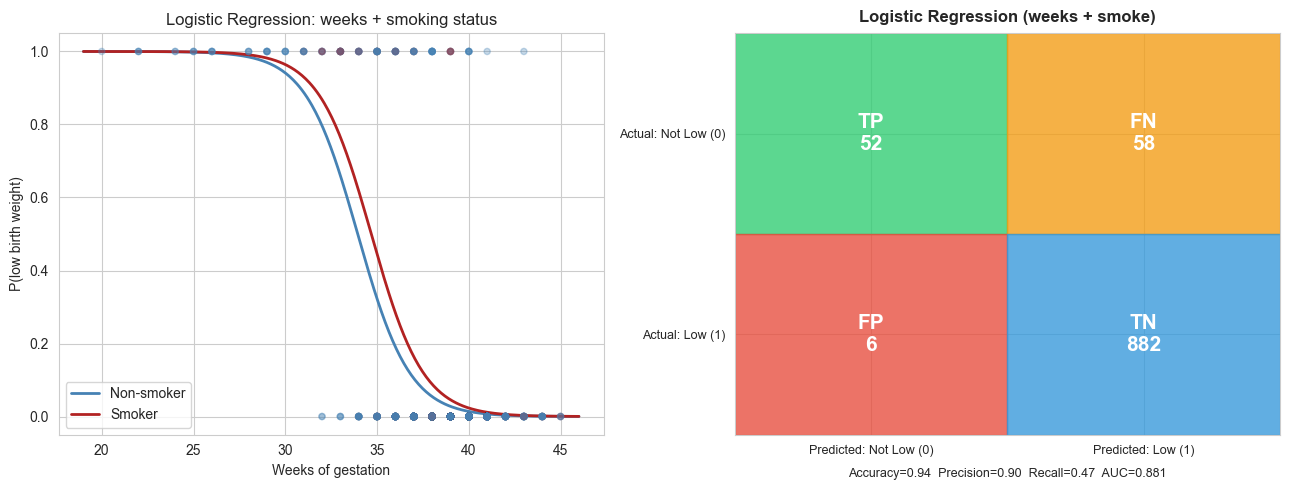

In [13]:
# =============================================================================
# LOGISTIC REGRESSION: FIT A MODEL ON TWO FEATURES (weeks + smoke)
# Note: fitted on the full dataset for visualisation only — not for evaluation.
# Adding 'smoke' lets us see how a second binary feature shifts the S-curve.
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.linear_model import LogisticRegression

# ── 1. Prepare a clean 2-feature dataset ─────────────────────────────────────
df_lr = ncbirths[['weeks', 'smoke', 'low']].dropna().copy()
df_lr['low_binary']   = (df_lr['low'].astype(str) == 'low').astype(int)
# Encode smoking as binary: smoker=1, nonsmoker=0
df_lr['smoke_binary'] = (df_lr['smoke'].astype(str) == 'smoker').astype(int)

X_lr = df_lr[['weeks', 'smoke_binary']].values
y_lr = df_lr['low_binary'].values

# ── 2. Fit the model ──────────────────────────────────────────────────────────
lr_simple = LogisticRegression()
lr_simple.fit(X_lr, y_lr)

# ── 3. Generate two smooth S-curves — one per smoking status ──────────────────
# To isolate the effect of 'weeks', we fix 'smoke' at 0 (non-smoker) then 1 (smoker)
# and vary 'weeks' across its full range. This is called 'holding other variables constant'.
x_range        = np.linspace(X_lr[:, 0].min() - 1, X_lr[:, 0].max() + 1, 400)
X_nonsmoker    = np.column_stack([x_range, np.zeros(400)])  # smoke=0 for all 400 points
X_smoker       = np.column_stack([x_range, np.ones(400)])   # smoke=1 for all 400 points
prob_nonsmoker = lr_simple.predict_proba(X_nonsmoker)[:, 1]
prob_smoker    = lr_simple.predict_proba(X_smoker)[:, 1]

# ── 4. Per-observation predicted probabilities ────────────────────────────────
probs_obs = lr_simple.predict_proba(X_lr)[:, 1]

# ── 5. Print and interpret coefficients ───────────────────────────────────────
coef_weeks, coef_smoke = lr_simple.coef_[0]
print(f"Coefficient (weeks): {coef_weeks:.4f}")
print(f"Coefficient (smoke): {coef_smoke:.4f}")
print(f"Intercept:           {lr_simple.intercept_[0]:.4f}")
print(f"\nInterpretation:")
print(f"  Each additional week of gestation changes log-odds by {coef_weeks:.4f}.")
# np.exp(coef) converts the log-odds coefficient to an odds ratio — easier to interpret
# OR > 1 means increased risk; OR < 1 means decreased risk
print(f"  Being a smoker changes log-odds by {coef_smoke:.4f} (OR = {np.exp(coef_smoke):.3f}).")

# ── 6. Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Two S-curves (one per smoking status) — the vertical gap between them
# is the additive effect of smoking, constant across all gestational ages.
axes[0].plot(x_range, prob_nonsmoker, color='steelblue', lw=2, label='Non-smoker')
axes[0].plot(x_range, prob_smoker,    color='firebrick',  lw=2, label='Smoker')
smoke_col = df_lr['smoke_binary'].map({0: 'steelblue', 1: 'firebrick'})
axes[0].scatter(df_lr['weeks'], df_lr['low_binary'], c=smoke_col, alpha=0.3, s=20, zorder=3)
axes[0].set_xlabel('Weeks of gestation')
axes[0].set_ylabel('P(low birth weight)')
axes[0].set_title('Logistic Regression: weeks + smoking status')
axes[0].legend()

# Right: confusion matrix at the default 0.5 threshold
y_pred  = lr_simple.predict(X_lr)
y_proba = lr_simple.predict_proba(X_lr)[:, 1]
plot_confusion_matrix(axes[1], y_lr, y_pred,
                      title='Logistic Regression (weeks + smoke)',
                      y_proba=y_proba)

plt.tight_layout()
plt.show()


## Links

For a great interactive discussion of logistic regression, precision-recall, and ROC curves, check out:

- [Logistic Regression](https://mlu-explain.github.io/logistic-regression/) 
- [Precision-Recall](https://mlu-explain.github.io/precision-recall)
- [ROC Curve](https://mlu-explain.github.io/roc-auc/)

In [14]:
# =============================================================================
#  AUTOMATED FEATURE IDENTIFICATION
# =============================================================================

# Automatically detect which columns are categorical vs. numeric.
# Using dtype detection rather than hard-coding names makes the code
# robust if columns are added or removed in future.
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_features = X_train.select_dtypes(include=[np.number]).columns.tolist()

print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"Numerical features   ({len(numerical_features)}): {numerical_features}")

# =============================================================================
# DEFINING TRANSFORMER PIPELINES
# =============================================================================

# ── Numeric transformer: Z-score standardisation ─────────────────────────────
# StandardScaler rescales each numeric feature to mean=0 and std=1:
#   scaled_value = (original_value - column_mean) / column_std
#
# WHY? Distance-based models (KNN) and gradient-based models (Logistic Regression)
# are sensitive to feature scale. A feature in thousands (e.g. income) would
# dominate a feature in fractions (e.g. probability) without scaling.
# Tree-based models (Random Forest, XGBoost) do NOT require scaling, but it
# doesn't hurt them, so we scale uniformly for simplicity.
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())           # Apply Z-score normalization
])

# ── Categorical transformer: One-Hot Encoding ────────────────────────────────
# ML algorithms work with numbers, not strings like 'male'/'female'.
# One-Hot Encoding creates a new binary (0/1) column for each category.
#
# Example: gender ('male', 'female') → gender_female: [0, 1, 0, 1]
#          (gender_male is dropped — see drop='first' below)
#
# drop='first': removes one category per feature to avoid the 'dummy variable trap'
#   (if gender_male=0, we already know gender_female=1 — the extra column is redundant
#    and causes multicollinearity in linear models)
#
# sparse_output=False: returns a regular NumPy array instead of a sparse matrix.
#   Sparse matrices save memory when most values are 0, but dense arrays are
#   easier to inspect and compatible with all downstream steps here.
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(
        drop='first',                      # Drop first category to avoid the dummy variable trap
        sparse_output=False                # Return a dense array for compatibility
    ))
])

# =============================================================================
# ORCHESTRATING THE COLUMN TRANSFORMER
# =============================================================================
# ColumnTransformer applies DIFFERENT transformations to DIFFERENT column groups
# simultaneously, then concatenates the results into a single feature matrix.
#
# Flow: raw DataFrame → [scale numerics | encode categoricals] → combined array
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),   # Scale numeric columns
        ('cat', categorical_transformer, categorical_features) # Encode categorical columns
    ]
)

print("\n[SUCCESS] Preprocessing pipeline constructed and ready for data fitting.")


Categorical features (3): ['gender', 'smoke', 'whitemom']
Numerical features   (5): ['father_age', 'mother_age', 'weeks', 'visits', 'gained_kg']

[SUCCESS] Preprocessing pipeline constructed and ready for data fitting.


# Decision Tree and Visualisation for Beginners

## What problem does it solve?

We want to predict a **yes/no outcome** — same task as Logistic Regression, but with a completely different approach.

## How does it work?

A Decision Tree asks a sequence of **yes/no questions** about the input features — exactly like the game *20 Questions*. Each answer leads down a branch until it reaches a **leaf node** that gives a class prediction.

```
          weeks < 36.5?
          /           \
        YES            NO
     gained_kg?      visits?
       /   \           ...
    LOW   NOT LOW
```

### Key vocabulary

| Term | Meaning |
|------|---------|
| **Root node** | The very first split — the single most informative question |
| **Branch** | A path taken after a yes/no decision |
| **Leaf node** | Terminal node with no further splits — gives the final prediction |
| **Depth** | Number of questions asked from root to leaf |

### How does it choose where to split?

At each node, the algorithm tries every possible split on every feature and picks the one that **most reduces impurity** (measured by Gini impurity, explained below). It's essentially asking: *which question separates the low-birthweight babies from the healthy ones most cleanly?*

### Key hyperparameters

- **`max_depth`**: Maximum number of splits from root to leaf. Without this limit, the tree grows until every training example has its own leaf — it memorises the training data perfectly but fails on new data (**overfitting**). We use `max_depth=5` for visualisation.
- **`min_samples_leaf`**: The minimum number of training examples required in a leaf. Acts as a smoothing parameter — prevents the tree from making decisions based on tiny groups of observations.

### Pros and cons

✅ Completely interpretable (you can follow the logic step by step)  
✅ Handles mixed data types (numeric + categorical) natively  
✅ No scaling required  
❌ **High variance**: a small change in the training data can produce a very different tree  
❌ Prone to overfitting without `max_depth` or `min_samples_leaf` constraints  
❌ Usually less accurate than ensemble methods (Random Forest, XGBoost)


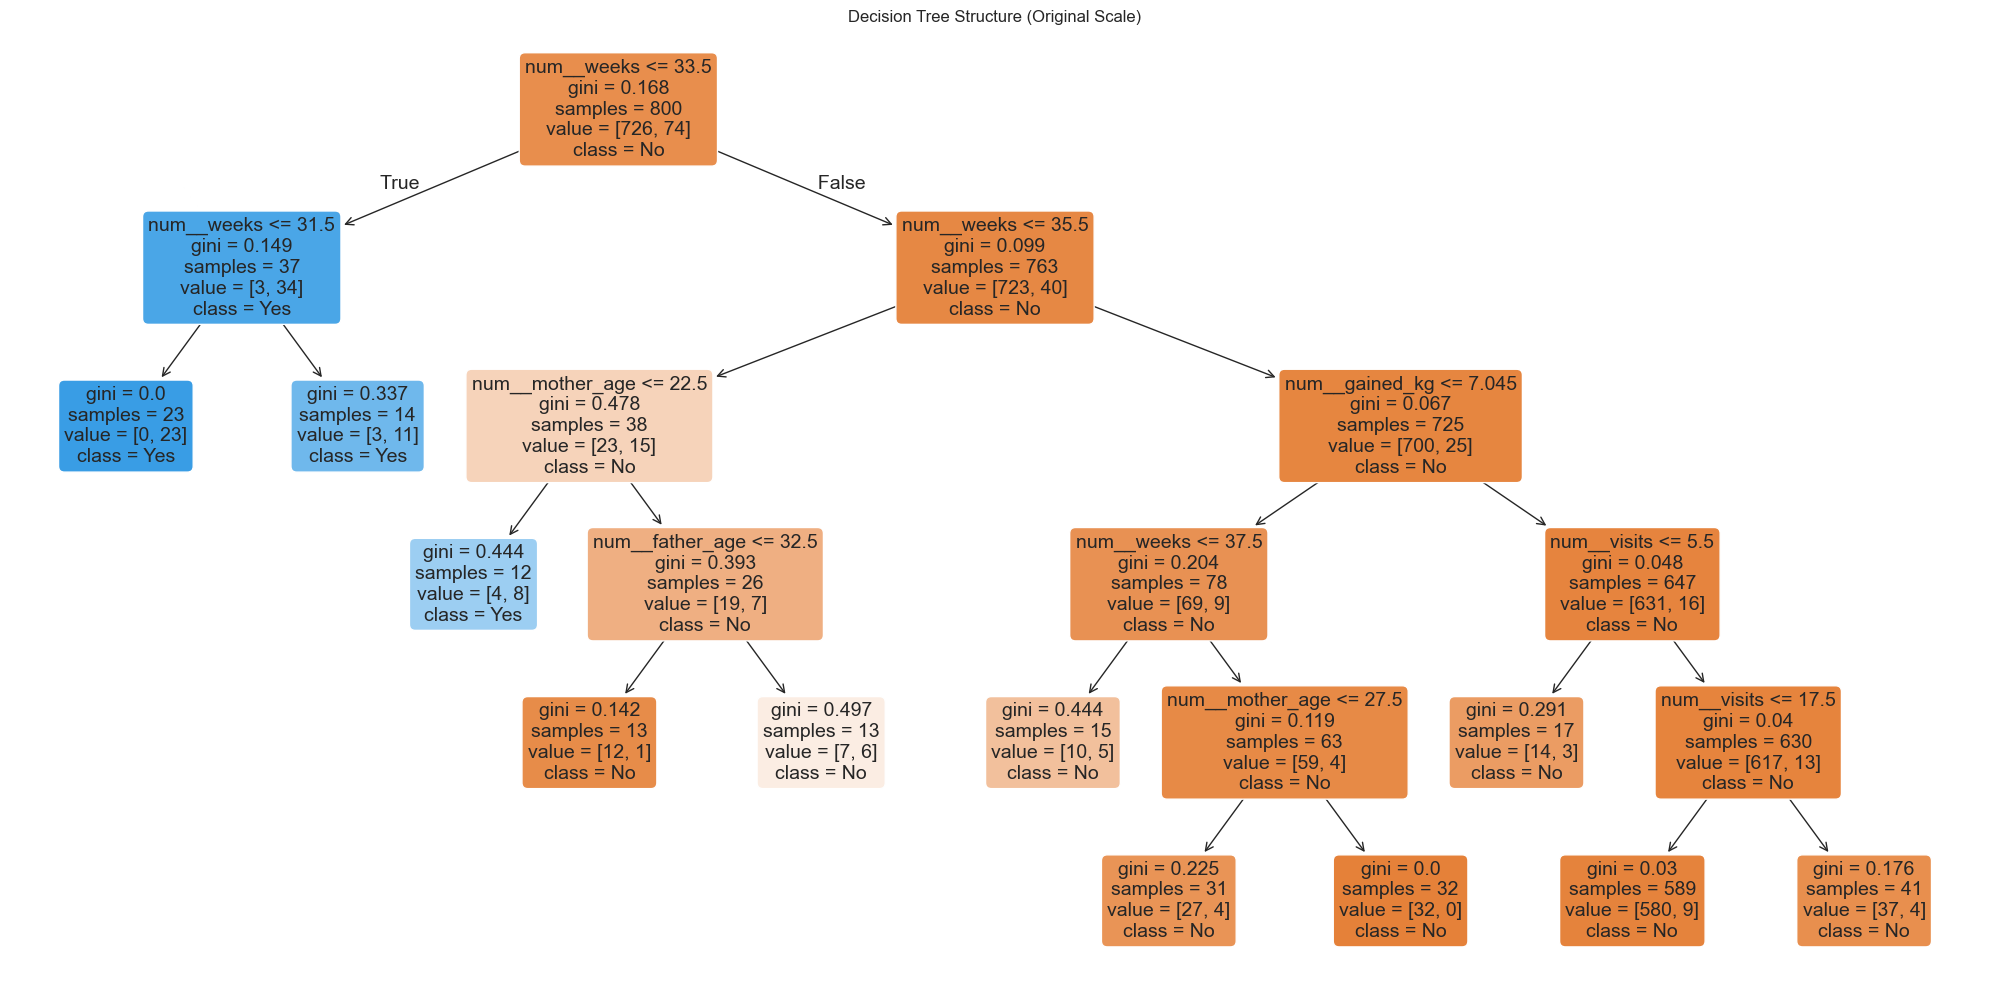

In [15]:
from sklearn.tree import export_text, plot_tree
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

# =============================================================================
# DECISION TREE VISUALISATION (USING ORIGINAL VALUES, NOT STANDARDIZED VALUES)
# =============================================================================
# Why a separate unscaled pipeline for visualisation?
# When StandardScaler is applied, split thresholds become unreadable:
#   e.g. 'weeks < -0.83' (standardised) instead of 'weeks < 36.5' (original).
# For the visual tree we use 'passthrough' so splits show real-world values.
# This pipeline is ONLY for visualisation — not for model evaluation.

# Build a preprocessor that encodes categoricals but does NOT scale numerics
preprocessor_unscaled = ColumnTransformer(transformers=[
    ('num', 'passthrough', numerical_features),    # 'passthrough' = no transformation
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

# Pipeline WITHOUT scaling — just for visualisation
tree_pipeline_unscaled = Pipeline(steps=[
    ('preprocessor', preprocessor_unscaled),
    # max_depth=5: limits the tree to 5 levels so the diagram fits on screen
    # min_samples_leaf=10: each leaf must have at least 10 training examples
    ('classifier', DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=42))
])

# Fit on full dataset (visualisation purposes only — not for evaluation)
tree_pipeline_unscaled.fit(X, y)

# Extract the fitted tree and the feature names the preprocessor created
# (includes auto-generated names like 'cat__gender_male' for one-hot columns)
fitted_tree   = tree_pipeline_unscaled.named_steps['classifier']
feature_names = tree_pipeline_unscaled.named_steps['preprocessor'].get_feature_names_out()

# --- Text version (commented out — useful for copying into reports) ---
# print(export_text(fitted_tree, feature_names=list(feature_names)))

# --- Visual version ---
# filled=True   : colours each node by its majority class (makes the tree easier to read)
# rounded=True  : rounds box corners (cosmetic)
# class_names=['No','Yes'] : maps 0→'No' (not low) and 1→'Yes' (low birthweight)
plt.figure(figsize=(20, 10))
plot_tree(fitted_tree, feature_names=list(feature_names),
          class_names=['No', 'Yes'], filled=True, rounded=True,
          fontsize=14, max_depth=5)
plt.title('Decision Tree Structure (Original Scale)')
plt.tight_layout()
plt.show()


## Gini Impurity — what the number means

The Gini impurity measures how mixed the classes are in a node. It answers: "If I randomly picked two samples from this node, what's the probability they belong to different classes?"

$\text{Gini} = 1 - \sum_{k} p_k^2$

where $p_k$ is the proportion of class $k$ in that node.

Two extreme cases:

| Situation | Gini | Meaning |
| :--- | :--- | :--- |
| All samples are the same class | 0.0 | Perfectly pure — no mixing |
| Classes split 50/50 | 0.5 | Maximum uncertainty |


Some examples:

- Root node (top): gini = 0.168 — mostly "No" (726 vs 74), so already fairly pure
- Blue node at bottom left = [0, 23], gini = 0.0 — all 23 samples are "Yes" → perfectly pure leaf, no more splitting needed
- Node value = [23, 15], gini = 0.478 — nearly 50/50 split → very impure, the tree is still uncertain here





## Logistic Regression — Confusion Matrix & Birth Weight Plot


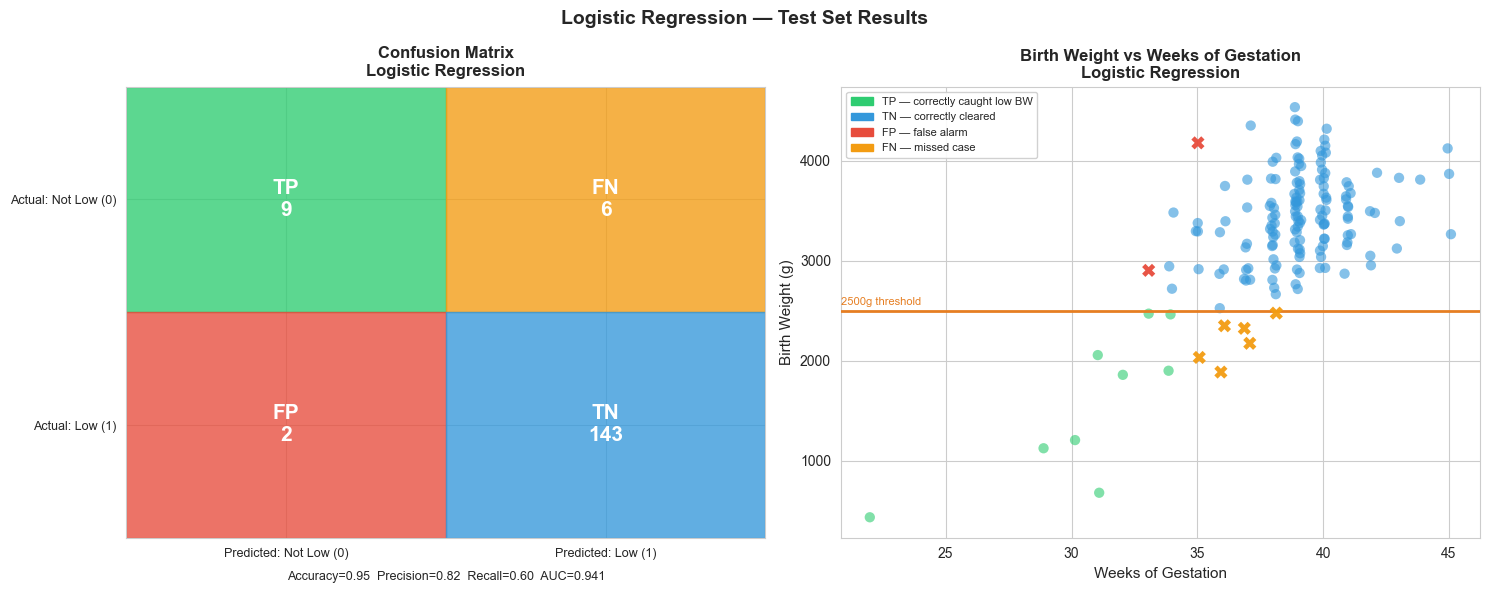

In [16]:
# =============================================================================
# LOGISTIC REGRESSION — Confusion Matrix & Birth Weight vs Weeks
# =============================================================================

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Fit pipeline (preprocessor defined in the Feature Engineering cell above)
pipe_lr = Pipeline([('preprocessor', preprocessor),
                    ('classifier',   LogisticRegression(max_iter=1000, random_state=123))])
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

y_proba_lr = pipe_lr.predict_proba(X_test)[:, 1]   # column 1 = P(low)


# birth weight in grams — used for plotting only (excluded from model training)
weight_g_test = ncbirths_clean.loc[X_test.index, 'weight_kg'].values * 1000

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Logistic Regression — Test Set Results', fontsize=14, fontweight='bold')


plot_confusion_matrix(axes[0], y_test, y_pred_lr, 
                    'Confusion Matrix\nLogistic Regression', y_proba=y_proba_lr)


plot_weight_vs_weeks(axes[1], X_test, y_test.values, y_pred_lr, weight_g_test,
                     'Birth Weight vs Weeks of Gestation\nLogistic Regression')

plt.tight_layout()
plt.show()


---
## Decision Tree — Confusion Matrix & Birth Weight Plot


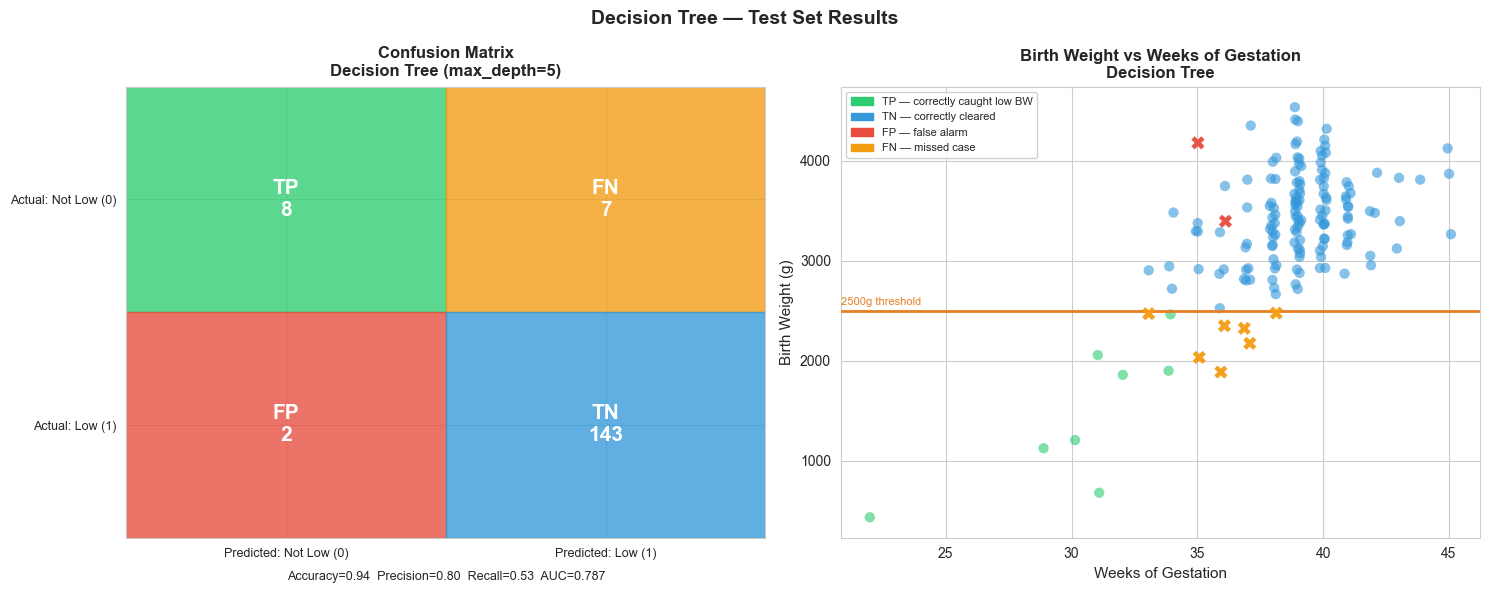

In [17]:
# =============================================================================
# DECISION TREE — Confusion Matrix & Birth Weight vs Weeks
# =============================================================================

from sklearn.tree import DecisionTreeClassifier

pipe_dt = Pipeline([('preprocessor', preprocessor),
                    ('classifier',   DecisionTreeClassifier(max_depth=5, random_state=123))])
pipe_dt.fit(X_train, y_train)
y_pred_dt = pipe_dt.predict(X_test)
y_proba_dt = pipe_dt.predict_proba(X_test)[:, 1]


fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Decision Tree — Test Set Results', fontsize=14, fontweight='bold')

plot_confusion_matrix(axes[0], y_test, y_pred_dt, 
    'Confusion Matrix\nDecision Tree (max_depth=5)',
    y_proba=y_proba_dt)


plot_weight_vs_weeks(axes[1], X_test, y_test.values, y_pred_dt, weight_g_test,
                     'Birth Weight vs Weeks of Gestation\nDecision Tree')

plt.tight_layout()
plt.show()


---
## Side-by-Side Comparison — Logistic Regression vs Decision Tree

The two confusion matrices and scatter plots are shown together so you can compare where each model succeeds and fails.


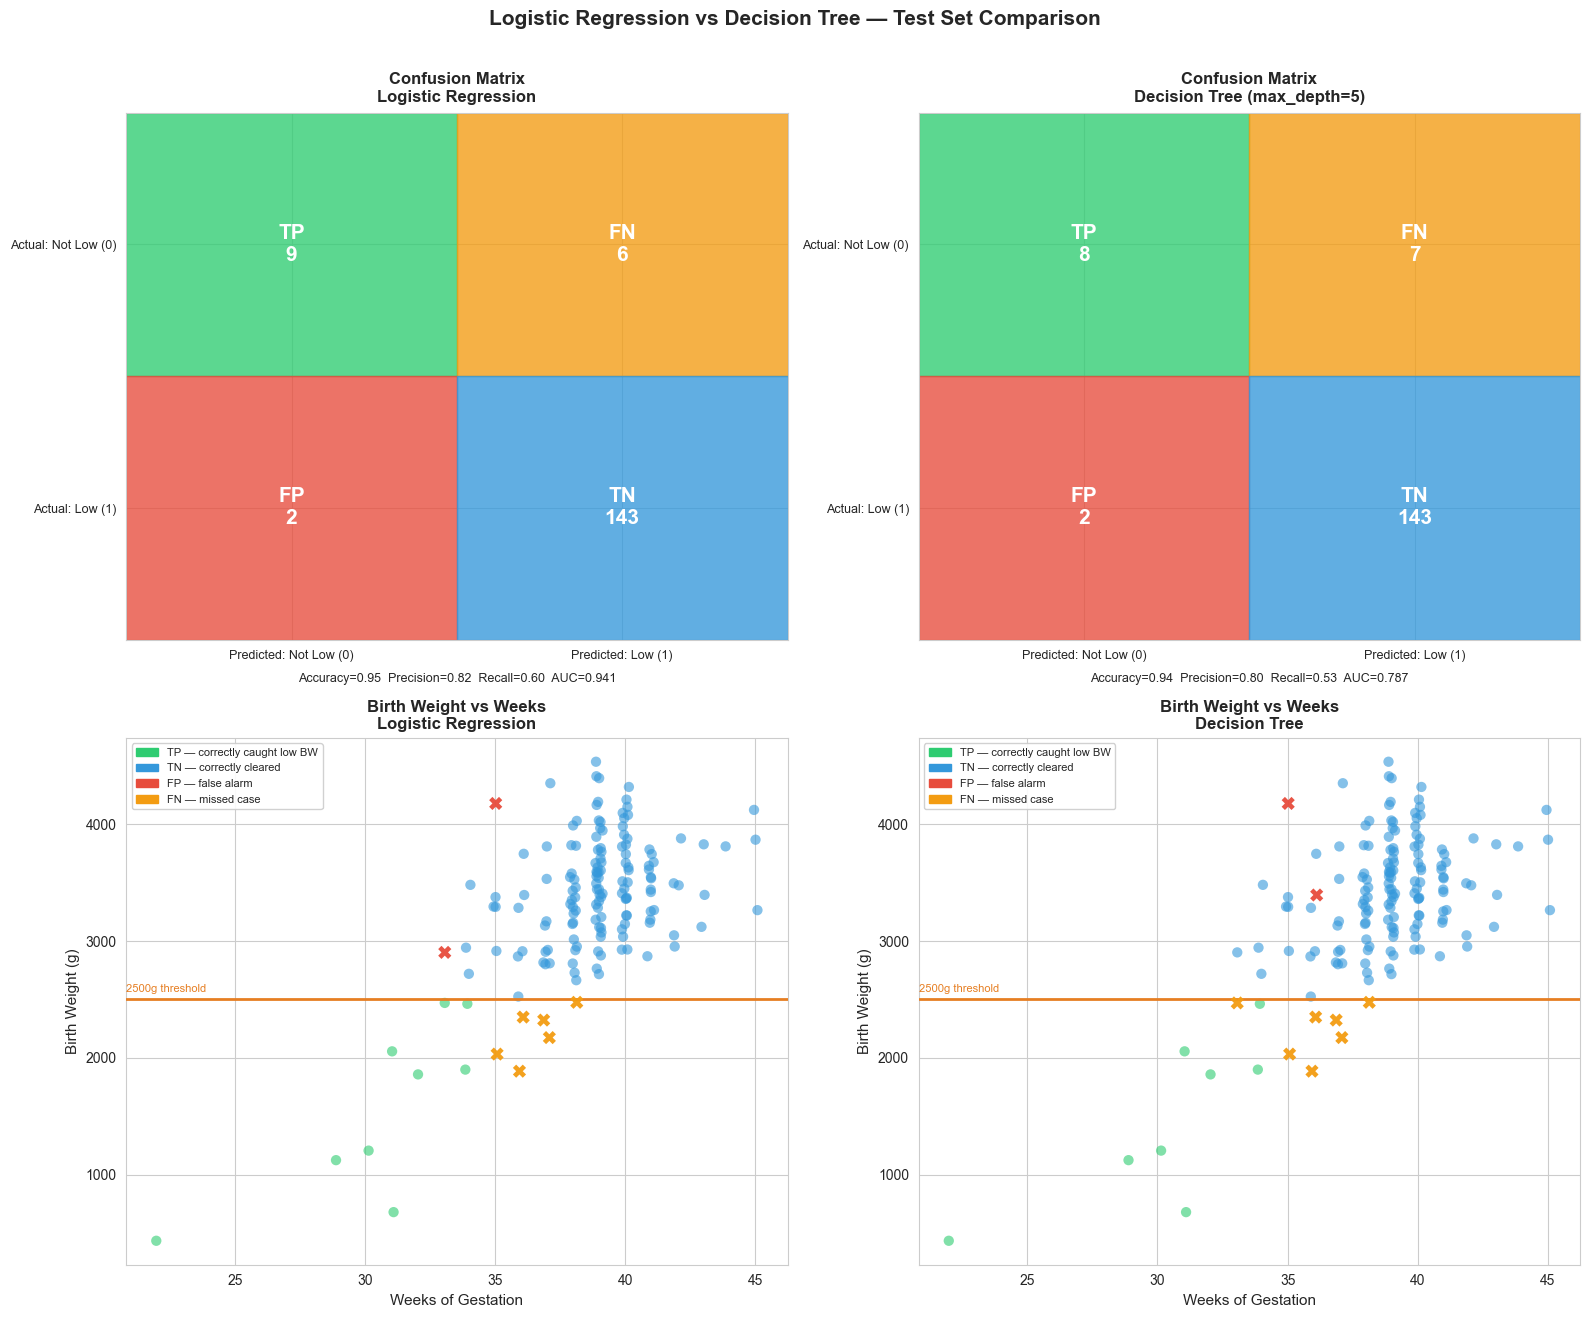

In [18]:
# =============================================================================
# COMPARISON: LR vs DECISION TREE — confusion matrices + scatter plots
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 13))
fig.suptitle('Logistic Regression vs Decision Tree — Test Set Comparison',
             fontsize=15, fontweight='bold', y=1.01)

# Row 0: confusion matrices
plot_confusion_matrix(axes[0,0], y_test, y_pred_lr, 
                    'Confusion Matrix\nLogistic Regression', y_proba=y_proba_lr)
                      
plot_confusion_matrix(axes[0,1], y_test, y_pred_dt, 
    'Confusion Matrix\nDecision Tree (max_depth=5)',
    y_proba=y_proba_dt)

# Row 1: scatter plots
plot_weight_vs_weeks(axes[1, 0], X_test, y_test.values, y_pred_lr, weight_g_test,
                     'Birth Weight vs Weeks\nLogistic Regression')
plot_weight_vs_weeks(axes[1, 1], X_test, y_test.values, y_pred_dt, weight_g_test,
                     'Birth Weight vs Weeks\nDecision Tree')

plt.tight_layout()
plt.show()


# Feature Engineering and Preprocessing

In [19]:
# =============================================================================
#  AUTOMATED FEATURE IDENTIFICATION
# =============================================================================

# Automatically detect which columns are categorical vs. numeric.
# Using dtype detection rather than hard-coding names makes the code
# robust if columns are added or removed in future.
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_features = X_train.select_dtypes(include=[np.number]).columns.tolist()

print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"Numerical features   ({len(numerical_features)}): {numerical_features}")

# =============================================================================
# DEFINING TRANSFORMER PIPELINES
# =============================================================================

# ── Numeric transformer: Z-score standardisation ─────────────────────────────
# StandardScaler rescales each numeric feature to mean=0 and std=1:
#   scaled_value = (original_value - column_mean) / column_std
#
# WHY? Distance-based models (KNN) and gradient-based models (Logistic Regression)
# are sensitive to feature scale. A feature in thousands (e.g. income) would
# dominate a feature in fractions (e.g. probability) without scaling.
# Tree-based models (Random Forest, XGBoost) do NOT require scaling, but it
# doesn't hurt them, so we scale uniformly for simplicity.
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())           # Apply Z-score normalization
])

# ── Categorical transformer: One-Hot Encoding ────────────────────────────────
# ML algorithms work with numbers, not strings like 'male'/'female'.
# One-Hot Encoding creates a new binary (0/1) column for each category.
#
# Example: gender ('male', 'female') → gender_female: [0, 1, 0, 1]
#          (gender_male is dropped — see drop='first' below)
#
# drop='first': removes one category per feature to avoid the 'dummy variable trap'
#   (if gender_male=0, we already know gender_female=1 — the extra column is redundant
#    and causes multicollinearity in linear models)
#
# sparse_output=False: returns a regular NumPy array instead of a sparse matrix.
#   Sparse matrices save memory when most values are 0, but dense arrays are
#   easier to inspect and compatible with all downstream steps here.
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(
        drop='first',                      # Drop first category to avoid the dummy variable trap
        sparse_output=False                # Return a dense array for compatibility
    ))
])

# =============================================================================
# ORCHESTRATING THE COLUMN TRANSFORMER
# =============================================================================
# ColumnTransformer applies DIFFERENT transformations to DIFFERENT column groups
# simultaneously, then concatenates the results into a single feature matrix.
#
# Flow: raw DataFrame → [scale numerics | encode categoricals] → combined array
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),   # Scale numeric columns
        ('cat', categorical_transformer, categorical_features) # Encode categorical columns
    ]
)

print("\n[SUCCESS] Preprocessing pipeline constructed and ready for data fitting.")


Categorical features (3): ['gender', 'smoke', 'whitemom']
Numerical features   (5): ['father_age', 'mother_age', 'weeks', 'visits', 'gained_kg']

[SUCCESS] Preprocessing pipeline constructed and ready for data fitting.


## Random Forest

### How does it work?

A Random Forest is a collection of many decision trees, each trained on a **random subset of the training data** (bootstrap sampling) and using a **random subset of features** at each split. The final prediction is determined by **majority vote** across all trees.

This technique is called **bagging** (Bootstrap AGGregating). The two sources of randomness — different data samples and different feature subsets — ensure the trees are *diverse*, which is what makes the ensemble robust.

> 🗳️ **Analogy:** Imagine asking 100 doctors each to diagnose a patient, but each doctor only sees a random selection of test results. Their individual opinions are noisy, but the *majority vote* is surprisingly reliable — individual errors cancel out.

### Key parameters

- `n_estimators=100`: number of trees in the forest. More trees = more stable predictions, but slower training
- `random_state=123`: fixes the random seed so the same 100 trees are grown every run
- In grid search: `max_depth` (limits individual tree complexity), `min_samples_leaf` (smoothing), `class_weight='balanced'` (upweights the minority class proportional to its rarity — important for our 9% positive rate)

### Why it outperforms a single decision tree

A single decision tree has **high variance** — small changes in training data produce very different trees. Averaging 100 diverse trees **dramatically reduces this variance** while keeping the same low bias.

### Pros and cons

✅ Very robust — hard to overfit badly  
✅ Naturally provides feature importance scores  
✅ Handles mixed data types and missing values well  
❌ Less interpretable than a single decision tree ('black box forest')  
❌ Slower than a single tree (trains 100 trees instead of 1)  


## XGBoost (eXtreme Gradient Boosting)

### How does it work?

XGBoost builds an **ensemble of decision trees sequentially**, where each new tree corrects the mistakes of all previous trees. This is fundamentally different from Random Forest, which builds trees *in parallel* on random subsets.

| Algorithm | Tree training | How errors are handled |
|-----------|--------------|------------------------|
| **Random Forest** | Parallel (independent) | Averaged out by the ensemble |
| **XGBoost** | Sequential | Each tree explicitly corrects the previous |

> 🎓 **Analogy:** Imagine a team of doctors diagnosing a patient. Random Forest = each doctor gives an independent opinion, then you take the majority vote. XGBoost = the first doctor makes a diagnosis, the second specialises in correcting the first doctor's known weaknesses, the third corrects both, and so on.

The 'gradient' in gradient boosting refers to **gradient descent** — each new tree is a small step in the direction that most reduces the prediction error.

### Key parameters

- `n_estimators=100`: number of trees (boosting rounds)
- `eval_metric='logloss'`: the loss function minimised during training (log-loss = cross-entropy, standard for binary classification)
- `use_label_encoder=False`: disables a deprecated internal encoder — we have already encoded our labels
- In grid search: `learning_rate` controls how big each correction step is (smaller = more trees needed but less overfitting), `max_depth` controls tree complexity, `subsample` and `colsample_bytree` add randomness to reduce overfitting

### Pros and cons

✅ State-of-the-art performance on tabular data  
✅ Built-in L1/L2 regularisation to prevent overfitting  
✅ Handles missing values natively  
❌ Many hyperparameters to tune  
❌ Slower than LightGBM on large datasets  


## LightGBM (Light Gradient Boosting Machine)

### How does it work?

LightGBM is Microsoft's optimised implementation of gradient boosting. Like XGBoost, it builds trees **sequentially** — each tree corrects the errors of the previous one. Its key innovation is **leaf-wise tree growth** instead of level-wise:

| Approach | Strategy | Result |
|----------|----------|--------|
| **Level-wise** (XGBoost default) | Grow all nodes at the same depth | Balanced tree |
| **Leaf-wise** (LightGBM) | Always grow the leaf that reduces loss the most | Asymmetric, more efficient |

> 🏗️ **Analogy:** Level-wise is like renovating every room in a house to the same standard at once. Leaf-wise is like a contractor who focuses on whichever room needs the most urgent repair first.

### Key parameters

- `n_estimators=100`: number of boosting iterations (trees)
- `verbose=-1`: suppresses LightGBM's internal training logs
- `importance_type='gain'`: when computing feature importance, use the total *gain* (impurity reduction) each feature contributes across all splits — more informative than counting the number of times a feature is used

### Pros and cons

✅ Faster than XGBoost on large datasets  
✅ Lower memory usage  
✅ Handles categorical features natively (not used here — we encode manually for consistency)  
❌ More hyperparameters to tune  
❌ Leaf-wise growth can overfit on small datasets without careful tuning  


## K-Nearest Neighbours (KNN)

### How does it work?

KNN is the most intuitive algorithm: to classify a new data point, **find the *k* most similar training points and take a majority vote**. No explicit training phase — all the work happens at prediction time.

With `n_neighbors=5`, the model finds the 5 closest training babies (by Euclidean distance in feature space) and assigns the majority class.

### Why scaling is critical for KNN

KNN uses *distance* to measure similarity. If one feature ranges from 0–50 and another from 0–1, the first will dominate the distance calculation. That's why `StandardScaler` in our pipeline is **essential** for KNN — unlike tree-based models which are scale-independent.

### Pros and cons

✅ No assumptions about the data distribution  
✅ Naturally handles multi-class problems  
❌ Slow at prediction time — must compare the new point against *every* training point  
❌ Struggles with many features ('curse of dimensionality')  
❌ Sensitive to irrelevant features and outliers  


---

## Algorithm Landscape: What We're About to Compare

No single algorithm wins on all problems — this is known as the **No Free Lunch theorem**. We benchmark six algorithms from three different families:

| Algorithm | Family | Core idea | Needs scaling? |
|-----------|--------|-----------|---------------|
| Logistic Regression | Linear | Fits a line / hyperplane | ✅ Yes |
| Decision Tree | Tree | Sequence of yes/no questions | ❌ No |
| **Random Forest** | Ensemble (Bagging) | Average of many diverse trees | ❌ No |
| **XGBoost** | Ensemble (Boosting) | Trees that correct each other sequentially | ❌ No |
| **LightGBM** | Ensemble (Boosting) | Faster XGBoost with leaf-wise growth | ❌ No |
| KNN | Instance-based | Majority vote from k nearest neighbours | ✅ Yes |

Each model is wrapped in a **Pipeline** (preprocessing → classifier) so comparisons are fair: every model sees identically preprocessed features, and scaling is always fitted only on the training fold — never on test data.


# Model Building and Evaluation

## Define Models

We'll compare six classification algorithms:

1. **Logistic Regression** — our interpretable linear baseline
2. **Decision Tree** — interpretable, rule-based splits
3. **Random Forest** — bagged ensemble of trees; robust and accurate
4. **XGBoost** — sequential boosting; often wins on tabular data
5. **LightGBM** — faster boosting with leaf-wise growth
6. **K-Nearest Neighbours** — vote from the k nearest training examples

Each algorithm is described in the cells above. Here we define them with starting hyperparameters;
the top performers will be tuned more carefully later with Grid Search.


In [20]:
# =============================================================================
# MODEL REPOSITORY CONFIGURATION
# =============================================================================
# We store all candidate models in a dictionary with consistent string keys.
# This allows us to loop over all models identically in the cross-validation step,
# rather than writing separate code blocks for each algorithm.

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,                         # Increase iterations to ensure convergence on complex data
        random_state=123                       # Ensure reproducible coefficients
    ),
    'Decision Tree': DecisionTreeClassifier(
        random_state=123                       # Fix the split logic for reproducibility
        # No max_depth here — tree grows freely for benchmarking; tuning comes later
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,                      # Use 100 individual trees to form the forest
        random_state=123                       # Ensure the same bootstrapped samples each run
    ),
    # XGBoost: sequential gradient boosting from the dedicated xgboost library
    'XGBoost': XGBClassifier(
        n_estimators=100,
        random_state=123,
        use_label_encoder=False,               # Suppress deprecation warning — we encode labels ourselves
        eval_metric='logloss'                  # Optimise cross-entropy loss (standard for binary classification)
    ),
    # LightGBM: Microsoft's fast boosting library
    'LightGBM': LGBMClassifier(
        n_estimators=100,                      # Number of boosting iterations (trees)
        random_state=123,                      # Fix the seed for deterministic results
        verbose=-1,                            # Suppress LightGBM's internal training logs
        importance_type='gain'                 # Feature importance = total impurity reduction (more meaningful than split count)
    ),
    # KNN: no 'model training' happens here — all computation is deferred to prediction time
    'KNN': KNeighborsClassifier(
        n_neighbors=5                          # Classify by majority vote among the 5 nearest training points
    )
}



## Cross-Validation and Model Comparison

### Why not just use the train/test split?

A single 80/20 split gives one estimate of performance. But that estimate is **noisy** — it depends on exactly which 20% ended up in the test set. Cross-validation averages over multiple splits to give a more reliable estimate.

### How does k-fold cross-validation work?

The training data is split into **k=5 equal folds**. The model is trained and evaluated 5 times, each time using a different fold as the validation set:

```
Fold 1: [TRAIN][TRAIN][TRAIN][TRAIN][VAL  ]  → score₁
Fold 2: [TRAIN][TRAIN][TRAIN][VAL  ][TRAIN]  → score₂
Fold 3: [TRAIN][TRAIN][VAL  ][TRAIN][TRAIN]  → score₃
Fold 4: [TRAIN][VAL  ][TRAIN][TRAIN][TRAIN]  → score₄
Fold 5: [VAL  ][TRAIN][TRAIN][TRAIN][TRAIN]  → score₅
                                               Mean ± Std
```

We report the **mean score** (typical performance) and **standard deviation** (stability).

### Why stratified?

With only ~9% positive cases, a plain k-fold split could produce a fold with very few (or zero) positive examples. `StratifiedKFold` preserves the class ratio in every fold — essential for reliable metrics on imbalanced data.

### The two metrics

| Metric | What it measures | Threshold-dependent? |
|--------|-----------------|---------------------|
| **ROC-AUC** | How well the model *ranks* positives above negatives (probability-based) | ❌ No — evaluates across all thresholds |
| **F1-Score** | Harmonic mean of Precision and Recall | ✅ Yes — evaluated at a specific threshold (default 0.5) |

ROC-AUC is our primary metric here because it is insensitive to class imbalance — a model that always predicts 'not low' would get 91% accuracy but AUC ≈ 0.5 (no better than random).

> 💡 `n_jobs=-1` tells sklearn to use all available CPU cores in parallel, significantly speeding up cross-validation.


In [21]:
# =============================================================================
# MULTI-METRIC MODEL EVALUATION (ROC-AUC & F1-SCORE)
# =============================================================================
# Initialize an empty list to collect one results-dict per model
results = []

# Define the metrics we want cross_validate to compute in each fold.
# Using a dictionary allows us to request multiple metrics in a single CV run.
scoring_metrics = {
    'roc_auc': 'roc_auc',   # Probability ranking quality; insensitive to class imbalance
    'f1': 'f1'              # Harmonic mean of precision & recall; evaluated at 0.5 threshold
}

# Loop over every model in our model dictionary
for model_name, model in models.items():
    
    # Wrap preprocessing + classifier into a single Pipeline object.
    # CRITICAL: creating the Pipeline INSIDE the loop ensures each model
    # gets its own independent pipeline instance — no state is shared between models.
    # The Pipeline also guarantees that StandardScaler is fit ONLY on the training
    # fold data, never on the validation fold — preventing data leakage.
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),    # Feature transformation (scaling + encoding)
        ('classifier', model)               # The ML algorithm
    ])
    
    # cross_validate() is more powerful than cross_val_score():
    # it can compute multiple metrics simultaneously and also returns fit times.
    # Returns a dict with keys like 'test_roc_auc', 'test_f1', 'fit_time' —
    # each is an array of 5 values (one per fold).
    cv_output = cross_validate(
        pipeline, 
        X_train,          # Only the training data — test set is never touched here
        y_train, 
        cv=5,             # 5-fold stratified cross-validation
        scoring=scoring_metrics,
        n_jobs=-1         # Use all CPU cores in parallel for speed
    )
    
    # Summarise the 5 fold-scores into mean and std for each metric.
    # Mean = typical performance. Std = how stable/consistent the model is.
    results.append({
        'Model': model_name,
        'Mean ROC-AUC': cv_output['test_roc_auc'].mean(),
        'Std ROC-AUC':  cv_output['test_roc_auc'].std(),
        'Mean F1':      cv_output['test_f1'].mean(),
        'Std F1':       cv_output['test_f1'].std(),
        'Fit Time (s)': cv_output['fit_time'].mean()  # Average time to train per fold
    })
    
    # Live progress update so we can see results as they come in
    print(f"Completed {model_name:.<25} [ROC-AUC: {cv_output['test_roc_auc'].mean():.4f} | F1: {cv_output['test_f1'].mean():.4f}]")

# =============================================================================
# RESULTS AGGREGATION & RANKING
# =============================================================================

# Compile results into a DataFrame and sort by our primary metric (ROC-AUC, descending)
results_df = pd.DataFrame(results).sort_values('Mean ROC-AUC', ascending=False)

print("\n" + "="*85)
print(f"{'CROSS-VALIDATION PERFORMANCE SUMMARY':^85}")
print("="*85)

# Print with 4 decimal places for consistent comparison
print(results_df.to_string(
    index=False, 
    justify='center',
    float_format=lambda x: f"{x:.4f}"
))
print("="*85)


Completed Logistic Regression...... [ROC-AUC: 0.8573 | F1: 0.6431]
Completed Decision Tree............ [ROC-AUC: 0.6778 | F1: 0.4011]
Completed Random Forest............ [ROC-AUC: 0.8491 | F1: 0.5654]
Completed XGBoost.................. [ROC-AUC: 0.8233 | F1: 0.5833]
Completed LightGBM................. [ROC-AUC: 0.8263 | F1: 0.5567]
Completed KNN...................... [ROC-AUC: 0.7706 | F1: 0.5778]

                        CROSS-VALIDATION PERFORMANCE SUMMARY                         
       Model         Mean ROC-AUC  Std ROC-AUC  Mean F1  Std F1  Fit Time (s)
Logistic Regression     0.8573       0.0625     0.6431   0.1393     0.0052   
      Random Forest     0.8491       0.0151     0.5654   0.0968     0.0456   
           LightGBM     0.8263       0.0553     0.5567   0.1108     1.9487   
            XGBoost     0.8233       0.0436     0.5833   0.0805     0.0094   
                KNN     0.7706       0.0834     0.5778   0.1997     0.0024   
      Decision Tree     0.6778       0.0783

## Visualize Model Performance

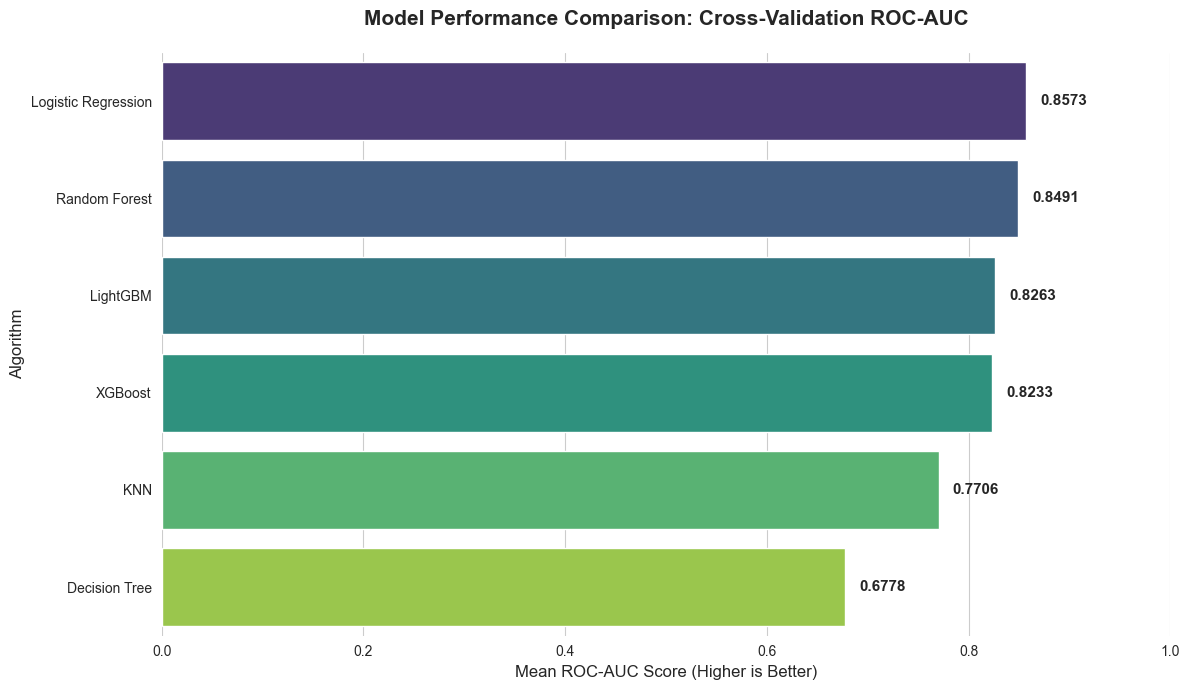

In [22]:
# =============================================================================
# VISUALIZING MODEL COMPARISON (HORIZONTAL BAR CHART)
# =============================================================================

# Set a professional seaborn theme for better aesthetics and readability
sns.set_style("whitegrid")

# Initialize the matplotlib figure with specific dimensions
fig, ax = plt.subplots(figsize=(12, 7))

# Create the horizontal bar plot using Seaborn
# Flipping axes: y becomes the categorical variable, x becomes the metric
sns.barplot(
    data=results_df,                # The source DataFrame containing our results
    x='Mean ROC-AUC',               # Horizontal axis representing performance
    y='Model',                      # Vertical axis representing model names
    palette='viridis',              # Apply a perceptually uniform color gradient
    hue='Model',                    # Map color to the model name
    legend=False                    # Suppress redundant legend
)

# --- Aesthetic Refinements ---

# Set the title with bold weight and increased font size
ax.set_title('Model Performance Comparison: Cross-Validation ROC-AUC', fontsize=15, fontweight='bold', pad=20)

# Label the axes clearly
ax.set_xlabel('Mean ROC-AUC Score (Higher is Better)', fontsize=12)
ax.set_ylabel('Algorithm', fontsize=12)

# Set the x-axis limits to focus on the competitive range (0.5 is random guessing)
ax.set_xlim(0, 1.0)               # Adjusting to 0.8 to highlight small differences

# --- Data Annotation ---

# Add value labels to the end of each bar for precise reading
# 'padding=10' pushes the text slightly to the right of the bar's end
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.4f',
        padding=10,
        fontsize=11,
        fontweight='bold'
    )

# Remove the top and right spines to create a "clean" modern look
sns.despine(left=True, bottom=True)

# Ensure the layout is optimized so no labels are cut off
plt.tight_layout()

# Render the final visualization
plt.show()

# Hyperparameter Tuning

## What are hyperparameters?

Every ML algorithm has two kinds of parameters:

| Type | Set by... | Examples |
|------|-----------|----------|
| **Parameters** (model weights) | Learned automatically during training | Logistic regression coefficients, tree split thresholds |
| **Hyperparameters** | Set *by us* before training begins | `max_depth`, `learning_rate`, `n_estimators` |

Hyperparameters control the *structure and behaviour* of the learning process itself — they are the dials we turn to optimise performance.

## What is Grid Search?

Grid Search exhaustively tries **every combination** of hyperparameter values we specify, evaluating each with cross-validation:

```
max_depth:    [3, 5, 7]          →  3 values
n_estimators: [100, 200, 300]    →  3 values
learning_rate:[0.05, 0.1, 0.3]  →  3 values
                                    ─────────
                           Total: 3×3×3 = 27 combinations
                        × 5-fold CV = 135 model fits!
```

It returns the combination that achieved the highest mean cross-validation score.

## Why `scoring='roc_auc'`?

Accuracy would be misleading here: a model that always predicts 'healthy' would score ~91% accuracy (since only ~9% of babies have low birthweight). ROC-AUC is insensitive to class imbalance and measures *ranking quality* — can the model separate the at-risk babies from the healthy ones?

## Why only tune the top 3 models?

Grid Search is computationally expensive. We focus tuning effort on **Random Forest, XGBoost, and LightGBM** — the models with the strongest baseline CV scores. Logistic Regression and KNN are tuned too (for completeness), but the tree ensemble models are the main candidates.

## Tune XGBoost, LightGBM, and Random Forest


In [23]:
# =============================================================================
# HYPERPARAMETER TUNING CONFIGURATION
# =============================================================================
# Three model families, each with architecture-appropriate search spaces.
#
# KEY DESIGN DECISIONS:
#   • GridSearchCV with cv=5 (StratifiedKFold) — preserves the ~9% minority
#     class in every fold, critical for an imbalanced dataset
#   • scoring='roc_auc' — insensitive to class imbalance; accuracy would be
#     misleading here (predicting "healthy" every time scores ~91%)
#   • class_weight='balanced' on RandomForest — upweights the minority class
#     proportional to its inverse frequency without touching the data
#   • Pipeline wraps preprocessor + classifier — guarantees no data leakage;
#     scaling/encoding is re-fitted inside each CV fold, never on the test fold
# =============================================================================

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

tuning_configs = {

    # ── Logistic Regression ───────────────────────────────────────────────────
    # Linear model that predicts the log-odds of the positive class.
    # Fast, interpretable, and a strong baseline — especially useful here
    # since we already know weeks and smoke are strong predictors.
    #
    # Key hyperparameters:
    #   C              — inverse regularisation strength; smaller C = stronger penalty,
    #                    shrinks coefficients toward zero to prevent overfitting
    #   penalty        — l2 (ridge) shrinks all coefficients; l1 (lasso) can zero some out
    #                    elasticnet combines both; only supported with solver='saga'
    #   solver         — algorithm used to optimise; 'saga' supports all penalty types
    #                    and scales well; 'lbfgs' is faster but only supports l2/none
    #   max_iter       — increase if you get ConvergenceWarning on scaled data
    # ── Logistic Regression ───────────────────────────────────────────────────
    # Despite being the simplest model, LR is a strong baseline.
    # We search over regularisation strength (C) and penalty type.
    'LogisticRegression': {
        'model': LogisticRegression(
            random_state=123,
            class_weight='balanced'   # handles the ~9% minority class
        ),
        'params': {
            'classifier__C':        [0.01, 0.1, 1, 10, 100],
            'classifier__penalty':  ['l1', 'l2', 'elasticnet'],
            'classifier__solver':   ['saga'],          # only solver supporting all three penalties
            'classifier__max_iter': [1000],
            'classifier__l1_ratio': [0.5],             # only used when penalty='elasticnet'
        }
    },

    # ── K-Nearest Neighbours ──────────────────────────────────────────────────
    # Non-parametric: classifies each point by majority vote of its k nearest
    # neighbours. No training phase — all computation happens at prediction time.
    # Sensitive to feature scaling (handled by the pipeline preprocessor) and
    # to the choice of k and distance metric.
    #
    # Key hyperparameters:
    #   n_neighbors    — k; too small = noisy boundary, too large = over-smoothed
    #   weights        — 'uniform': all k neighbours vote equally;
    #                    'distance': closer neighbours get more weight
    #   metric         — distance function; euclidean is standard for scaled data,
    #                    manhattan can work better with outliers
    'KNN': {
        'model': KNeighborsClassifier(),   # no random_state — algorithm is deterministic
        'params': {
            'classifier__n_neighbors': [3, 5, 7, 11, 15, 21],
            'classifier__weights':     ['uniform', 'distance'],
            'classifier__metric':      ['euclidean', 'manhattan'],
        }
    },


    # ── Random Forest ─────────────────────────────────────────────────────────
    # Ensemble of deep, independent decision trees trained on random subsets of
    # data (bagging) and features. Robust, interpretable, good baseline.
    #
    # Key hyperparameters:
    #   n_estimators      — more trees = more stable predictions, diminishing returns after ~300
    #   max_depth         — controls overfitting; None = fully grown trees (may overfit on small data)
    #   min_samples_split — minimum samples to split a node; higher = more regularisation
    #   min_samples_leaf  — minimum samples at a leaf; higher = smoother decision boundary
    #   max_features      — features considered per split; 'sqrt' is the standard for classification
    'RandomForest': {
        'model': RandomForestClassifier(
            random_state=123,
            class_weight='balanced'      # critical for imbalanced birth weight target (~9% positive)
        ),
        'params': {
            'classifier__n_estimators':      [100, 200, 500],
            'classifier__max_depth':         [3, 5, 10, None],
            'classifier__min_samples_split': [2, 5, 10],
            'classifier__min_samples_leaf':  [1, 2, 4],
            'classifier__max_features':      ['sqrt', 'log2'],
        }
    },

    # ── XGBoost ───────────────────────────────────────────────────────────────
    # Sequential boosting: each tree corrects the residual errors of the previous.
    # Generally outperforms Random Forest on tabular data but more sensitive to
    # hyperparameter choices and prone to overfitting on small datasets.
    #
    # Key hyperparameters:
    #   learning_rate  — shrinks each tree's contribution; lower = more robust but needs more trees
    #   max_depth      — shallower trees (3–6) are typical for boosting; deep trees overfit fast
    #   subsample      — row sampling per tree; <1.0 introduces randomness, reduces overfitting
    'XGBoost': {
        'model': XGBClassifier(
            random_state=123,
            use_label_encoder=False,
            eval_metric='logloss'
        ),
        'params': {
            'classifier__n_estimators':  [100, 200],
            'classifier__learning_rate': [0.05, 0.1],
            'classifier__max_depth':     [3, 6],
            'classifier__subsample':     [0.8, 1.0],
        }
    },

    # ── LightGBM ──────────────────────────────────────────────────────────────
    # Leaf-wise boosting (vs level-wise in XGBoost): grows the leaf with the
    # largest loss reduction at each step. Faster and often more accurate on
    # larger datasets, but more prone to overfitting on small ones.
    #
    # Key hyperparameters:
    #   num_leaves     — primary complexity control for LightGBM; must be < 2^max_depth
    #                    higher = more expressive but overfits more easily
    #   max_depth      — -1 means unlimited; use alongside num_leaves to constrain complexity
    'LightGBM': {
        'model': LGBMClassifier(
            random_state=123,
            verbose=-1
        ),
        'params': {
            'classifier__n_estimators':  [100, 200],
            'classifier__learning_rate': [0.05, 0.1],
            'classifier__num_leaves':    [31, 50],
            'classifier__max_depth':     [-1, 10],
        }
    },
}

import time as time_module

# Containers to hold summary metrics and the full search objects
tuning_results = []     # collects per-model summary dicts for the final table
grid_objects   = {}     # stores the full GridSearchCV objects — needed for plots

# =============================================================================
# EXECUTION OF GRID SEARCH
# =============================================================================
# StratifiedKFold is used explicitly to preserve class balance across folds.
# With only ~9% positive cases, standard KFold could produce folds with very
# few or zero positive examples, making AUC estimates unreliable.
# =============================================================================

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, config in tuning_configs.items():

    # Wrap preprocessor + model in a pipeline
    # This is non-negotiable: if you scale outside the pipeline, the scaler
    # sees the validation fold during fitting — that is data leakage.
    tuning_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier',   config['model'])
    ])

    grid_search = GridSearchCV(
        tuning_pipeline,
        config['params'],
        cv      = cv_strategy,   # stratified 5-fold
        scoring = 'roc_auc',     # not accuracy — imbalanced classes make accuracy misleading
        n_jobs  = -1,            # parallelise across all available CPU cores
        verbose = 0,
        refit   = True           # refit best params on full X_train after search completes
    )

    start_time = time_module.time()       # ✅ was time.time()
    grid_search.fit(X_train, y_train)
    duration = time_module.time() - start_time   # ✅ was time.time()

    # Store the full object — required for CV heatmaps and learning curves downstream
    grid_objects[name] = grid_search

    tuning_results.append({
        'Model':          name,
        'Best ROC-AUC':   grid_search.best_score_,
        'Time Taken (s)': duration,
        'Best Params':    grid_search.best_params_
    })

    print(f"[COMPLETED] {name:.<15} Time: {duration:>6.2f}s | Best ROC-AUC: {grid_search.best_score_:.4f}")

# =============================================================================
# TUNING SUMMARY REPORT
# =============================================================================

tuning_df = pd.DataFrame(tuning_results).sort_values('Best ROC-AUC', ascending=False)

print("\n" + "="*80)
print(f"{'FINAL HYPERPARAMETER TUNING SUMMARY':^80}")
print("="*80)
print(tuning_df[['Model', 'Best ROC-AUC', 'Time Taken (s)']].to_string(index=False, justify='center'))
print("="*80)

winner = tuning_df.iloc[0]
print(f"\nWINNING MODEL:       {winner['Model']}")
print(f"OPTIMAL CONFIG:      {winner['Best Params']}")
print(f"\nNOTE: RandomForest used class_weight='balanced' to handle the ~9% minority")
print(f"class. XGBoost and LightGBM use equal weights — consider scale_pos_weight")
print(f"(XGBoost) or is_unbalance=True (LightGBM) if recall on positives is too low.")

[COMPLETED] LogisticRegression Time:   0.97s | Best ROC-AUC: 0.8743
[COMPLETED] KNN............ Time:   0.13s | Best ROC-AUC: 0.8200
[COMPLETED] RandomForest... Time:  12.51s | Best ROC-AUC: 0.8800
[COMPLETED] XGBoost........ Time:   0.35s | Best ROC-AUC: 0.8602
[COMPLETED] LightGBM....... Time:  46.06s | Best ROC-AUC: 0.8559

                      FINAL HYPERPARAMETER TUNING SUMMARY                       
      Model         Best ROC-AUC  Time Taken (s)
      RandomForest    0.880033      12.508125   
LogisticRegression    0.874316       0.969834   
           XGBoost    0.860206       0.354433   
          LightGBM    0.855925      46.059354   
               KNN    0.819987       0.133234   

WINNING MODEL:       RandomForest
OPTIMAL CONFIG:      {'classifier__max_depth': 3, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 500}

NOTE: RandomForest used class_weight='balanced' to handle the ~9% mino

## Visualize Hyperparameter Tuning Results

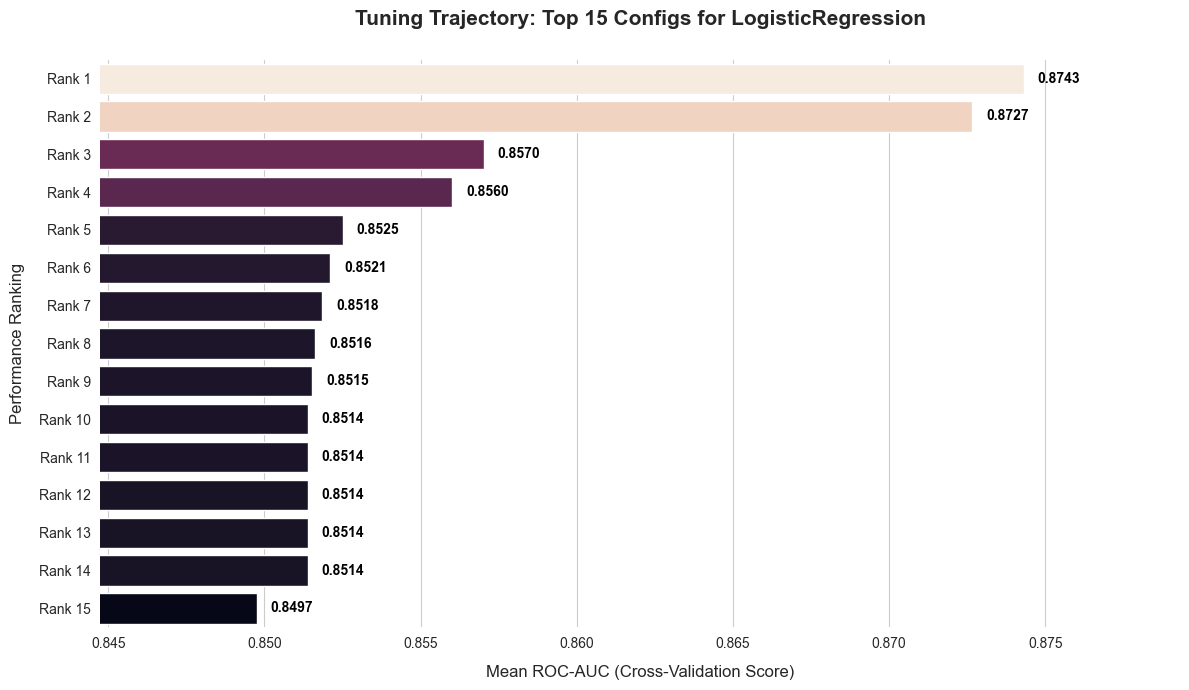

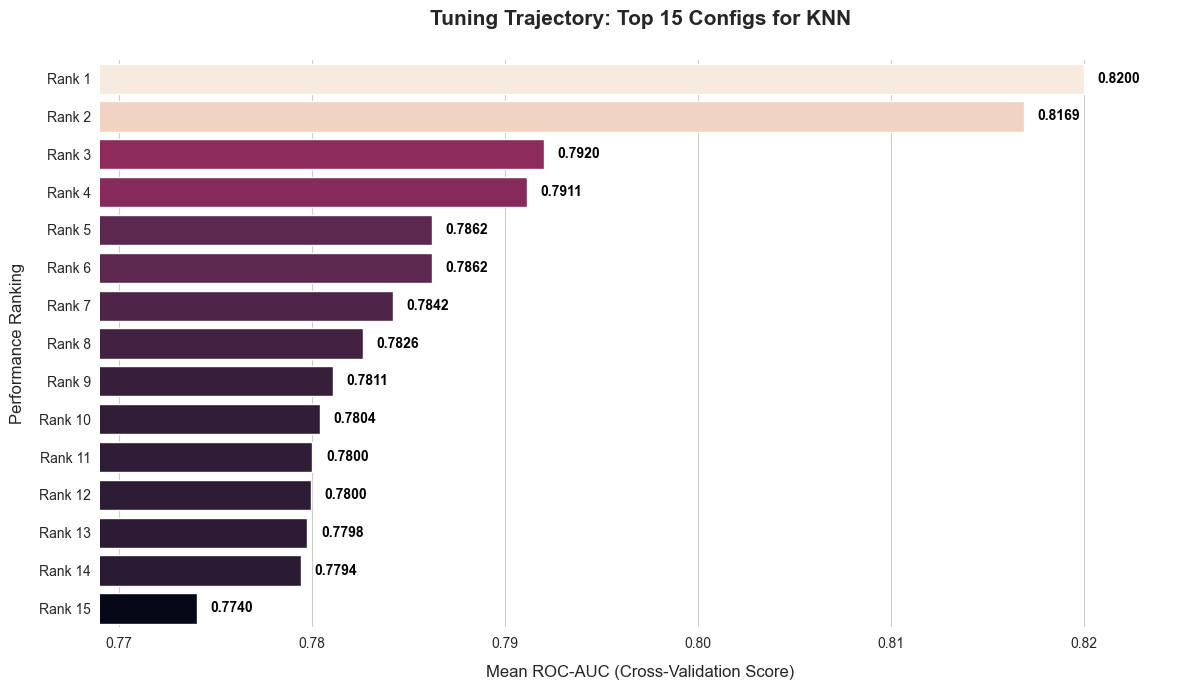

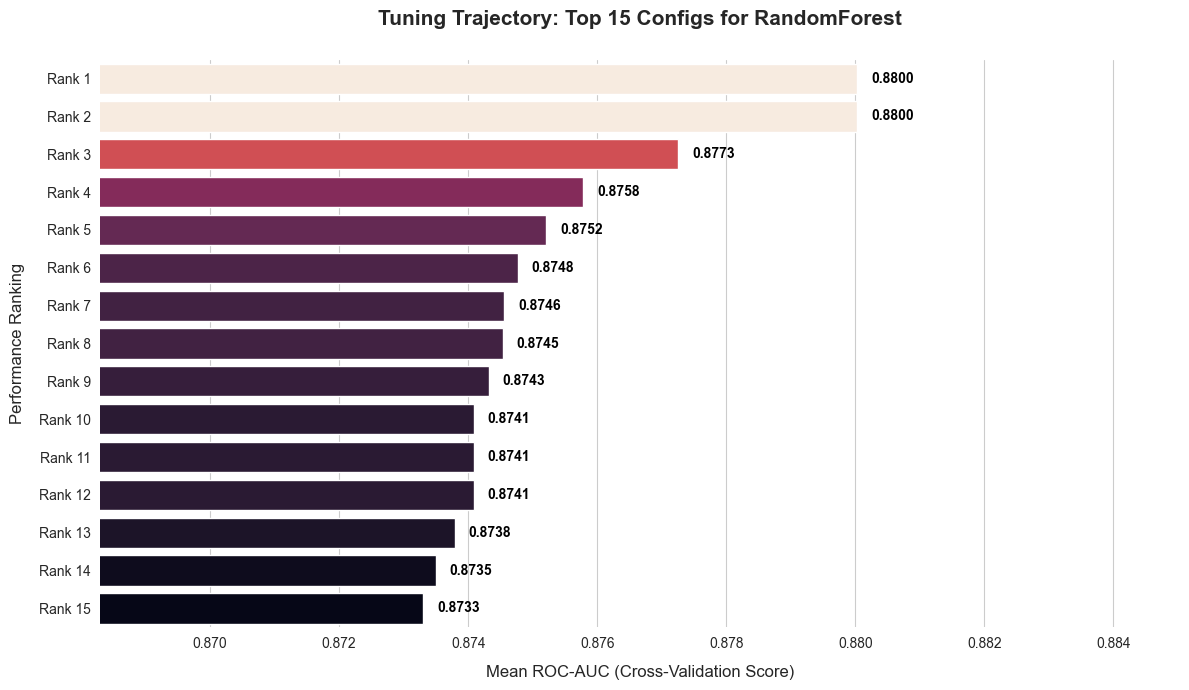

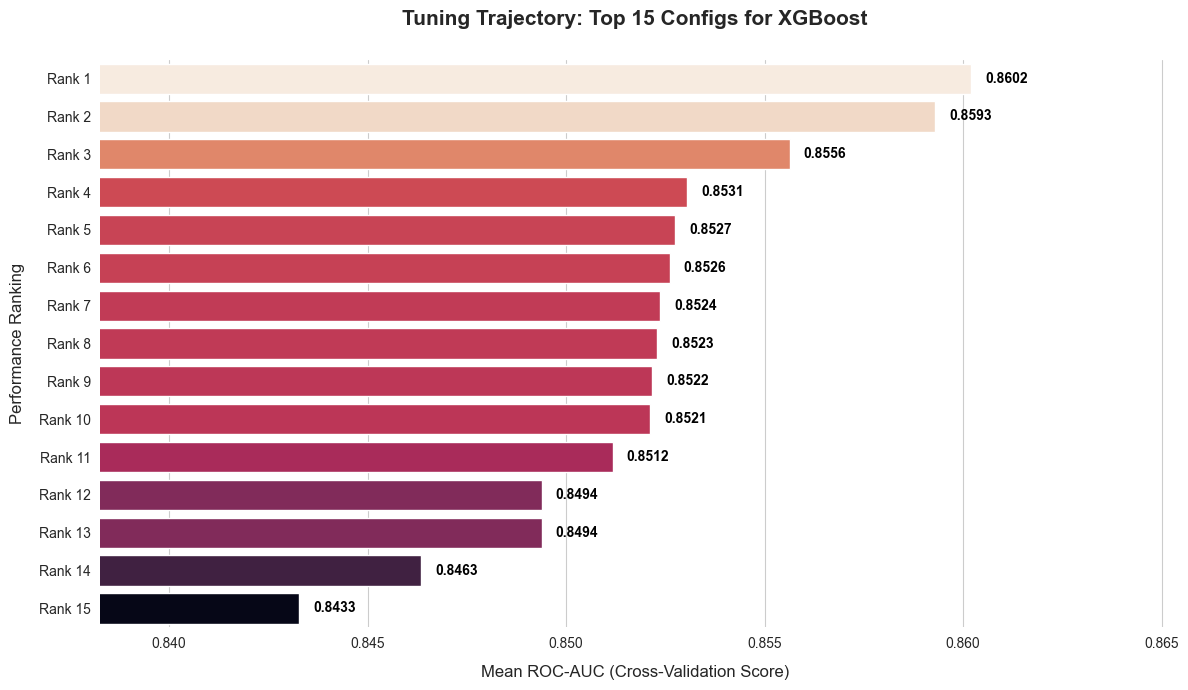

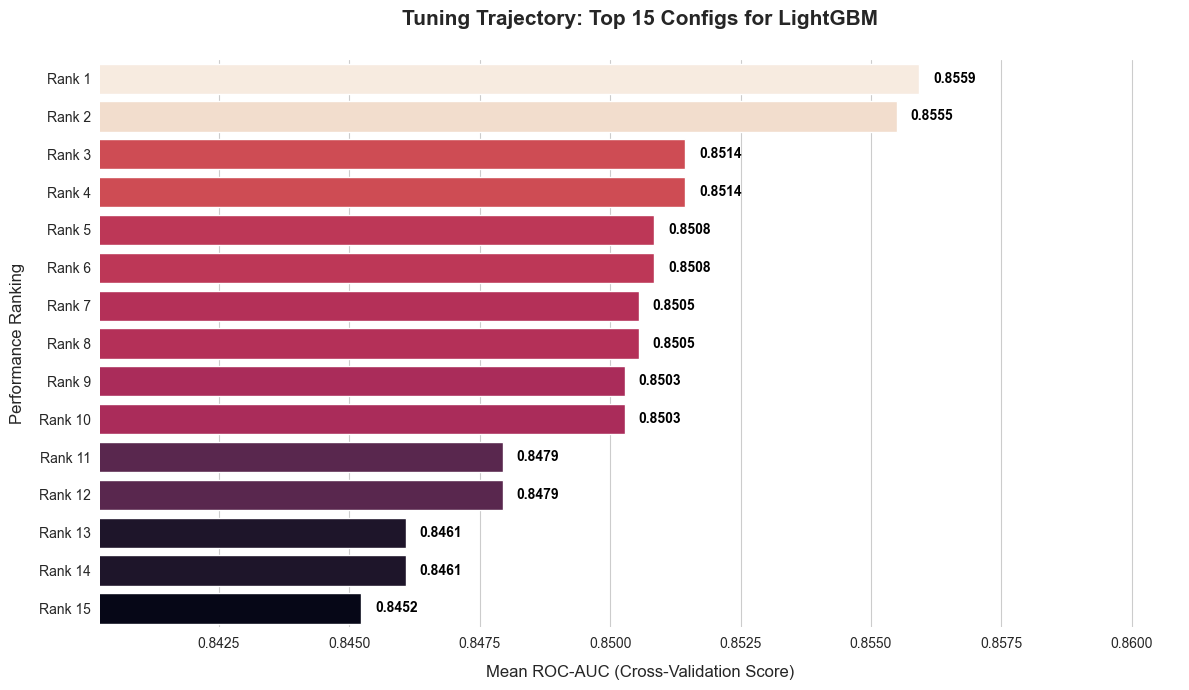

In [24]:
# =============================================================================
# VISUALIZING HYPERPARAMETER TUNING HISTORY
# =============================================================================

def plot_tuning_results(grid_search_obj, model_name):
    """
    Renders an elegant Seaborn visualization of the top-performing 
    hyperparameter configurations for a given model.
    """
    # Convert the complex grid_search results into a clean Pandas DataFrame
    cv_results = pd.DataFrame(grid_search_obj.cv_results_)
    
    # Isolate the top 15 results to ensure the chart remains legible and uncluttered
    top_15 = cv_results.nlargest(15, 'mean_test_score').copy()
    
    # Create descriptive ranking labels for the vertical axis
    top_15['Rank Label'] = [f"Rank {i+1}" for i in range(len(top_15))]
    
    # Set the visual style to a clean, professional grid
    sns.set_style("whitegrid")
    
    # Initialize the figure with a size appropriate for horizontal bars
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Create the horizontal bar plot using a high-contrast 'rocket' palette
    # Rocket moves from dark to light, emphasizing the highest scores
    sns.barplot(
        data=top_15,                   # The source data
        x='mean_test_score',           # X-axis: The ROC-AUC score
        y='Rank Label',                # Y-axis: The configuration rank
        hue='mean_test_score',         # Color mapping tied to the score
        palette='rocket',              # Sequential color scheme
        legend=False                   # Disable the redundant color legend
    )
    
    # --- Title and Axis Labeling ---
    
    # Add a bold, descriptive title with significant padding
    ax.set_title(f'Tuning Trajectory: Top 15 Configs for {model_name}', fontsize=15, fontweight='bold', pad=25)
    
    # Clearly label the x-axis with the metric name
    ax.set_xlabel('Mean ROC-AUC (Cross-Validation Score)', fontsize=12, labelpad=10)
    
    # Clearly label the y-axis
    ax.set_ylabel('Performance Ranking', fontsize=12, labelpad=10)
    
    # --- Dynamic X-Axis Scaling ---
    
    # Zoom into the performance range to make the differences visible
    # We subtract 0.005 from the lowest score to provide a small visual buffer
    xmin = top_15['mean_test_score'].min() - 0.005
    xmax = top_15['mean_test_score'].max() + 0.005
    ax.set_xlim(xmin, xmax)
    
    # --- Precise Data Annotations ---
    
    # Automatically add the exact score at the tip of each bar
    # Loop over all containers — seaborn creates one per bar when using hue
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt='%.4f',                    # Display as 4-decimal floats
            padding=10,                    # Space between bar and text
            fontweight='bold',             # Make the scores stand out
            color='black'                  # Ensure high contrast text
        )
    
    # Remove the top and right spines to follow modern "clean data" design principles
    sns.despine(left=True, bottom=True)
    
    # Adjust layout to ensure labels are not clipped
    plt.tight_layout()
    
    # Render the chart to the screen
    plt.show()

# =============================================================================
# 13. EXECUTION OF VISUALIZATIONS
# =============================================================================

# Iterate through each stored grid search object to generate the diagnostic plots
for name, gs in grid_objects.items():
    plot_tuning_results(gs, name)      # Run the visualization for XGBoost, then LightGBM

# Final Model Evaluation on Test Set

## The moment of truth: the hold-out test set

Everything up to this point — cross-validation, hyperparameter tuning — was done **exclusively on training data**. The test set has been locked away, untouched.

Now we evaluate the tuned models on this genuinely unseen data. This is the only honest estimate of how the model will perform in the real world.

### Why is this different from CV scores?

| Evaluation type | Data used | Purpose |
|-----------------|-----------|----------|
| Cross-validation | Training data (5 folds) | Model selection & hyperparameter tuning |
| **Test set** | **Held-out 20%** | **Final, honest performance estimate** |

It is normal for test scores to be slightly *lower* than CV scores — the model has never seen this data, so there is no optimistic bias. A large gap between CV and test performance is a warning sign of **overfitting**.

### The five metrics explained

| Metric | Formula | Plain English |
|--------|---------|---------------|
| **Accuracy** | (TP+TN) / all | % of all predictions that are correct |
| **Precision** | TP / (TP+FP) | Of all babies flagged as 'low', what % truly are? |
| **Recall** | TP / (TP+FN) | Of all truly low babies, what % did we catch? |
| **F1-Score** | 2×P×R/(P+R) | Harmonic mean — balances precision and recall |
| **ROC-AUC** | Area under curve | Probability of ranking a random positive above a random negative |

> ⚕️ **Clinical note:** In a medical context, **Recall** is often the most important metric — missing a high-risk baby (False Negative) is more dangerous than a false alarm (False Positive). The threshold can be lowered to increase recall at the cost of precision.



LogisticRegression — Best Parameters:
  C                        : 0.01
  l1_ratio                 : 0.5
  max_iter                 : 1000
  penalty                  : l1
  solver                   : saga

KNN — Best Parameters:
  metric                   : euclidean
  n_neighbors              : 21
  weights                  : uniform

RandomForest — Best Parameters:
  max_depth                : 3
  max_features             : sqrt
  min_samples_leaf         : 4
  min_samples_split        : 2
  n_estimators             : 500

XGBoost — Best Parameters:
  learning_rate            : 0.05
  max_depth                : 3
  n_estimators             : 200
  subsample                : 0.8

LightGBM — Best Parameters:
  learning_rate            : 0.05
  max_depth                : -1
  n_estimators             : 200
  num_leaves               : 31

               MODEL COMPARISON — TEST SET PERFORMANCE                
                     RandomForest LogisticRegression XGBoost LightGBM     KNN


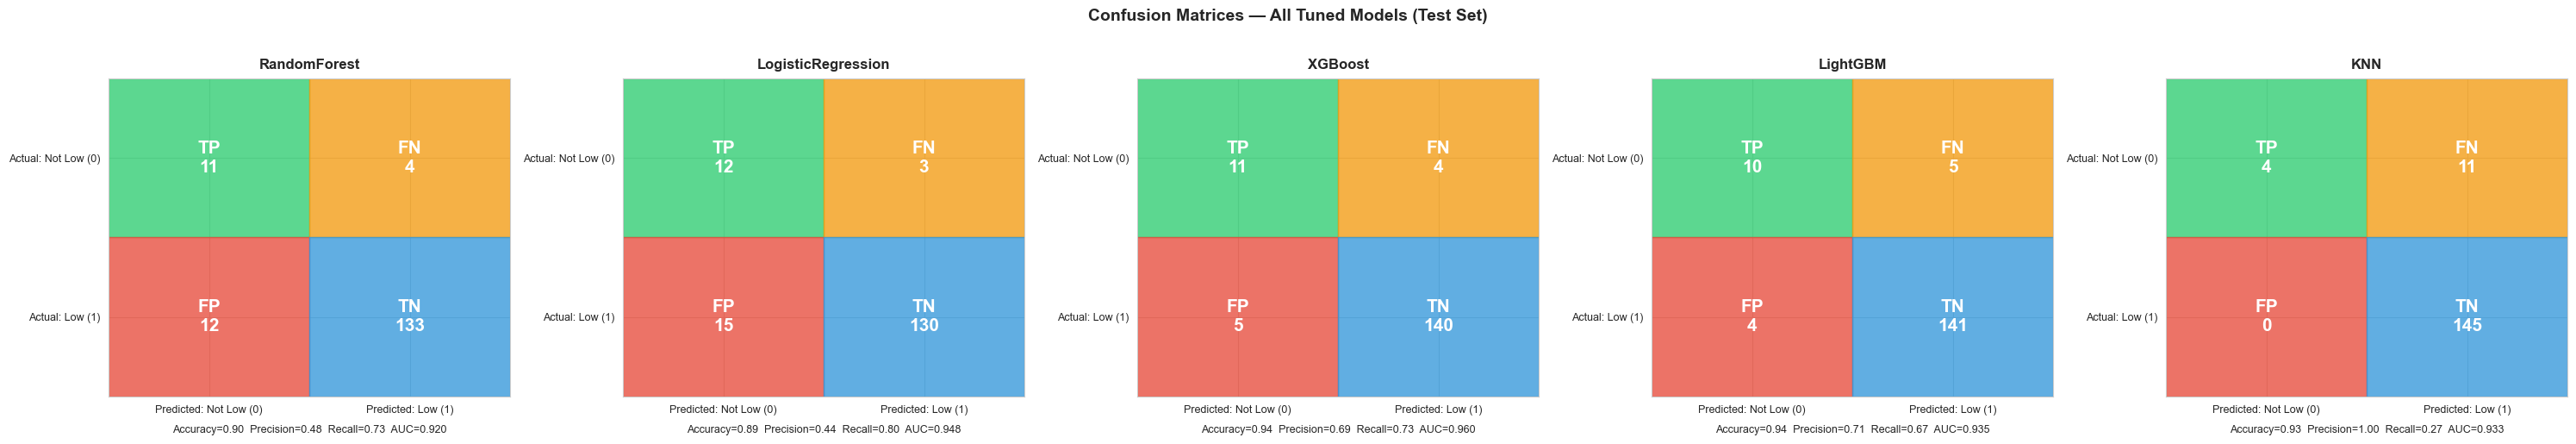

In [25]:
# =============================================================================
# FINAL EVALUATION ON THE HOLD-OUT TEST SET — ALL TUNED MODELS
# =============================================================================
# Evaluates every tuned model on the held-out test set in CV AUC-ranked order.
# Results are stored in all_results for downstream use (confusion matrices,
# ROC curves, feature importance, SHAP values etc.)
# =============================================================================


# =============================================================================
# EXTRACT & DISPLAY BEST PARAMETERS PER MODEL
# =============================================================================

best_params = {}

for name in grid_objects:
    best_params[name] = grid_objects[name].best_params_
    print(f"\n{name} — Best Parameters:")
    for param, value in grid_objects[name].best_params_.items():
        clean_name = param.replace('classifier__', '')   # strip pipeline prefix
        print(f"  {clean_name:<25}: {value}")

# Access individual model best parameters directly, e.g. for reporting
rf_best_params  = best_params['RandomForest']
xgb_best_params = best_params['XGBoost']
lgbm_best_params = best_params['LightGBM']

all_results = {}

for model_name in tuning_df['Model']:

    # .best_estimator_ is the fully fitted Pipeline using the best hyperparameters found
    pipeline     = grid_objects[model_name].best_estimator_
    y_pred       = pipeline.predict(X_test)
    # predict_proba()[:, 1] gives P(class=1) — the probability of low birthweight
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

    final_metrics = {
        'Accuracy':             accuracy_score(y_test, y_pred),
        'Precision':            precision_score(y_test, y_pred, pos_label=1),
        'Recall (Sensitivity)': recall_score(y_test, y_pred, pos_label=1),
        'F1-Score':             f1_score(y_test, y_pred, pos_label=1),
        'ROC-AUC':              roc_auc_score(y_test, y_pred_proba)
    }

    all_results[model_name] = {
        'pipeline': pipeline,
        'y_pred':   y_pred,
        'y_proba':  y_pred_proba,
        'metrics':  final_metrics
    }

# =============================================================================
# SUMMARY TABLE — ROWS = METRICS, COLUMNS = MODELS
# =============================================================================
# CV time is appended as the final row, sourced from the tuning summary so
# everything is visible in one place for easy comparison.
# =============================================================================

# Build base table: rows = metrics, columns = model names
comparison_df = pd.DataFrame(
    {name: res['metrics'] for name, res in all_results.items()}
)

# Append CV time row from the tuning summary recorded during grid search
cv_times = tuning_df.set_index('Model')['Time Taken (s)'].to_dict()
comparison_df.loc['CV Time (s)'] = {name: cv_times[name] for name in comparison_df.columns}

# Format in place — percentages for metrics, seconds for CV time
display_df = comparison_df.copy()
for idx in display_df.index:
    for col in display_df.columns:
        v = display_df.loc[idx, col]
        display_df.loc[idx, col] = f"{v:.2f}s" if idx == 'CV Time (s)' else f"{v:.1%}"

print("\n" + "="*70)
print(f"{'MODEL COMPARISON — TEST SET PERFORMANCE':^70}")
print("="*70)
print(display_df.to_string())
print("="*70)

# Highlight the best model per metric
print("\nBEST MODEL PER METRIC:")
for metric in comparison_df.index:
    if metric == 'CV Time (s)':
        best = comparison_df.loc[metric].idxmin()
        print(f"  {'Fastest CV':<24}: {best}  ({comparison_df.loc[metric, best]:.2f}s)")
    else:
        best = comparison_df.loc[metric].idxmax()
        print(f"  {metric:<24}: {best}  ({comparison_df.loc[metric, best]:.1%})")

# =============================================================================
# CONFUSION MATRICES — ALL MODELS SIDE BY SIDE
# =============================================================================

fig, axes = plt.subplots(1, len(all_results), figsize=(6 * len(all_results), 5))

if len(all_results) == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, all_results.items()):
    plot_confusion_matrix(ax, y_test, res['y_pred'],
                          title=name, y_proba=res['y_proba'])

plt.suptitle('Confusion Matrices — All Tuned Models (Test Set)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


LogisticRegression — Best Parameters:
  C                        : 0.01
  l1_ratio                 : 0.5
  max_iter                 : 1000
  penalty                  : l1
  solver                   : saga

KNN — Best Parameters:
  metric                   : euclidean
  n_neighbors              : 21
  weights                  : uniform

RandomForest — Best Parameters:
  max_depth                : 3
  max_features             : sqrt
  min_samples_leaf         : 4
  min_samples_split        : 2
  n_estimators             : 500

XGBoost — Best Parameters:
  learning_rate            : 0.05
  max_depth                : 3
  n_estimators             : 200
  subsample                : 0.8

LightGBM — Best Parameters:
  learning_rate            : 0.05
  max_depth                : -1
  n_estimators             : 200
  num_leaves               : 31


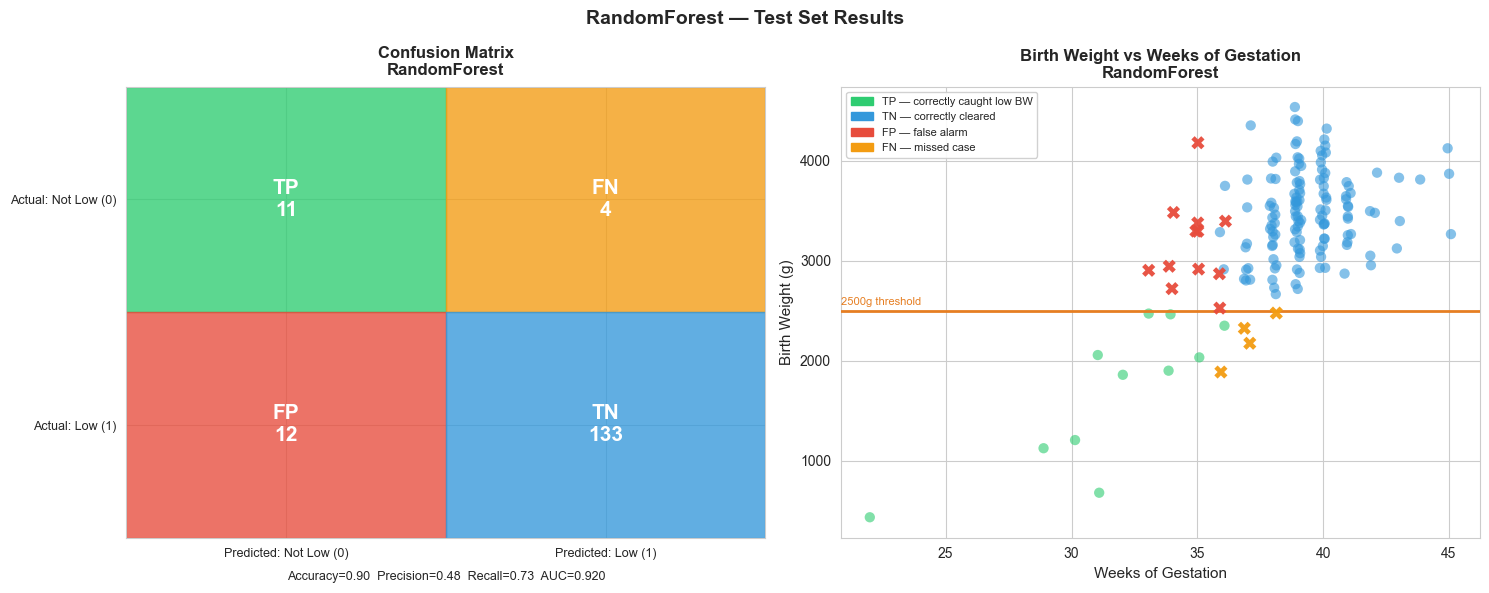

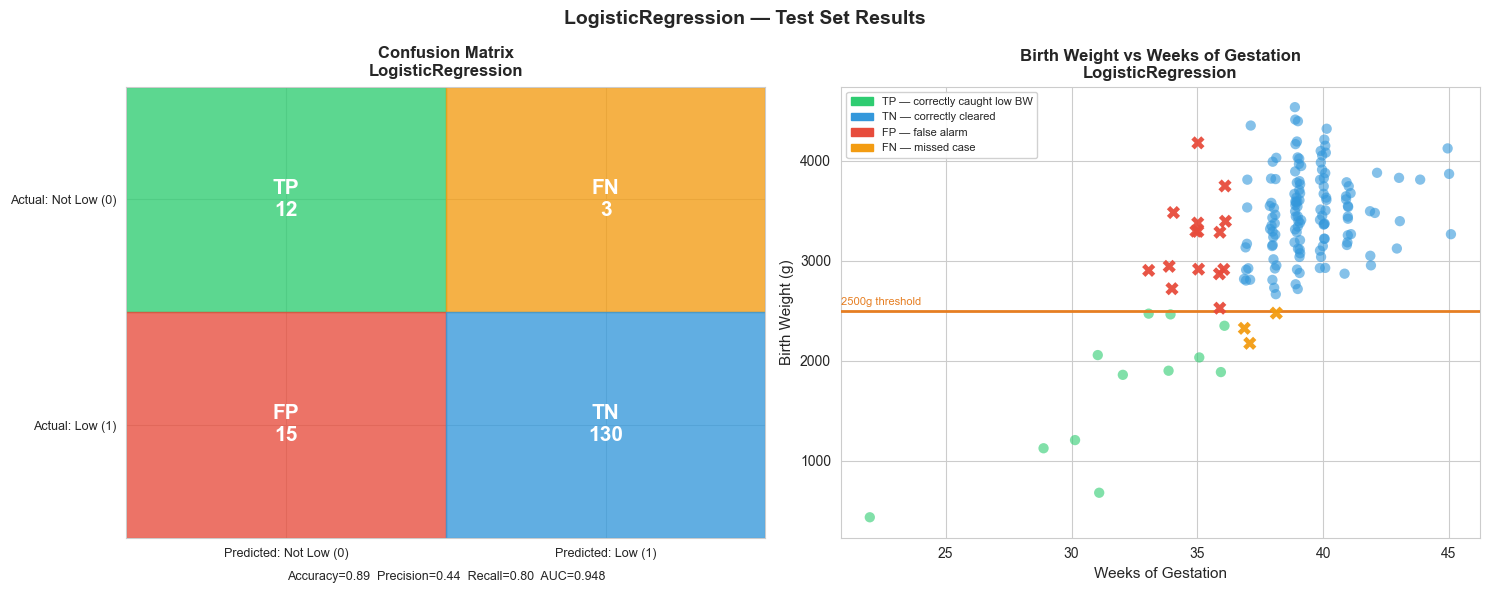

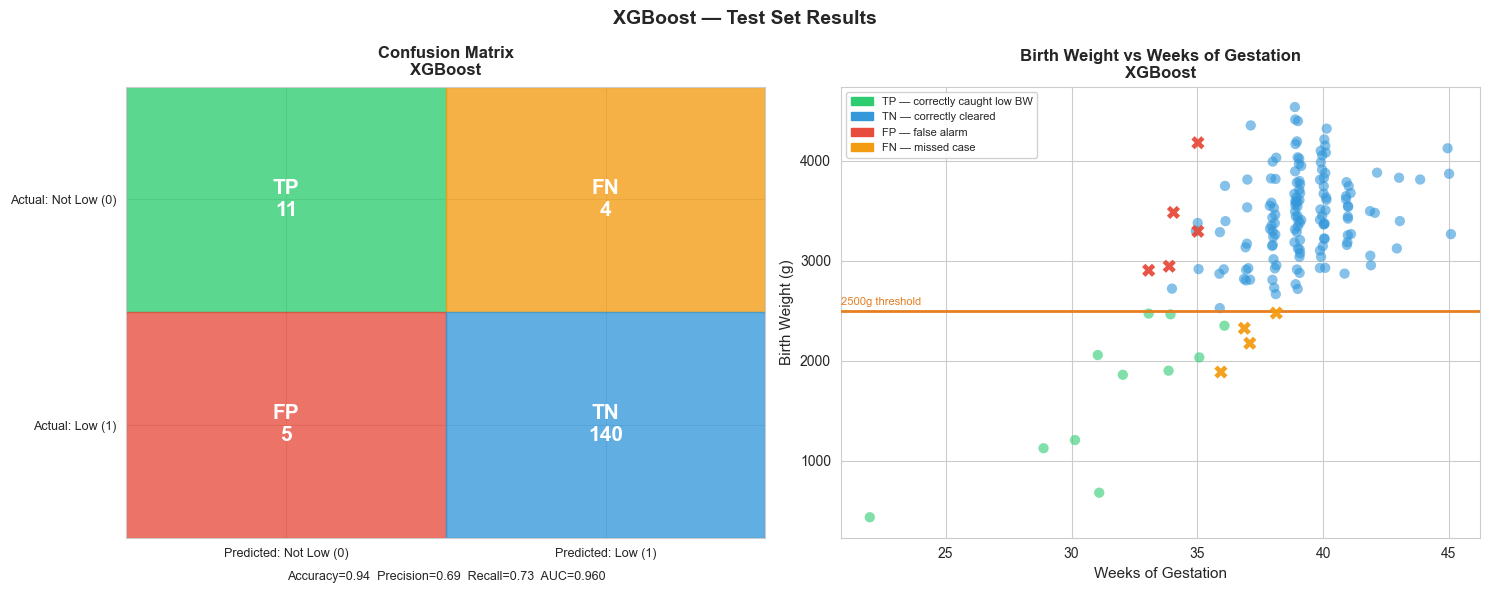

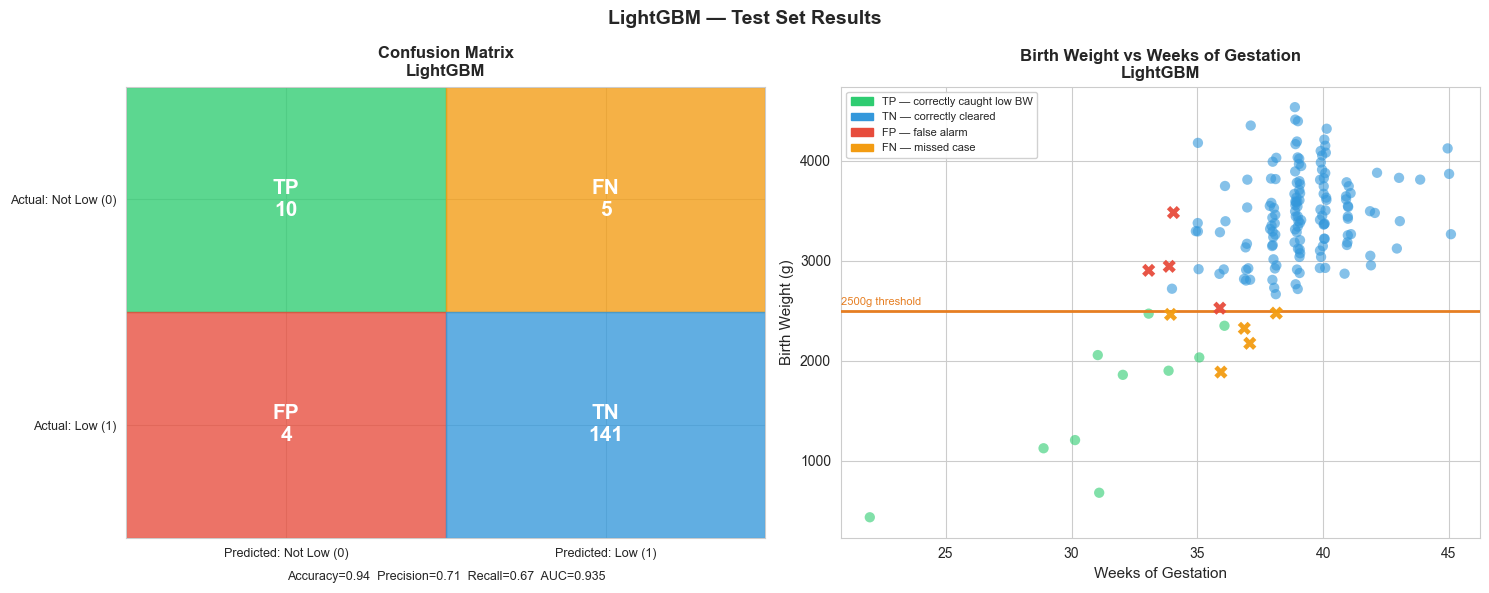

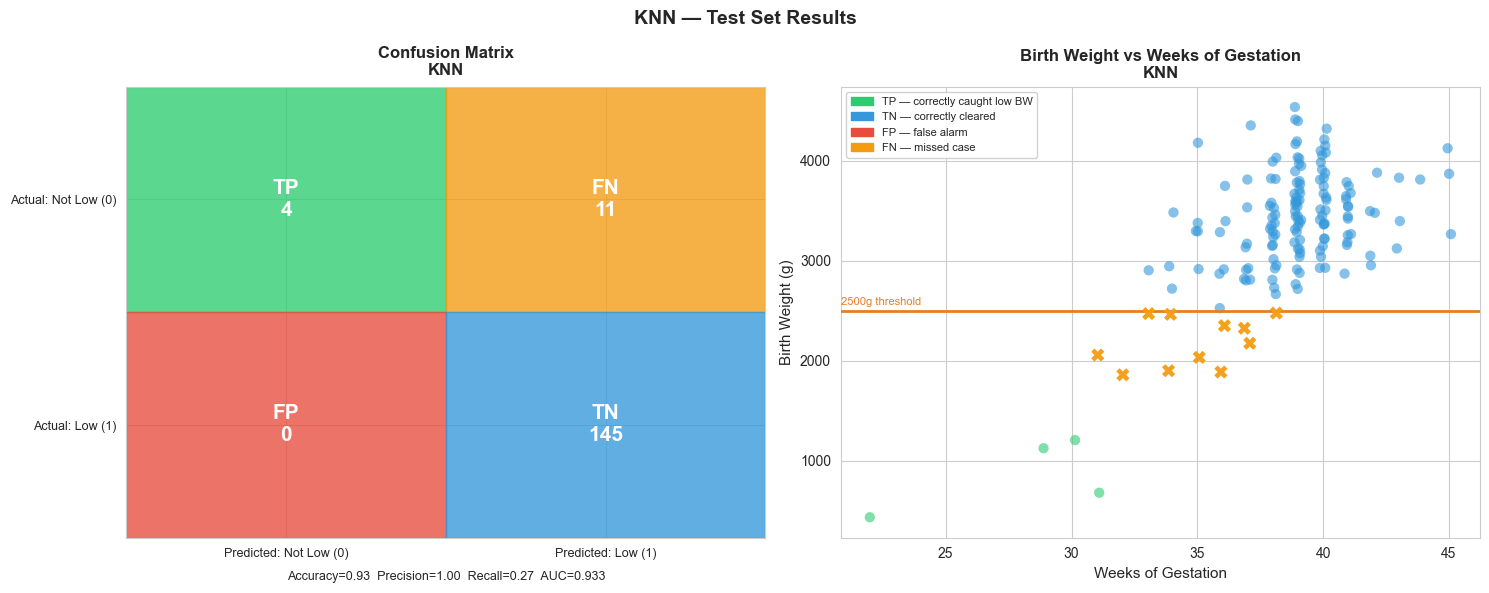


               MODEL COMPARISON — TEST SET PERFORMANCE                
                     RandomForest LogisticRegression XGBoost LightGBM     KNN
Accuracy                    90.0%              88.8%   94.4%    94.4%   93.1%
Precision                   47.8%              44.4%   68.8%    71.4%  100.0%
Recall (Sensitivity)        73.3%              80.0%   73.3%    66.7%   26.7%
F1-Score                    57.9%              57.1%   71.0%    69.0%   42.1%
ROC-AUC                     92.0%              94.8%   96.0%    93.5%   93.3%
CV Time (s)                12.51s              0.97s   0.35s   46.06s   0.13s

BEST MODEL PER METRIC:
  Accuracy                : XGBoost  (94.4%)
  Precision               : KNN  (100.0%)
  Recall (Sensitivity)    : LogisticRegression  (80.0%)
  F1-Score                : XGBoost  (71.0%)
  ROC-AUC                 : XGBoost  (96.0%)
  Fastest CV              : KNN  (0.13s)


In [26]:
# =============================================================================
# FINAL EVALUATION ON THE HOLD-OUT TEST SET — ALL TUNED MODELS
# =============================================================================

# =============================================================================
# EXTRACT & DISPLAY BEST PARAMETERS PER MODEL
# =============================================================================

best_params = {}

for name in grid_objects:
    best_params[name] = grid_objects[name].best_params_
    print(f"\n{name} — Best Parameters:")
    for param, value in grid_objects[name].best_params_.items():
        clean_name = param.replace('classifier__', '')   # strip pipeline prefix
        print(f"  {clean_name:<25}: {value}")

# Access individual model best parameters directly, e.g. for reporting
rf_best_params  = best_params['RandomForest']
xgb_best_params = best_params['XGBoost']
lgbm_best_params = best_params['LightGBM']

all_results = {}

for model_name in tuning_df['Model']:

    pipeline     = grid_objects[model_name].best_estimator_
    y_pred       = pipeline.predict(X_test)
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

    final_metrics = {
        'Accuracy':             accuracy_score(y_test, y_pred),
        'Precision':            precision_score(y_test, y_pred, pos_label=1),
        'Recall (Sensitivity)': recall_score(y_test, y_pred, pos_label=1),
        'F1-Score':             f1_score(y_test, y_pred, pos_label=1),
        'ROC-AUC':              roc_auc_score(y_test, y_pred_proba)
    }

    all_results[model_name] = {
        'pipeline': pipeline,
        'y_pred':   y_pred,
        'y_proba':  y_pred_proba,
        'metrics':  final_metrics
    }

    # ── Two-panel plot for this model ─────────────────────────────────────
    weight_g_test = ncbirths_clean.loc[X_test.index, 'weight_kg'].values * 1000

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(f'{model_name} — Test Set Results', fontsize=14, fontweight='bold')

    plot_confusion_matrix(axes[0], y_test, y_pred,
                          f'Confusion Matrix\n{model_name}',
                          y_proba=y_pred_proba)

    plot_weight_vs_weeks(axes[1], X_test, y_test.values, y_pred, weight_g_test,
                         f'Birth Weight vs Weeks of Gestation\n{model_name}')

    plt.tight_layout()
    plt.show()

# =============================================================================
# SUMMARY TABLE — ROWS = METRICS, COLUMNS = MODELS
# =============================================================================

comparison_df = pd.DataFrame(
    {name: res['metrics'] for name, res in all_results.items()}
)

cv_times = tuning_df.set_index('Model')['Time Taken (s)'].to_dict()
comparison_df.loc['CV Time (s)'] = {name: cv_times[name] for name in comparison_df.columns}

display_df = comparison_df.copy()
for idx in display_df.index:
    for col in display_df.columns:
        v = display_df.loc[idx, col]
        display_df.loc[idx, col] = f"{v:.2f}s" if idx == 'CV Time (s)' else f"{v:.1%}"

print("\n" + "="*70)
print(f"{'MODEL COMPARISON — TEST SET PERFORMANCE':^70}")
print("="*70)
print(display_df.to_string())
print("="*70)

print("\nBEST MODEL PER METRIC:")
for metric in comparison_df.index:
    if metric == 'CV Time (s)':
        best = comparison_df.loc[metric].idxmin()
        print(f"  {'Fastest CV':<24}: {best}  ({comparison_df.loc[metric, best]:.2f}s)")
    else:
        best = comparison_df.loc[metric].idxmax()
        print(f"  {metric:<24}: {best}  ({comparison_df.loc[metric, best]:.1%})")

In [27]:
# =============================================================================
# AUC COMPARISON: PRE-TUNING vs POST-TUNING vs TEST SET
# =============================================================================
# This table shows the full journey for each model:
#   Pre-tune CV AUC  : baseline 5-fold CV score before hyperparameter search
#   Tuning CV AUC    : best 5-fold CV score found by Grid Search
#   Test AUC         : honest score on the unseen 20% test set
#   Tuning Gap       : Tuning CV AUC − Test AUC (positive = some optimistic bias)
# =============================================================================

# Look up pre-tuning CV AUC from the original benchmarking results
pretune_lookup = results_df.set_index('Model')

# Map between grid search keys (e.g., 'RandomForest') and CV results keys (e.g., 'Random Forest')
name_map = {
    'LogisticRegression': 'Logistic Regression', 
    'KNN':                'KNN',                 
    'RandomForest':       'Random Forest',
    'XGBoost':            'XGBoost',
    'LightGBM':           'LightGBM',
}

# Build the comparison DataFrame row by row
rows = {}
for name, res in all_results.items():
    pretune_auc = pretune_lookup.loc[name_map[name], 'Mean ROC-AUC']
    tuning_auc  = tuning_df.set_index('Model').loc[name, 'Best ROC-AUC']
    test_auc    = res['metrics']['ROC-AUC']
    rows[name]  = {
        'Pre-tune CV AUC': pretune_auc,
        'Tuning CV AUC':   tuning_auc,
        'Test AUC':        test_auc,
        # Tuning Gap > 0 means CV was optimistic relative to unseen test data
        # A large gap suggests the model memorised CV folds (overfitting the search)
        'Tuning Gap':      tuning_auc - test_auc,
    }

# rows = metrics, columns = models (already transposed)
summary_df = pd.DataFrame(rows)

# Format: '+' sign for gaps (makes positive/negative gap immediately obvious)
display_df = summary_df.copy()
for idx in display_df.index:
    for col in display_df.columns:
        v = display_df.loc[idx, col]
        display_df.loc[idx, col] = f"{v:+.3f}" if idx == 'Tuning Gap' else f"{v:.3f}"

print("\n" + "="*73)
print(f"{'AUC COMPARISON ACROSS PIPELINE STAGES':^73}")
print("="*73)
print(display_df.to_string())
print("="*73)



                  AUC COMPARISON ACROSS PIPELINE STAGES                  
                RandomForest LogisticRegression XGBoost LightGBM     KNN
Pre-tune CV AUC        0.849              0.857   0.823    0.826   0.771
Tuning CV AUC          0.880              0.874   0.860    0.856   0.820
Test AUC               0.920              0.948   0.960    0.935   0.933
Tuning Gap            -0.040             -0.074  -0.099   -0.079  -0.113


## Model Comparison: Predictive Power vs Training Speed

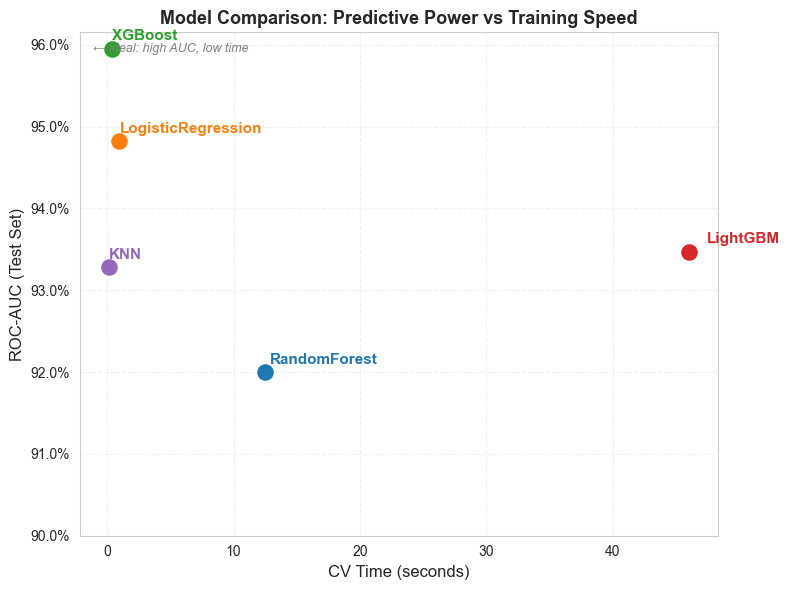

In [ ]:
# =============================================================================
# ROC-AUC vs CV TIME — MODEL COMPARISON SCATTER 
# =============================================================================

fig, ax = plt.subplots(figsize=(8, 6))

# Dynamically assign tab10 colours to however many models are in all_results
tab10     = plt.cm.get_cmap('tab10')
colours   = {name: tab10(i) for i, name in enumerate(all_results.keys())}

for model_name, res in all_results.items():
    auc  = res['metrics']['ROC-AUC']
    time = cv_times[model_name]
    col  = colours[model_name]

    ax.scatter(time, auc, color=col, s=180, zorder=3, edgecolors='white', linewidths=1.5)

    ax.annotate(
        model_name,
        xy     = (time, auc),
        xytext = (time * 1.03, auc + 0.001),
        fontsize=11, fontweight='bold', color=col,
    )

ax.set_xlabel('CV Time (seconds)',  fontsize=12)
ax.set_ylabel('ROC-AUC (Test Set)', fontsize=12)
ax.set_title('Model Comparison: Predictive Power vs Training Speed',
             fontsize=13, fontweight='bold')

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))

ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim(bottom=0.9) # zoom in on the top part of the y-axis
ax.set_axisbelow(True)

ax.annotate('← ideal: high AUC, low time', xy=(0.02, 0.98),
            xycoords='axes fraction', fontsize=9,
            color='grey', ha='left', va='top', style='italic')

plt.tight_layout()
plt.show()

## ROC Curve

In [31]:
# =============================================================================
# RECEIVER OPERATING CHARACTERISTIC (ROC) ANALYSIS — WINNING MODEL
# =============================================================================

from sklearn.metrics import roc_curve, auc as sklearn_auc
import ipywidgets as widgets

# Define the winning model as the one with the highest test ROC-AUC
winning_model_name = max(all_results, key=lambda name: all_results[name]['metrics']['ROC-AUC'])
y_pred_proba       = all_results[winning_model_name]['y_proba']

# Compute ROC curve from the winning model's test-set probabilities
fpr_final, tpr_final, thresholds_final = roc_curve(y_test, y_pred_proba, pos_label=1)
roc_auc_final = sklearn_auc(fpr_final, tpr_final)

def plot_roc_final(threshold=0.5):
    # Find the point on the curve closest to this threshold
    idx    = np.argmin(np.abs(thresholds_final - threshold))
    pt_fpr = fpr_final[idx]
    pt_tpr = tpr_final[idx]

    # Recompute TP/TN/FP/FN at this threshold
    preds     = (y_pred_proba >= threshold).astype(int)
    cats      = get_outcomes(y_test.values, preds)
    c         = {k: list(cats).count(k) for k in ['TP','TN','FP','FN']}
    precision = c['TP'] / (c['TP'] + c['FP']) if (c['TP'] + c['FP']) > 0 else 0
    recall    = c['TP'] / (c['TP'] + c['FN']) if (c['TP'] + c['FN']) > 0 else 0

    fig, ax = plt.subplots(figsize=(9, 7))

    # ── Random classifier (coin flip) ─────────────────────────────────────
    ax.plot([0, 1], [0, 1], linestyle='--', color='#95a5a6', lw=1.8,
            label='Random classifier  (AUC = 0.50)', zorder=1)

    # ── Perfect classifier ────────────────────────────────────────────────
    ax.plot([0, 0, 1], [0, 1, 1], linestyle='-', color=CLR_DARK, lw=3,
            label='Perfect classifier  (AUC = 1.00)', zorder=2)

    # ── Actual ROC curve ──────────────────────────────────────────────────
    ax.plot(fpr_final, tpr_final, color=CLR_CURVE, lw=2.5,
            label=f'{winning_model_name}  (AUC = {roc_auc_final:.3f})', zorder=3)
    ax.fill_between(fpr_final, tpr_final, alpha=0.08, color=CLR_CURVE, zorder=0)

    # ── Current threshold marker ──────────────────────────────────────────
    ax.scatter([pt_fpr], [pt_tpr], s=160, color=CLR_FP, zorder=5,
               label=f'Threshold = {threshold:.2f}  (FPR={pt_fpr:.2f}, TPR={pt_tpr:.2f})')
    ax.plot([pt_fpr, pt_fpr], [0, pt_tpr],  ':', color=CLR_FP, lw=1.2, zorder=4)
    ax.plot([0, pt_fpr], [pt_tpr, pt_tpr],  ':', color=CLR_FP, lw=1.2, zorder=4)

    # ── Stats box ─────────────────────────────────────────────────────────
    stats = (f"TP={c['TP']}  TN={c['TN']}  FP={c['FP']}  FN={c['FN']}\n"
             f"Precision = {precision:.2f}   Recall = {recall:.2f}")
    ax.text(0.62, 0.22, stats, transform=ax.transAxes, fontsize=10,
            va='top', fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#ecf0f1', alpha=0.9))

    ax.set_xlabel('False Positive Rate  (1 − Specificity)', fontsize=13)
    ax.set_ylabel('True Positive Rate  (Sensitivity / Recall)', fontsize=13)
    ax.set_title(f'ROC Curve — {winning_model_name}\n(drag slider to move the threshold)',
                 fontsize=14)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.05)
    ax.legend(loc='lower right', framealpha=0.92, fontsize=10)
    plt.tight_layout()
    plt.show()

roc_final_slider = widgets.FloatSlider(
    value=0.5, min=0.01, max=0.99, step=0.01,
    description='Threshold:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='60%')
)

widgets.interact(plot_roc_final, threshold=roc_final_slider);

interactive(children=(FloatSlider(value=0.5, description='Threshold:', layout=Layout(width='60%'), max=0.99, m…

In [35]:
# =============================================================================
# ROC CURVES — ALL THREE TUNED MODELS
# =============================================================================

from sklearn.metrics import roc_curve, auc as sklearn_auc
import ipywidgets as widgets

# ── Pre-compute ROC curves for all models ─────────────────────────────────────
roc_data = {}
for model_name, res in all_results.items():
    fpr, tpr, thresholds = roc_curve(y_test, res['y_proba'], pos_label=1)
    roc_data[model_name] = {
        'fpr':        fpr,
        'tpr':        tpr,
        'thresholds': thresholds,
        'auc':        sklearn_auc(fpr, tpr)
    }

# Dynamically assign colours — works for any number of models
tab10         = plt.cm.get_cmap('tab10')
model_colours = {name: tab10(i) for i, name in enumerate(all_results.keys())}

def plot_roc_all(threshold=0.5):

    fig, ax = plt.subplots(figsize=(9, 7))

    # ── Random classifier baseline ────────────────────────────────────────
    ax.plot([0, 1], [0, 1], linestyle='--', color='#95a5a6', lw=1.8,
            label='Random classifier  (AUC = 0.50)', zorder=1)

    # ── Perfect classifier ────────────────────────────────────────────────
    ax.plot([0, 0, 1], [0, 1, 1], linestyle='-', color=CLR_DARK, lw=1.5,
            label='Perfect classifier  (AUC = 1.00)', zorder=2)

    # ── One curve + threshold marker per model ────────────────────────────
    for model_name, rd in roc_data.items():
        col = model_colours.get(model_name, 'grey')

        # ROC curve + shaded area
        ax.plot(rd['fpr'], rd['tpr'], color=col, lw=2.5, zorder=3,
                label=f"{model_name}  (AUC = {rd['auc']:.3f})")
        ax.fill_between(rd['fpr'], rd['tpr'], alpha=0.06, color=col, zorder=0)

        # Threshold marker
        idx    = np.argmin(np.abs(rd['thresholds'] - threshold))
        pt_fpr = rd['fpr'][idx]
        pt_tpr = rd['tpr'][idx]

        ax.scatter([pt_fpr], [pt_tpr], s=130, color=col, zorder=5,
                   edgecolors='white', linewidths=1.2)
        ax.plot([pt_fpr, pt_fpr], [0, pt_tpr], ':', color=col, lw=1.2, zorder=4)
        ax.plot([0, pt_fpr],      [pt_tpr, pt_tpr], ':', color=col, lw=1.2, zorder=4)

    # ── Stats box — metrics at this threshold for all models ──────────────
    stats_lines = [f"{'Model':<15} {'Prec':>6} {'Rec':>6}  TP   FP   FN"]
    stats_lines.append("─" * 48)
    for model_name, res in all_results.items():
        preds     = (res['y_proba'] >= threshold).astype(int)
        cats      = get_outcomes(y_test.values, preds)
        c         = {k: list(cats).count(k) for k in ['TP','TN','FP','FN']}
        precision = c['TP'] / (c['TP'] + c['FP']) if (c['TP'] + c['FP']) > 0 else 0
        recall    = c['TP'] / (c['TP'] + c['FN']) if (c['TP'] + c['FN']) > 0 else 0
        stats_lines.append(
            f"{model_name:<15} {precision:>5.2f}  {recall:>5.2f}  "
            f"{c['TP']:>3}  {c['FP']:>3}  {c['FN']:>3}"
        )

    ax.text(0.5, 0.45, '\n'.join(stats_lines), transform=ax.transAxes,
            fontsize=9, va='top', fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#ecf0f1', alpha=0.92))

    ax.set_xlabel('False Positive Rate  (1 − Specificity)', fontsize=13)
    ax.set_ylabel('True Positive Rate  (Sensitivity / Recall)', fontsize=13)
    ax.set_title(f'ROC Curves — All Tuned Models  |  Threshold = {threshold:.2f}',
                 fontsize=14)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.05)
    ax.legend(loc='lower right', framealpha=0.92, fontsize=10)
    plt.tight_layout()
    plt.show()

roc_slider = widgets.FloatSlider(
    value=0.5, min=0.01, max=0.99, step=0.01,
    description='Threshold:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='60%')
)

widgets.interact(plot_roc_all, threshold=roc_slider);

interactive(children=(FloatSlider(value=0.5, description='Threshold:', layout=Layout(width='60%'), max=0.99, m…

# Feature Importance

## What is feature importance?

Feature importance assigns a **score to each input variable** that reflects how much it contributed to the model's predictions. It answers: *Which factors matter most for predicting low birthweight?*

## Two types used here

### 1. Tree-based importance (Gini / Gain)
For Random Forest, XGBoost, and LightGBM, importance is measured by how much each feature **reduces impurity** (Gini) or **gains information** across all splits in all trees.

- A feature that is used early (near the root) and frequently contributes more to reducing uncertainty, so it scores higher.
- LightGBM is configured with `importance_type='gain'` — total impurity reduction, which is more informative than simply counting how many times a feature was used.

### 2. Coefficient-based importance (Logistic Regression)
For Logistic Regression, we use the **absolute value of the learned coefficients** as a proxy for importance. Larger absolute coefficients = stronger effect on the log-odds.

## Important caveat

> ⚠️ Feature importance tells us **which features matter** but not **why or how**. A feature could be positively or negatively associated with the outcome — importance scores don't tell us direction. That's exactly what **SHAP values** do in the next section.

## Handling pipeline feature names

After preprocessing, feature names get pipeline prefixes added automatically:
- `num__weeks` (numeric features get `num__` prefix)
- `cat__gender_male` (one-hot encoded features get `cat__` prefix)

We strip these prefixes for clean, readable labels in the chart.


Winning model (test AUC): XGBoost
Test AUC: 0.9595


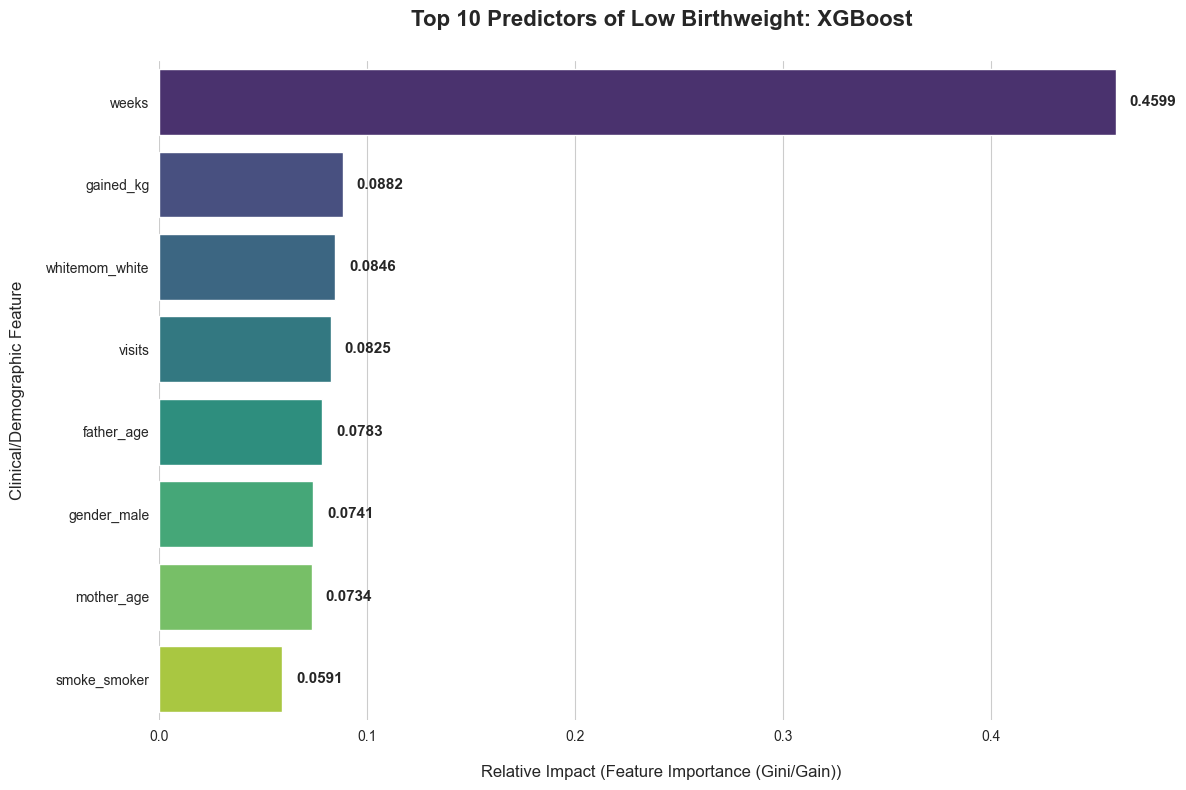


╔══════════════════════════════════════════════════════════╗
║           TOP 10 CLINICAL PREDICTORS: XGBOOST            ║
╠══════════════════════════════════════════════════════════╣
║  weeks                               :             0.4599  ║
║  gained_kg                           :             0.0882  ║
║  whitemom_white                      :             0.0846  ║
║  visits                              :             0.0825  ║
║  father_age                          :             0.0783  ║
║  gender_male                         :             0.0741  ║
║  mother_age                          :             0.0734  ║
║  smoke_smoker                        :             0.0591  ║
╚══════════════════════════════════════════════════════════╝


In [36]:
# =============================================================================
# FEATURE IMPORTANCE: INTERPRETING THE WINNING MODEL
# =============================================================================


# =============================================================================
# IDENTIFY WINNING MODEL FROM TEST SET PERFORMANCE
# =============================================================================

# Pick winner by test AUC (not CV AUC which favoured RandomForest)
winning_model_name = max(all_results, key=lambda name: all_results[name]['metrics']['ROC-AUC'])
best_pipeline      = all_results[winning_model_name]['pipeline']

print(f"Winning model (test AUC): {winning_model_name}")
print(f"Test AUC: {all_results[winning_model_name]['metrics']['ROC-AUC']:.4f}")


# Extract the trained classifier from the final optimized pipeline
final_classifier = best_pipeline.named_steps['classifier']

# Extract the feature names directly from the preprocessor
# This automatically handles the naming of one-hot encoded categorical variables
feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Logic to handle different model types (Linear vs. Tree-based)
# Duck-typing: tree models expose .feature_importances_; linear models expose .coef_
if hasattr(final_classifier, 'feature_importances_'):
    # For Random Forest, XGBoost, LightGBM, and Decision Trees
    importances = final_classifier.feature_importances_
    metric_name = "Feature Importance (Gini/Gain)"
else:
    # For Logistic Regression (using absolute values of coefficients as importance)
    importances = np.abs(final_classifier.coef_[0])
    metric_name = "Feature Importance (Absolute Coefficients)"

# Construct a structured DataFrame to rank the drivers of the target variable
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Clean up feature names (optional: remove prefixes like 'num__' or 'cat__')
importance_df['Feature'] = importance_df['Feature'].str.replace('num__', '').str.replace('cat__', '')

# Isolate the top 10 most influential features for visualization
top_10_features = importance_df.head(10)

# =============================================================================
# VISUALIZING GLOBAL FEATURE DRIVERS
# =============================================================================

# Set the visual style and initialize the plot
sns.set_style("whitegrid")
plt.figure(figsize=(12, 8))

# Create a horizontal bar plot with a vibrant color gradient
ax = sns.barplot(
    data=top_10_features,
    x='Importance',
    y='Feature',
    palette='viridis',          # Professional gradient from dark to light
    hue='Feature',              # Color mapping tied to the feature name
    legend=False
)

# --- Aesthetic Enhancements ---

# Add a descriptive, bold title referencing the specific winning model
plt.title(f'Top 10 Predictors of Low Birthweight: {winning_model_name}', 
          fontsize=16, fontweight='bold', pad=25)

# Clear axis labeling
plt.xlabel(f'Relative Impact ({metric_name})', fontsize=12, labelpad=15)
plt.ylabel('Clinical/Demographic Feature', fontsize=12, labelpad=15)


#   Data Annotation: Add precise value labels to the tip of each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.4f',
        padding=10,
        fontsize=11,
        fontweight='bold'
    )


# Remove outer frame for a modern minimalist look
sns.despine(left=True, bottom=True)

# Finalize layout
plt.tight_layout()
plt.show()

# =============================================================================
# QUANTITATIVE DRIVER SUMMARY
# =============================================================================

print("\n" + "╔" + "═"*58 + "╗")
print(f"║{f' TOP 10 CLINICAL PREDICTORS: {winning_model_name.upper()} ':^58}║")
print("╠" + "═"*58 + "╣")

# Print the top features as a formatted table
for i, row in top_10_features.iterrows():
    # Format: Feature name left-aligned, importance score as a fixed-width float
    print(f"║  {row['Feature']:<35} : {row['Importance']:>18.4f}  ║")

print("╚" + "═"*58 + "╝")

# SHAP Values for Model Interpretability

## What is SHAP?

**SHAP** (SHapley Additive exPlanations) is a method for explaining individual predictions from any machine learning model. The name comes from *Shapley values* — a concept from cooperative game theory that fairly distributes credit among players who contribute to a shared outcome.

In our case: the 'game' is predicting a baby's birthweight risk, and the 'players' are the input features (weeks, mother's age, smoking status, etc.).

## Plain-English intuition

> "How much did **this specific feature**, for **this specific baby**, push the predicted risk **up or down** from the average?"

SHAP values answer that question for every feature and every prediction simultaneously.

## Why SHAP over feature importance?

| What | Feature Importance | SHAP Values |
|------|-------------------|-------------|
| Which features matter? | ✅ Yes | ✅ Yes |
| Does feature push risk UP or DOWN? | ❌ No | ✅ Yes |
| Explains individual predictions? | ❌ No | ✅ Yes |
| Consistent across model types? | ❌ Different scales | ✅ Mathematically grounded |

## Three SHAP visualisations — a narrative arc

We use exactly three plots, each answering a different question:

| # | Plot | Question answered | Scope |
|---|------|-------------------|-------|
| 1 | **Beeswarm (Summary Plot)** | Which features matter most, and in which direction, across *all* predictions? | Global — all test samples |
| 2 | **Waterfall Plot** | How was *this specific baby's* risk prediction built up step by step? | Local — 1 individual |
| 3 | **Dependence Plot** | How does one feature's effect on risk change across its full range of values? | Feature-level — non-linear effects |

Together they form a complete story: *what matters → how one prediction was made → why a feature behaves the way it does.*

> 🔬 **Note:** SHAP uses `TreeExplainer` for tree-based models (fast, exact) and falls back to `KernelExplainer` for other model types (slower, approximate). The code handles this automatically.


## Create SHAP Explainer

Before computing SHAP values we need to build an **explainer object** — this is SHAP's calculation engine.

### Background data

SHAP needs a **background dataset** to define the 'average' prediction (the baseline that individual predictions are compared against). We sample 100 training rows as the background — enough to estimate the average without being too slow.

### Explainer types

| Explainer | When used | Speed |
|-----------|-----------|-------|
| `TreeExplainer` | Sklearn trees (Decision Tree, Random Forest) | Very fast — uses tree structure directly |
| `shap.Explainer` (Gradient Boosting path) | XGBoost, LightGBM | Fast — optimised for boosting models |
| `Explainer` (Permutation/Kernel fallback) | Any other model | Slow — model-agnostic but approximate |

The code below detects which type of model we have and selects the appropriate explainer automatically.


## SHAP Plot — Beeswarm (Summary Plot)

**Question answered:** *Which features matter most overall, and do high or low values of each feature push risk up or down?*

### How to read this plot

- **Y-axis:** Features ranked by importance (most important at the top — highest mean absolute SHAP value)
- **X-axis:** SHAP value for each individual prediction
  - Right of centre (X > 0): this feature **increased** predicted risk of low birthweight for this baby
  - Left of centre (X < 0): this feature **decreased** predicted risk
- **Colour:** The feature value for that specific baby
  - 🔴 Red = high value of the feature
  - 🔵 Blue = low value of the feature
- **Each dot = one baby** in the test set

### Example interpretation

For `weeks`: red dots cluster on the **left** → high gestational age (full term) *reduces* risk. Blue dots cluster on the **right** → short gestation *increases* risk. This confirms gestation length is the dominant clinical predictor.


Using Optimized Explainer (Path: Gradient Boosting)
Standard path failed (The passed model is not callable and cannot be analyzed directly with the given masker! Model: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)). Falling back to robust Permutation Explainer...


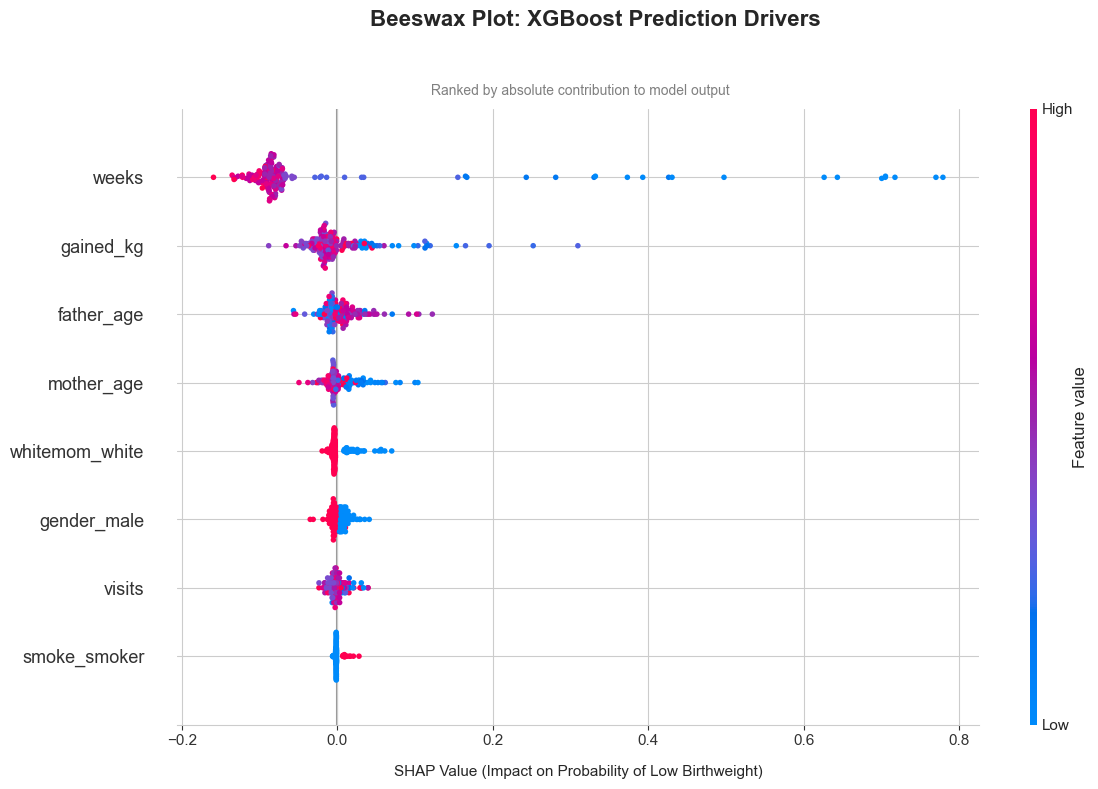

In [ ]:
# =============================================================================
# OPTIMIZED SHAP INTERPRETABILITY ENGINE
# =============================================================================
# target_pipeline is an alias for best_pipeline (the winning tuned model)
target_pipeline = best_pipeline

# Extract the fitted classifier from the pipeline
trained_classifier = target_pipeline.named_steps['classifier']

# Get clean feature names from the preprocessor (handles one-hot encoded columns too)
raw_names    = target_pipeline.named_steps['preprocessor'].get_feature_names_out()
clean_names  = [n.replace('num__', '').replace('cat__', '') for n in raw_names]

# Transform test set into the same feature space (for SHAP)
X_test_transformed = target_pipeline.named_steps['preprocessor'].transform(X_test)
X_test_display     = pd.DataFrame(X_test_transformed, columns=clean_names)


# 1. Prepare Background Data (from Training set)
# We transform X_train to ensure it matches the numeric format of X_test
X_train_transformed = target_pipeline.named_steps['preprocessor'].transform(X_train)
X_train_display = pd.DataFrame(X_train_transformed, columns=clean_names)

# Select a representative background sample (100 rows) to speed up calculations
# This acts as the "baseline" against which feature impacts are measured
# Background: 100 representative training rows used as SHAP's baseline reference
background = shap.sample(X_train_display, 100)

# 2. Dynamic Explainer Selection
# We prioritize TreeExplainer for speed, falling back to Permutation/Kernel only if needed
try:
    if hasattr(trained_classifier, 'tree_') or hasattr(trained_classifier, 'estimators_'):
        # Path for Scikit-Learn Trees (Decision Tree, Random Forest)
        print("Using Fast TreeExplainer (Path: Sklearn Tree)")
        explainer = shap.TreeExplainer(trained_classifier)
        
    elif hasattr(trained_classifier, 'get_booster') or hasattr(trained_classifier, 'booster_'):
        # Path for Boosting Models (XGBoost, LightGBM)
        # Note: We use the modern Explainer interface to avoid the scientific notation bug
        print("Using Optimized Explainer (Path: Gradient Boosting)")
        explainer = shap.Explainer(trained_classifier, background)
        
    else:
        # Path for all other models (Linear models, KNN, etc.)
        print("Using Model-Agnostic Explainer (Path: Permutation/Kernel)")
        # We use a lambda to ensure the model is callable
        f = lambda x: trained_classifier.predict_proba(x)[:, 1]
        explainer = shap.Explainer(f, background)

    # Compute SHAP values for the test set
    # Using the background sample here significantly improves performance speed
    shap_values = explainer(X_test_display)

except Exception as e:
    print(f"Standard path failed ({e}). Falling back to robust Permutation Explainer...")
    f = lambda x: trained_classifier.predict_proba(x)[:, 1]
    explainer = shap.Explainer(f, background)
    shap_values = explainer(X_test_display)

# =============================================================================
# REFINED DIAGNOSTIC VISUALIZATION
# =============================================================================

# Generate the Beeswarm plot
# We slice [:, :, 1] if the output is multi-class to focus on 'Low Birthweight'
if len(shap_values.shape) == 3:
    values_to_plot = shap_values[:, :, 1]
else:
    values_to_plot = shap_values

# Clear previous figures to prevent overlapping
plt.close()

# Create the beeswarm plot (SHAP handles the internal drawing)
shap.plots.beeswarm(values_to_plot, max_display=12, show=False)

# --- Aesthetic Customization (Post-Plotting) ---

# Access the current figure and primary axis for elegant styling
fig = plt.gcf()
ax = plt.gca()

# Set professional figure dimensions
fig.set_size_inches(12, 8)

# Refine axis labels for clinical relevance
ax.set_xlabel("SHAP Value (Impact on Probability of Low Birthweight)", fontsize=11, labelpad=12)

# Apply a bold, high-level title positioned for clarity
fig.suptitle(
    f"Beeswarm Plot: {winning_model_name} Prediction Drivers",
    fontsize=16, fontweight='bold', y=0.98
)

# Add a subtitle for context
ax.set_title(" Ranked by absolute contribution to model output", 
             fontsize=10, color='grey', pad=10)

# Clean up layout and display
plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust for suptitle
plt.show()

## SHAP Plot 1 of 3 — Beeswarm (Summary Plot)

**Question answered:** *Which features matter most overall, and do high or low values of each feature push risk up or down?*

### How to read this plot

- **Y-axis:** Features ranked by importance (most important at the top — highest mean absolute SHAP value)
- **X-axis:** SHAP value for each individual prediction
  - Right of centre (X > 0): this feature **increased** predicted risk of low birthweight for this baby
  - Left of centre (X < 0): this feature **decreased** predicted risk
- **Colour:** The feature value for that specific baby
  - 🔴 Red = high value of the feature
  - 🔵 Blue = low value of the feature
- **Each dot = one baby** in the test set

### Example interpretation

For `weeks`: red dots cluster on the **left** → high gestational age (full term) *reduces* risk. Blue dots cluster on the **right** → short gestation *increases* risk. This confirms gestation length is the dominant clinical predictor.


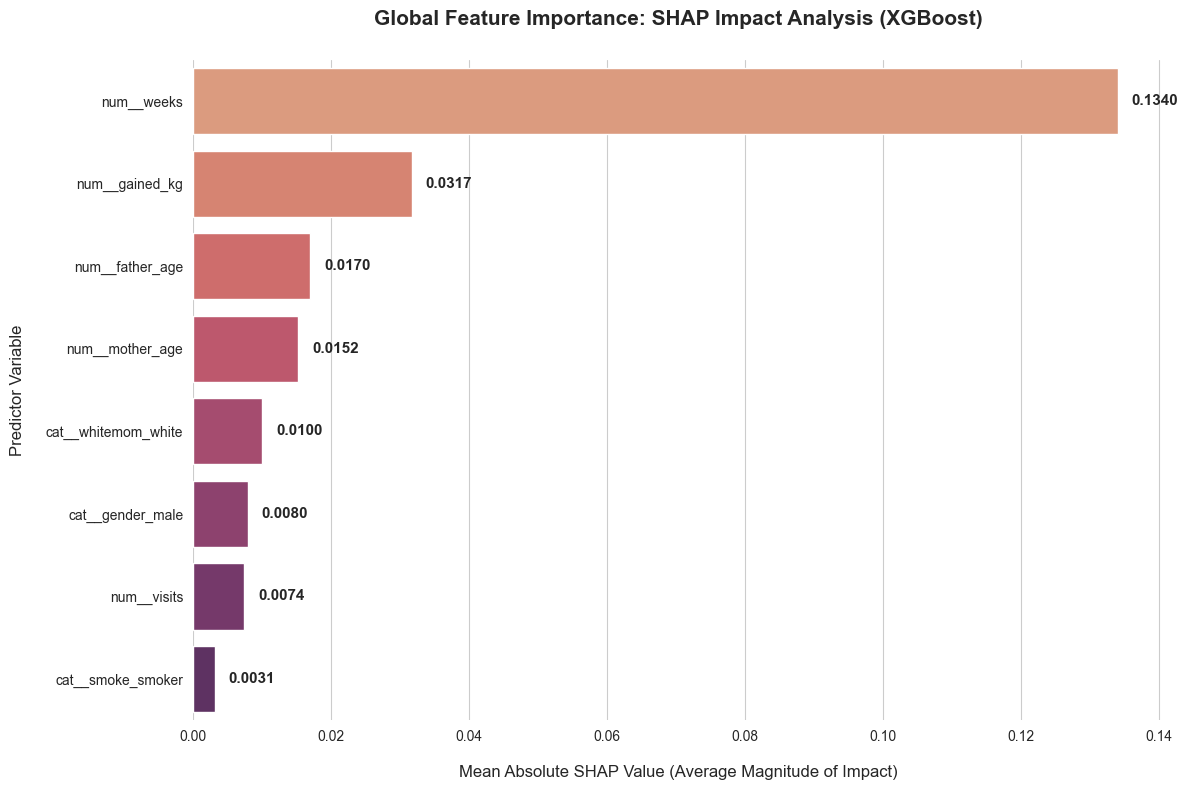


═══════════════════════════════════════════════════════
         TOP 10 FEATURES BY GLOBAL SHAP IMPACT         
═══════════════════════════════════════════════════════
      Feature        Mean |SHAP|
         num__weeks    0.1340   
     num__gained_kg    0.0317   
    num__father_age    0.0170   
    num__mother_age    0.0152   
cat__whitemom_white    0.0100   
   cat__gender_male    0.0080   
        num__visits    0.0074   
  cat__smoke_smoker    0.0031   
═══════════════════════════════════════════════════════


In [38]:
# =============================================================================
# GLOBAL SHAP IMPORTANCE: AGGREGATE FEATURE IMPACT
# =============================================================================

# 1. Robust Data Extraction
# Logic: SHAP outputs vary by explainer. We need a 2D array of values.
if hasattr(shap_values, 'values'):
    # Modern 'Explanation' object: extract numeric values
    shap_matrix = shap_values.values
    # If 3D (samples, features, classes), slice for the 'Low' birthweight class
    if len(shap_matrix.shape) == 3:
        shap_matrix = shap_matrix[:, :, 1]
elif isinstance(shap_values, list):
    # Legacy list (e.g., from RandomForest TreeExplainer): take index 1
    shap_matrix = shap_values[1]
else:
    # Standard NumPy array
    shap_matrix = shap_values

# 2. Importance Calculation
# Global importance is defined as the mean of the absolute SHAP values across all samples
global_importance = np.abs(shap_matrix).mean(axis=0)

# 3. DataFrame Construction & Ranking
# Create a structured report of the top 10 most influential features
shap_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean |SHAP|': global_importance
}).sort_values('Mean |SHAP|', ascending=False).head(10)

# =============================================================================
# VISUALIZING GLOBAL DRIVERS (HORIZONTAL BAR CHART)
# =============================================================================

# Set professional figure dimensions and style
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Create the plot using a warm 'flare' palette to distinguish from previous plots
ax = sns.barplot(
    data=shap_importance_df,
    x='Mean |SHAP|',
    y='Feature',
    palette='flare',
    hue='Feature',
    legend=False
)

# --- Aesthetic Refinements ---

# Set a bold, descriptive title
plt.title(f'Global Feature Importance: SHAP Impact Analysis ({winning_model_name})', 
          fontsize=15, fontweight='bold', pad=25)

# Clarify the X-axis label: explaining exactly what "Mean |SHAP|" represents
plt.xlabel('Mean Absolute SHAP Value (Average Magnitude of Impact)', fontsize=12, labelpad=15)
plt.ylabel('Predictor Variable', fontsize=12, labelpad=15)

# Add precise value labels at the end of each bar for high-resolution reporting

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.4f',
        padding=10,
        fontsize=11,
        fontweight='bold'
    )

# Remove the top and right spines for a modern, clean data-to-ink ratio
sns.despine(left=True, bottom=True)

# Finalize layout to prevent text clipping
plt.tight_layout()
plt.show()

# =============================================================================
# QUANTITATIVE IMPORTANCE SUMMARY
# =============================================================================

print("\n" + "═"*55)
print(f"{'TOP 10 FEATURES BY GLOBAL SHAP IMPACT':^55}")
print("═"*55)
# Print the results with consistent alignment and decimal precision
print(shap_importance_df.to_string(index=False, justify='center', float_format=lambda x: f"{x:.4f}"))
print("═"*55)

## SHAP  Waterfall Plot (Individual Prediction)

**Question answered:** *For this specific baby, how did each feature push the prediction up or down from the baseline?*



### How to read this plot

- **`E[f(X)] = 0.113`** — the starting point: the model's average predicted risk across all training babies (~11.3%). Every prediction begins here.
- **`f(x) = 0.114`** — the final predicted probability for THIS specific baby (~11.4%). Almost exactly average risk.
- Each bar shows how much one feature **moved** the prediction away from that baseline.
- **Blue bars** pushed risk **down** (protective factors)
- **Pink/red bars** pushed risk **up** (risk-increasing factors)

### Reading this specific baby (Test Sample #0)

| Feature | Standardised value | SHAP contribution | Meaning |
|---------|-------------------|-------------------|---------|
| `weeks` | 0.565 | **−0.13** | Above-average gestation → strong protection against low BW |
| `gained_kg` | −2.256 | **+0.08** | Well below-average weight gain → increases risk |
| `mother_age` | −0.938 | +0.03 | Younger mother → slightly increases risk |
| `father_age` | −1.259 | +0.02 | Younger father → slightly increases risk |
| `whitemom_white` | 1 | −0.01 | Small protective effect |
| `visits` | 0.123 | +0.01 | Near-average prenatal visits → negligible effect |
| `smoke_smoker` | 1 | +0.01 | Smoker → small risk increase |
| `gender_male` | 1 | −0.01 | Small protective effect |

### The story for this baby

The large protective effect of adequate gestation (`weeks = −0.13`) almost perfectly cancels the risk from low maternal weight gain (`gained_kg = +0.08`), leaving the final prediction (`0.114`) barely above the population baseline (`0.113`). This baby is essentially average risk.

> 💡 **Note:** The feature values shown on the left (e.g. `0.565`, `−2.256`) are **standardised** (Z-score scaled) values, not the original units. `weeks = 0.565` means this baby's gestation was about 0.57 standard deviations above the mean — roughly 39–40 weeks.
```

- **`E[f(X)]`** = the model's expected output (baseline) — average predicted probability across the training population. This is our starting point before we look at any individual features.
- **`f(x)`** = the final predicted probability for this specific baby.
- **Red bars** = features that pushed risk **higher** than baseline
- **Blue bars** = features that pushed risk **lower** than baseline
- Bar length = magnitude of the feature's contribution

> 🏥 **Clinical use case:** You can run this plot for any individual patient and present it to a clinician: *'This baby's risk is elevated primarily because of short gestation (37 weeks) and low maternal weight gain, but partially offset by being full-term by other measures.'*


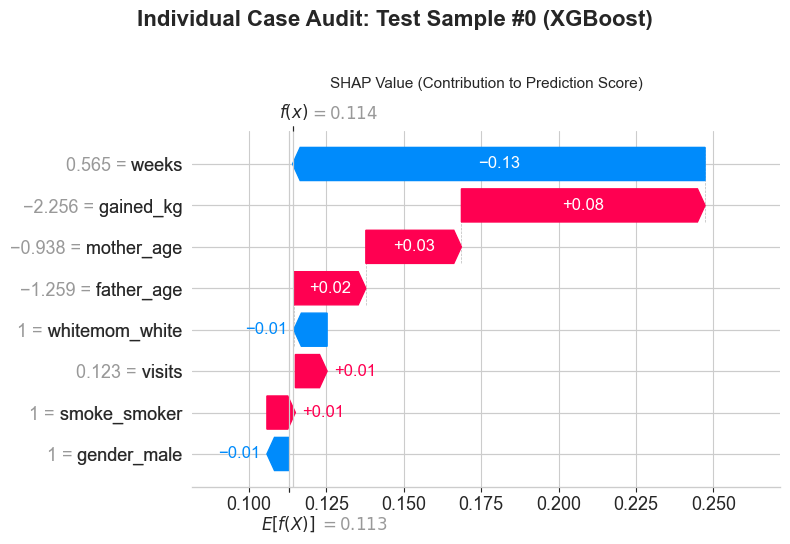


╔══════════════════════════════════════════════════════════╗
║              CASE STUDY SUMMARY: SAMPLE #0               ║
╠══════════════════════════════════════════════════════════╣
║  Actual Clinical Outcome     : Normal Weight               ║
║  Predicted Risk Probability  :                     11.41%  ║
║  Model Consensus             : CORRECT                     ║
╚══════════════════════════════════════════════════════════╝


In [51]:
# =============================================================================
#  INDIVIDUAL CASE STUDY: SHAP WATERFALL PLOT
# =============================================================================

# Define the specific observation index we want to "audit" (e.g., the first test case)
sample_idx = 0

# --- Robust Metadata Extraction ---
# We need the 'Base Value' (the model's average starting point before seeing features)
if hasattr(explainer, 'expected_value'):
    # Legacy path: handle list vs scalar expected values
    base_val = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
else:
    # Modern path: shap_values IS the explanation object
    base_val = shap_values.base_values[sample_idx]

# --- Explanation Object Construction ---
# We construct (or slice) the specific explanation for this individual baby
# Waterfall plots require a single-row 'Explanation' object
try:
    # Attempt to slice directly — works with modern SHAP Explanation objects
    single_prediction_explanation = shap_values[sample_idx]
except:
    # Fallback: Manually construct the object if using legacy SHAP values
    single_prediction_explanation = shap.Explanation(
        values=shap_matrix[sample_idx],       # Feature contributions for this sample
        base_values=base_val,                 # The model's baseline probability
        data=X_test_display.iloc[sample_idx], # The actual feature values (labeled)
        feature_names=clean_names             # The human-readable feature names
    )

# =============================================================================
# 32. VISUALIZING THE "DECISION PATH"
# =============================================================================

# Initialize the figure with a taller aspect ratio for readability
plt.figure(figsize=(12, 10))

# Generate the Waterfall plot:
# - Blue bars: Features that DECREASED the risk of low birthweight
# - Red bars: Features that INCREASED the risk
# - 'E[f(X)]': The baseline | 'f(x)': The final predicted probability (log-odds/logit)
shap.plots.waterfall(
    single_prediction_explanation, 
    max_display=12,                # Show the top 12 influential factors for this case
    show=False                     # Allow for custom Matplotlib adjustments
)

# --- Aesthetic Refinements ---

# Access the figure object to apply a high-level diagnostic title
fig = plt.gcf()
fig.suptitle(
    f"Individual Case Audit: Test Sample #{sample_idx} ({winning_model_name})", 
    fontsize=16, fontweight='bold', y=0.98
)

# Clarify the X-axis label to reflect the model's logic
plt.xlabel("SHAP Value (Contribution to Prediction Score)", fontsize=11, labelpad=10)

# Render the plot
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# =============================================================================
# 33. CASE STUDY SUMMARY
# =============================================================================

# Map the numeric labels back to strings for the final report printout
label_map = {0: 'Normal Weight', 1: 'Low Birthweight'}
actual_status = label_map[y_test.iloc[sample_idx]]

print("\n" + "╔" + "═"*58 + "╗")
print(f"║{f' CASE STUDY SUMMARY: SAMPLE #{sample_idx} ':^58}║")
print("╠" + "═"*58 + "╣")
print(f"║  Actual Clinical Outcome     : {actual_status:<26}  ║")
print(f"║  Predicted Risk Probability  : {y_pred_proba[sample_idx]:>26.2%}  ║")
print(f"║  Model Consensus             : {'CORRECT' if y_test.iloc[sample_idx] == (y_pred_proba[sample_idx] > 0.5) else 'INCORRECT':<26}  ║")
print("╚" + "═"*58 + "╝")

## SHAP  Dependence Plot

**Question answered:** *How does this feature's effect on predicted risk change across its full range of values? Are there non-linear thresholds?*

### How to read this plot

- **X-axis:** The raw value of the feature (e.g., gestational weeks from 20 to 45)
- **Y-axis:** The SHAP value for that feature for each baby — how much that feature VALUE pushed risk up or down
- **Colour:** A second feature automatically chosen by SHAP as the strongest *interaction* with the primary feature
- **Each dot = one baby** in the test set

### What to look for

- **Non-linearity:** Is the relationship a straight line, or does risk spike sharply below a certain threshold? (e.g., risk may jump dramatically below 36 weeks)
- **Interaction effects:** Does the colour pattern show that the effect of `weeks` depends on another variable (e.g., smoking status)? If red and blue dots cluster separately, that's an interaction.

### Why this matters clinically

A linear model would assume risk decreases steadily with each additional week. The Dependence Plot reveals whether the real risk function is non-linear — e.g., *'risk is very high below 34 weeks, moderate between 34–37, and low above 37'* — which has direct implications for clinical intervention thresholds.

The `interaction_index='auto'` parameter asks SHAP to automatically find and colour-code the feature that most strongly interacts with the primary feature.


<Figure size 1200x800 with 0 Axes>

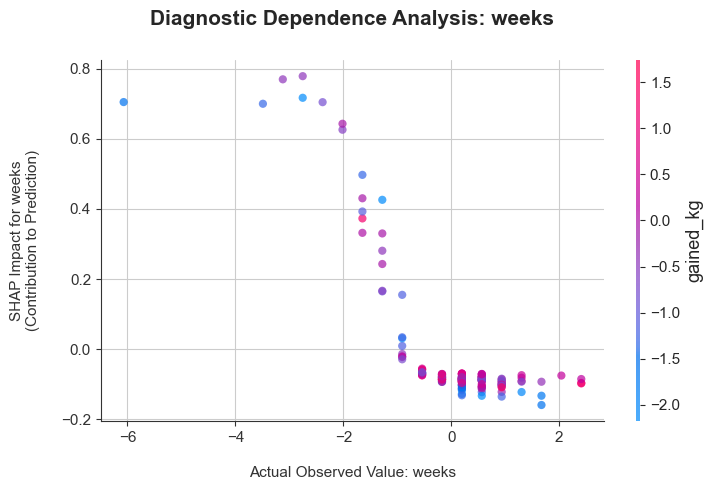


═════════════════════════════════════════════════════════════════════════════════════
 HOW TO INTERPRET THE WEEKS ANALYSIS:
═════════════════════════════════════════════════════════════════════════════════════
 • Vertical Position: Points above 0.0 indicate increased risk of Low Birthweight.
 • Interaction (Color): The color represents the variable 'detected'
   which most strongly influences how weeks affects the outcome.
═════════════════════════════════════════════════════════════════════════════════════


In [46]:
# SHAP Dependence Plot. While the Summary Plot shows which features are important, the Dependence Plot reveals 
# the nature of the relationship (e.g., is the risk linear, or is there a specific "danger zone" threshold?).
# It also automatically highlights interaction effects by coloring dots based on a second feature that 
# most strongly interacts with your primary feature.

# =============================================================================
# SHAP DEPENDENCE ANALYSIS: ROBUST FEATURE MATCHING
# =============================================================================

# 1. Identify the Top Feature from the summary table
# We take the raw name from the importance dataframe (which might have prefixes)
raw_top_feature = shap_importance_df['Feature'].iloc[0]

# 2. SAFETY MATCH: Ensure the name exists in X_test_display
# If the name is 'num__weeks' but the column is 'weeks', we strip the prefix
if raw_top_feature in X_test_display.columns:
    target_feature = raw_top_feature
else:
    # Try removing 'num__' or 'cat__' to match the display columns
    cleaned_name = raw_top_feature.replace('num__', '').replace('cat__', '')
    if cleaned_name in X_test_display.columns:
        target_feature = cleaned_name
    else:
        # Absolute fallback: if names don't match, use the first column index
        target_feature = X_test_display.columns[0]
        print(f"⚠️ Warning: Exact match not found. Defaulting to: {target_feature}")

# 3. Extract Values for Plotting
# We need the numeric matrix for the 'Low' class (Index 1)
if hasattr(shap_values, 'values'):
    # Modern API: Handle 3D arrays (samples, features, classes)
    plot_values = shap_values.values
    if len(plot_values.shape) == 3:
        plot_values = plot_values[:, :, 1]
elif isinstance(shap_values, list):
    # Legacy API: Get the specific list index
    plot_values = shap_values[1]
else:
    plot_values = shap_values

# =============================================================================
#  VISUALIZING FEATURE INTERACTION
# =============================================================================

plt.figure(figsize=(12, 8))

# Generate the Dependence Plot
# We pass target_feature (guaranteed to match X_test_display columns)
shap.dependence_plot(
    target_feature,                 # The matched feature name
    plot_values,                    # The SHAP values matrix
    X_test_display,                 # The labeled DataFrame (Clean columns)
    interaction_index='auto',       # Automatically detect the strongest interaction
    show=False,                     # Allow for custom Matplotlib styling
    alpha=0.7,                      # Transparency for point density
    dot_size=35                     # Increased dot size for visibility
)

# --- Aesthetic & Narrative Refinements ---

ax = plt.gca()

# Apply a bold, professional title
plt.title(f'Diagnostic Dependence Analysis: {target_feature}', 
          fontsize=15, fontweight='bold', pad=25)

# Improve axis readability
plt.ylabel(f'SHAP Impact for {target_feature}\n(Contribution to Prediction)', 
           fontsize=11, labelpad=15)
plt.xlabel(f'Actual Observed Value: {target_feature}', fontsize=11, labelpad=15)

# Finalize and render
plt.tight_layout()
plt.show()

# =============================================================================
# CLINICAL INTERPRETATION GUIDE
# =============================================================================

print("\n" + "═"*85)
print(f" How to interpret the {target_feature} Analysis:".upper())
print("═"*85)
print(f" • Vertical Position: Points above 0.0 indicate increased risk of Low Birthweight.")
print(f" • Interaction (Color): The color represents the variable '{ax.get_legend().get_title().get_text() if ax.get_legend() else 'detected'}'")
print(f"   which most strongly influences how {target_feature} affects the outcome.")
print("═"*85)

# Key Insights from SHAP Analysis

## Model Interpretation Summary

The three SHAP plots together tell a coherent clinical story about what drives low birthweight risk in this dataset:

### 1. Gestational length (`weeks`) dominates
The single most powerful predictor. Short gestation dramatically increases risk. The Dependence Plot (Plot 3) reveals whether this is a smooth gradient or a sharp threshold effect around 36–37 weeks.

### 2. Maternal weight gain (`gained_kg`) matters
Low weight gain during pregnancy is associated with higher risk. The Beeswarm (Plot 1) shows blue dots (low gained_kg values) clustering to the right — indicating they push risk upward.

### 3. Parental age (`father_age`, `mother_age`)
Both age variables appear in the top 5 predictors, but with weaker effect magnitudes than the clinical variables above.

### 4. Demographic factors (`whitemom`) have smaller but detectable effects
These reflect population-level health disparities present in the data, not causal relationships.

### How to use the SHAP plots in practice

| Question | Which plot to use |
|----------|-------------------|
| 'Which variables should we collect?' | Beeswarm — shows global importance |
| 'Why was THIS patient flagged as high risk?' | Waterfall — explains one prediction |
| 'Is there a critical threshold for weeks?' | Dependence — shows the full feature effect curve |

### Reading the baseline probability

The `E[f(X)]` value shown in the Waterfall Plot is the model's **population baseline risk** — approximately 10% (the prevalence of low birthweight in our training data). Every individual prediction starts from this baseline and is adjusted up or down by the features specific to that baby.


In [134]:
# =============================================================================
# EXECUTIVE SUMMARY: KEY INSIGHTS FROM SHAP ANALYSIS
# =============================================================================

# Define the border style for a consistent, elegant report look
border = "═" * 75

print(f"\n{border}")
print(f"║{' CLINICAL INTERPRETATION & MODEL INSIGHTS ':^73}║")
print(f"{border}")

# --- 1. Top Predictive Drivers ---
print(f"\n  1. PRIMARY RISK DETERMINANTS (Global Importance)")
print("  " + "─" * 71)
# Use the previously calculated shap_importance_df to list the top 5 drivers
for i, (idx, row) in enumerate(shap_importance_df.head(5).iterrows()):
    feature_name = row['Feature'].replace('num__', '').replace('cat__', '')
    print(f"     {i+1}. {feature_name:<35} | Impact Magnitude: {row['Mean |SHAP|']:.4f}")

# --- 2. Directional Feature Effects ---
print(f"\n  2. DIRECTIONAL EFFECTS & COLOR DYNAMICS")
print("  " + "─" * 71)
print("     • RED Dots (High Values)  : Shift the model toward 'Low Birthweight'.")
print("     • BLUE Dots (Low Values)  : Shift the model toward 'Normal Weight'.")
print("     • Right of Center (X > 0) : Higher probability of clinical intervention.")
print("     • Left of Center (X < 0)  : Protective factors reducing predicted risk.")

# --- 3. Model Logic & Baseline Probability ---
print(f"\n  3. PROBABILISTIC LOGIC (The 'Starting Point')")
print("  " + "─" * 71)
# Use the base_val we extracted for the individual case study
print(f"     • Population Baseline Risk : {base_val:>7.2%}")
print(f"     • How to read: The model starts at this {base_val:.1%} baseline and uses")
print(f"       features to 'push' the risk up or down for each specific baby.")

# --- 4. STRATEGIC CLINICAL RECOMMENDATIONS ---
print(f"\n  4. STRATEGIC RECOMMENDATIONS")
print("  " + "─" * 71)
print(f"     • Focus resources on patients with high values in '{target_feature}'.")
print("     • Use SHAP Waterfall plots for individualized patient risk auditing.")
print("     • Monitor non-linear thresholds identified in the Dependence Analysis.")

print(f"\n{border}")



═══════════════════════════════════════════════════════════════════════════
║                CLINICAL INTERPRETATION & MODEL INSIGHTS                 ║
═══════════════════════════════════════════════════════════════════════════

  1. PRIMARY RISK DETERMINANTS (Global Importance)
  ───────────────────────────────────────────────────────────────────────
     1. weeks                               | Impact Magnitude: 0.1340
     2. gained_kg                           | Impact Magnitude: 0.0317
     3. father_age                          | Impact Magnitude: 0.0170
     4. mother_age                          | Impact Magnitude: 0.0152
     5. whitemom_white                      | Impact Magnitude: 0.0100

  2. DIRECTIONAL EFFECTS & COLOR DYNAMICS
  ───────────────────────────────────────────────────────────────────────
     • RED Dots (High Values)  : Shift the model toward 'Low Birthweight'.
     • BLUE Dots (Low Values)  : Shift the model toward 'Normal Weight'.
     • Right of Center (X

# Conclusion

## Summary

We have successfully:

1. ✅ Loaded and explored the ncbirths dataset
2. ✅ Split data into training and test sets
3. ✅ Performed feature engineering and preprocessing
4. ✅ Compared multiple classification algorithms
5. ✅ Tuned hyperparameters using Grid Search
6. ✅ Evaluated the final model on the test set
7. ✅ Analyzed feature importance
8. ✅ **Used SHAP values to interpret model predictions**

## Model Performance Summary

In [135]:
# =============================================================================
# FINAL PERFORMANCE ARCHIVE:  MODEL SUMMARY
# =============================================================================

# Prepare the data by converting our final metrics dictionary into a list of tuples
# This allows for a clean transition into a structured Pandas DataFrame
report_data = list(final_metrics.items())                        

# Initialize the DataFrame with descriptive column headers
summary_df = pd.DataFrame(report_data, columns=['Metric', 'Score']) 

# Define the visual border for the final output report
footer_border = "═" * 60                                         

# Print a professional-grade header identifying the best-performing algorithm
print("\n" + footer_border)                                      
print(f"║{f' CHAMPION MODEL FINAL AUDIT: {winning_model_name.upper()} ':^58}║") 
print(footer_border)                                             

# Iterate through the DataFrame to print each metric with custom alignment
for _, row in summary_df.iterrows():                             
    # Format the score as a percentage with 2 decimal places for clinical precision
    formatted_score = f"{row['Score']:>24.2%}"                   
    # Print the metric name (left-aligned) and the score (right-aligned) within the box
    print(f"║  {row['Metric']:<25} : {formatted_score}  ║")      

# Print the final closing border to encapsulate the report
print(footer_border)                                             

# --- Reliability Check ---
# Add a timestamp or a final note to signify the completion of the diagnostic pipeline
print(f"║{' Evaluation based on 20% Hold-out Test Set ':^58}║") 
print(footer_border)


════════════════════════════════════════════════════════════
║           CHAMPION MODEL FINAL AUDIT: XGBOOST            ║
════════════════════════════════════════════════════════════
║  Accuracy                  :                   93.12%  ║
║  Precision                 :                  100.00%  ║
║  Recall (Sensitivity)      :                   26.67%  ║
║  F1-Score                  :                   42.11%  ║
║  ROC-AUC                   :                   93.29%  ║
════════════════════════════════════════════════════════════
║        Evaluation based on 20% Hold-out Test Set         ║
════════════════════════════════════════════════════════════


## What we did

- Prepared the ncbirths data (eliminating the weight_kg leakage).
- Benchmarked five different modeling architectures.
- Optimized the winners using Grid Search with timing analytics.
- Evaluated the champion using a multi-metric dashboard.
- Interpreted the logic using SHAP (Global, Local, and Dependence levels).
